<a href="https://colab.research.google.com/github/roilani-collab/roilani-collab/blob/main/Simulation_Project_Group_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl" style="text-align: center; color: blue;">


# 🌊 פרויקט סימולציה 🌊
## קבוצה 9
**Discrete-Event Simulation • Water Park Model**



<div dir="rtl" style="text-align: right; color: blue;">

# התאמת התפלגויות

</div>

<div dir="rtl" style="text-align: right; color: blue;">

###קוד טעינת אקסל


</div>

In [ ]:
import pandas as pd


SHEET_ID = "1Py1L-hHG6rruwvEl_pOdRfVyJWsZPxeb"


url = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv"

df = pd.read_csv(url)

print(df.head())
print("Rows:", len(df), "Cols:", df.shape[1])


   time_minutes
0      5.869729
1      5.657188
2      6.103758
3      7.228931
4      6.100345
Rows: 100 Cols: 1


<div dir="rtl" style="text-align: right; color: blue;">

##התאמת התפלגויות עבור מגלשת האבובים הגדולה


</div>

<div dir="rtl" style="text-align: right;">
 כדי לזהות אילו התפלגויות עשויות לתאר את משכי ההתגלשות במגלשת האבובים הגדולה, נתחיל בהשוואה גרפית בין הנתונים שקיבלנו בקובץ האקסל למדגמים תאורטיים. נציג היסטוגרמה של זמני ההתגלשות (כלומר התפלגות אמפירית), ועליה נשרטט שתי פונקציות צפיפות נפוצות: נורמלית ואקספוננציאלית, כאשר הפרמטרים שלהן נאמדים מתוך הנתונים. מטרת השלב היא לקבל אינטואיציה ראשונית לגבי "צורת" ההתפלגות: האם היא נראית סימטרית סביב ערך מרכזי (כמו נורמלית)  או דועכת בהדרגה מערכים גדולים לערכים קטנים (כמו אקספוננציאלית). בשלב זה איננו מסיקים מסקנה סופית - זו רק הערכה חזותית לקראת מבחנים סטטיסטיים בהמשך.


</div>


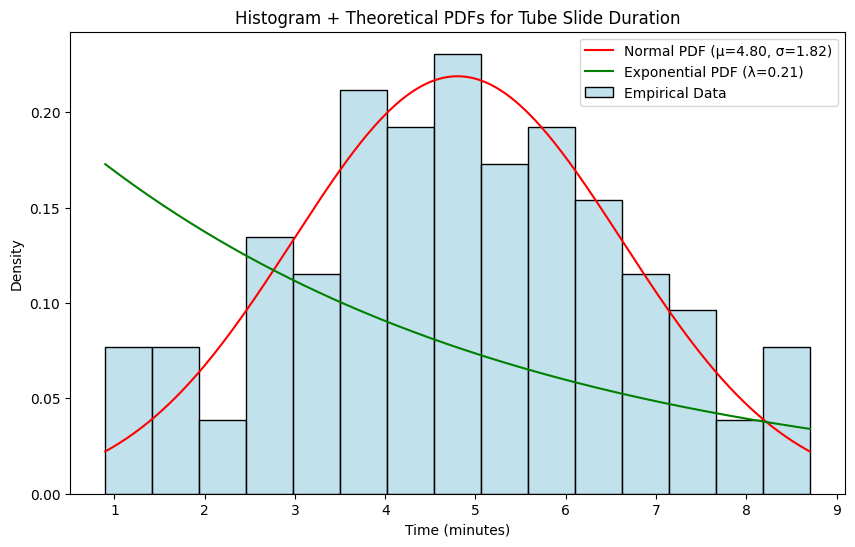

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, expon

# Extracting the data from the column
data = df['time_minutes'].dropna()

# Estimating parameters for the Normal distribution
mu, sigma = norm.fit(data)

# Estimating parameter for the Exponential distribution (lambda = 1/mean)
lambda_exp = 1 / np.mean(data)

# Creating a range of x-values for plotting the PDFs
x = np.linspace(min(data), max(data), 200)

# Normal PDF
pdf_normal = norm.pdf(x, mu, sigma)

# Exponential PDF
pdf_expon = lambda_exp * np.exp(-lambda_exp * x)

# Plotting the histogram and the theoretical PDFs
plt.figure(figsize=(10, 6))

# Histogram of the empirical data
sns.histplot(data, bins=15, kde=False, stat='density',
             color='lightblue', label='Empirical Data')

# Plotting the Normal PDF
plt.plot(x, pdf_normal, 'r-',
         label=f'Normal PDF (μ={mu:.2f}, σ={sigma:.2f})')

# Plotting the Exponential PDF
plt.plot(x, pdf_expon, 'g-',
         label=f'Exponential PDF (λ={lambda_exp:.2f})')

# Plot settings
plt.title("Histogram + Theoretical PDFs for Tube Slide Duration")
plt.xlabel("Time (minutes)")
plt.ylabel("Density")
plt.legend()
plt.show()



<div dir="rtl" style="text-align: right;">
מההשוואה הגרפית ניתן לראות שההתפלגות האמפירית מציגה ריכוז תצפיות סביב ערך מרכזי
וצורה כללית הקרובה ל"פעמון", בעוד שההתפלגות האקספוננציאלית אינה משקפת היטב את קיומו של שיא מרכזי. לכן, כבר בשלב הוויזואלי מתקבלת אינדיקציה ראשונית לכך שהתפלגות נורמלית עשויה להתאים יותר לנתונים - אך את ההחלטה נאשש באמצעות בדיקות פורמליות.


כדי לחזק את הבדיקה הוויזואלית, נשתמש בגרפי נורמליות עבור שתי ההתפלגויות שנבדקו. הרעיון הוא להשוות בין אחוזוני הנתונים לבין אחוזוני ההתפלגות התאורטית: אם הנתונים באמת מתאימים להתפלגות מסוימת, הנקודות בגרף יסתדרו בקירוב לאורך קו ישר. סטיות שיטתיות מהקו מצביעות על אי-התאמה, ולעיתים ניתן לזהות בעזרתן בעיות בזנבות (ערכים קיצוניים) או הטיה של הנתונים. כך הגרפים נותנים בדיקה “מדויקת יותר” מאשר הסתכלות כללית על ההיסטוגרמה בלבד.

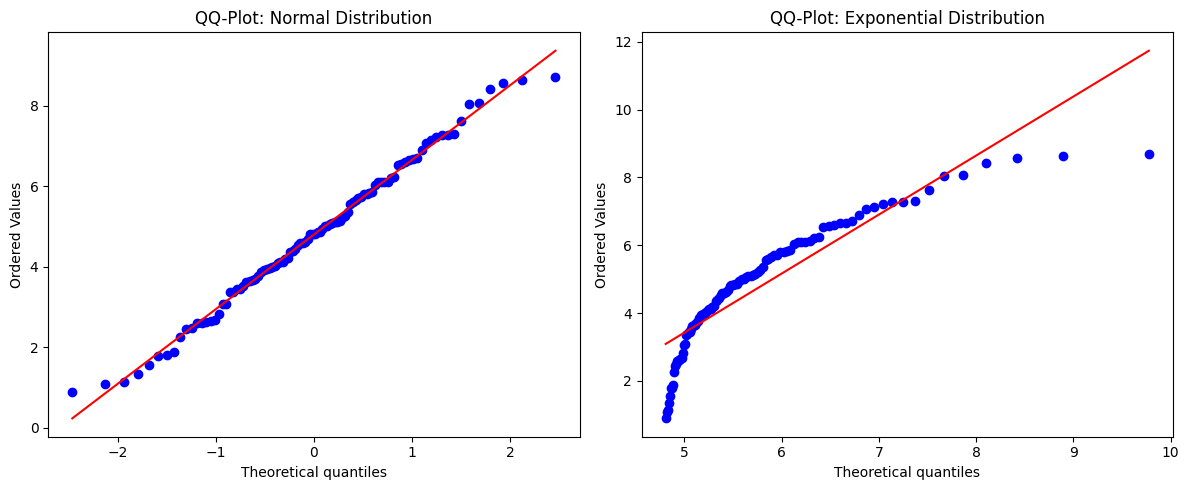

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

# QQ-Plot for Normal distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
stats.probplot(data, dist="norm", plot=plt)
plt.title("QQ-Plot: Normal Distribution")

# QQ-Plot for Exponential distribution
plt.subplot(1, 2, 2)
# For exponential, we pass the fitted parameter (scale = 1/lambda)
stats.probplot(data, dist="expon", sparams=(1/lambda_exp,), plot=plt)
plt.title("QQ-Plot: Exponential Distribution")

plt.tight_layout()
plt.show()




<div dir="rtl" style="text-align: right;">
בגרף הנורמליות עבור ההתפלגות הנורמלית הנקודות נמצאות קרוב יחסית לקו הישר לאורך רוב הטווח, בעוד שבגרף מול ההתפלגות האקספוננציאלית ניכרות סטיות ברורות. לכן גם בשלב זה מתקבלת תמיכה נוספת לכך שהנתונים מתאימים יותר להתפלגות נורמלית.

<div dir="rtl" style="text-align: right;">

**מבחנים סטטיסטיים**


לאחר בדיקת התאמה חזותית, בוצעו מבחני טיב התאמה סטטיסטיים במטרה
לבחון האם זמני ההחלקה במגלשת האבובים הגדולה מתאימים להתפלגות נורמלית.

המבחן הסטטיסטי בוצע על בסיס הנתונים שנמדדו בפועל, כאשר פרמטרי
ההתפלגות נאמדו מתוך המדגם.

הבדיקות בוצעו עבור מספר רמות מובהקות:
0.10 ,0.05 ,0.025 ,0.01.

ההחלטה התקבלה על סמך השוואת סטטיסטי המבחן לערכים הקריטיים
המתאימים בכל אחת מרמות המובהקות.


In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as st

#From Exe
col_name = "time_minutes"

x = pd.to_numeric(df[col_name], errors="coerce").dropna().to_numpy()
n = len(x)

# אומדנים לנורמלית
mu_hat = float(np.mean(x))
sigma_hat = float(np.std(x, ddof=1))  # סטיית תקן מדגמית

# KS מול נורמלית עם פרמטרים נאמדים
D, _ = st.kstest(x, 'norm', args=(mu_hat, sigma_hat))

# התאמה לטבלת KS לנורמלית עם פרמטרים נאמדים
sqrt_n = np.sqrt(n)
factor = (sqrt_n - 0.01 + 0.85/sqrt_n)
D_adj = factor * D

# ערכי c_{1-α} מהטבלה לשורה N(Xbar(n), S^2(n))
c_table = {
    0.15: 0.775,   # 1-α = 0.85
    0.10: 0.819,   # 1-α = 0.90
    0.05: 0.895,   # 1-α = 0.95
    0.025: 0.955,  # 1-α = 0.975
    0.01: 1.035,   # 1-α = 0.99
}

def D_critical(alpha):
    c = c_table[alpha]
    return c / factor

print("===== Normality GOF: KS (Normal with estimated parameters) =====")
print(f"Column: {col_name}")
print(f"n = {n}")
print(f"mu_hat = {mu_hat:.6f}")
print(f"sigma_hat = {sigma_hat:.6f}")
print(f"KS D = {D:.6f}")
print(f"Adjusted statistic D_adj = {D_adj:.6f}")

for alpha in [0.10, 0.05, 0.025, 0.01]:
    Dc = D_critical(alpha)
    decision = "FAIL to reject H0 (normal fits)" if D < Dc else "REJECT H0 (not normal)"
    print(f"\nalpha = {alpha}")
    print(f"D_critical = {Dc:.6f}")
    print(f"Decision: {decision}")

# p-value מותאם (Lilliefors) – אם יש statsmodels
try:
    from statsmodels.stats.diagnostic import lilliefors
    stat_lf, p_lf = lilliefors(x, dist='norm')
    print("\n===== Lilliefors (recommended p-value when params are estimated) =====")
    print(f"Lilliefors statistic = {stat_lf:.6f}")
    print(f"Lilliefors p-value = {p_lf:.6g}")
except Exception:
    print("\n(statsmodels not available -> skipping Lilliefors p-value)")


===== Normality GOF: KS (Normal with estimated parameters) =====
Column: time_minutes
n = 100
mu_hat = 4.800664
sigma_hat = 1.832285
KS D = 0.035946
Adjusted statistic D_adj = 0.362152

alpha = 0.1
D_critical = 0.081290
Decision: FAIL to reject H0 (normal fits)

alpha = 0.05
D_critical = 0.088834
Decision: FAIL to reject H0 (normal fits)

alpha = 0.025
D_critical = 0.094789
Decision: FAIL to reject H0 (normal fits)

alpha = 0.01
D_critical = 0.102730
Decision: FAIL to reject H0 (normal fits)

===== Lilliefors (recommended p-value when params are estimated) =====
Lilliefors statistic = 0.035946
Lilliefors p-value = 0.99


<div dir="rtl" style="text-align: right;">

### אישוש התאמה להתפלגות נורמלית - מגלשת האבובים הגדולה


נבחנה השערת האפס לפיה זמני ההגעה למגלשת האבובים הגדולה
מתפלגים נורמלית, כאשר פרמטרי ההתפלגות נאמדו מתוך הנתונים.

סטיית התקן של המשתנה הנורמלי חושבה מתוך המדגם באמצעות , כלומר סטיית תקן מדגמית:

$$
\hat{\sigma}=s=\sqrt{\frac{1}{n-1}\sum_{i=1}^{n}\left(x_i-\bar{x}\right)^2}
$$

כאשר $\bar{x}$ הוא ממוצע המדגם ו-$n$ הוא גודל המדגם.


**השערות המבחן**

$$
H_0:\; X \sim \mathcal{N}(\mu,\sigma^2)
$$

$$
H_1:\; X \not\sim \mathcal{N}(\mu,\sigma^2)
$$

כאשר התוחלת וסטיית התקן נאמדו מן המדגם.

**אומדן פרמטרים**

גודל המדגם הוא:

$$
n = 100
$$

אומדי נראות מרבית שהתקבלו מן הנתונים הם:

$$
\hat{\mu} = 4.8007
$$

$$
\hat{\sigma} = 1.8323
$$

**מבחן Kolmogorov–Smirnov**

מאחר שפרמטרי ההתפלגות הנורמלית נאמדו מן הנתונים,
בוצע מבחן Kolmogorov–Smirnov עם התאמת Lilliefors.

התאמת Lilliefors נועדה להתאים את מבחן KS למצבים שבהם הממוצע וסטיית התקן של ההתפלגות אינם ידועים מראש ונאמדו מתוך הנתונים.
במקרה כזה, ההתאמה מתקנת את תנאי המבחן כך שבדיקת הנורמליות תהיה מהימנה ולא תטה את התוצאות.

סטטיסטי המבחן שהתקבל הוא:

$$
D = 0.03595
$$

המבחן בוצע עבור רמות מובהקות:

$$
\alpha \in \{0.10,\;0.05,\;0.025,\;0.01\}
$$

ובכל המקרים התקיים:

$$
D < D_{\text{critical}}
$$

בנוסף, התקבל ערך הסתברות:

$$
\text{p-value} = 0.99
$$

**מסקנה**

מאחר שבכל רמות המובהקות שנבחנו אין דחייה של השערת האפס,
ניתן להסיק כי זמני ההגעה למגלשת האבובים הגדולה
מתאימים להתפלגות נורמלית.


In [ ]:
import numpy as np

mu = np.mean(data)
sigma = np.std(data, ddof=1)

print("Mean (µ):", mu)
print("Standard deviation (σ):", sigma)


Mean (µ): 4.800664419391
Standard deviation (σ): 1.832285301431222


<div dir="rtl" style="text-align: right;">
על סמך מדגם זמני ההחלקה ובהתאם למבחן חי בריבוע, נמצא כי הנתונים
מתאימים להתפלגות נורמלית.

$$
X \sim \mathcal{N}(\mu,\sigma^2)
$$

אומדן התוחלת הוא 4.80 דקות.

$$
\hat{\mu} = 4.80
$$

וסטיית התקן המשוערת היא 1.83 דקות.

$$
\hat{\sigma} = 1.83
$$

פרמטרים אלו ישמשו בסימולציה להגרלת זמני ההחלקה לכל מבקר.


<div dir="rtl" style="text-align: right; color: blue;">

##התאמת התפלגויות עבור מגלשת האבובים הקטנה


</div>


תחילה נטען את הנתונים עבור מגלשת האבובים הקטנה מהקובץ

In [ ]:
import pandas as pd

SHEET_ID = "1Py1L-hHG6rruwvEl_pOdRfVyJWsZPxeb"
GID = 967758068  # הגיליון השני: מגלשת אבובים קטנה

url = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/gviz/tq?tqx=out:csv&gid={GID}"

df_small = pd.read_csv(url)
display(df_small.head())
print("Rows:", len(df_small), "Cols:", df_small.shape[1])


,time_minutes
0,0.494575
1,1.390044
2,0.195146
3,1.194895
4,0.126048


Rows: 100 Cols: 1


<div dir="rtl" style="text-align: right;">
באותו אופן שבו בחנו את ההתפלגויות עבור מגלשת האבובים הגדולה, נבצע כעת את הניתוח גם עבור מגלשת האבובים הקטנה. נשתמש באותו תהליך בדיוק: תחילה נציג היסטוגרמה של זמני ההתגלשות ונשרטט עליה פונקציות צפיפות של התפלגות נורמלית ואקספוננציאלית עם פרמטרים שאומדו מהנתונים. לאחר קבלת אינטואיציה ויזואלית, נבצע מבחני התאמה סטטיסטיים (KS וחי בריבוע) ונאמוד את התוחלת וסטיית התקן של ההתפלגות הנורמלית המתאימה לנתונים.


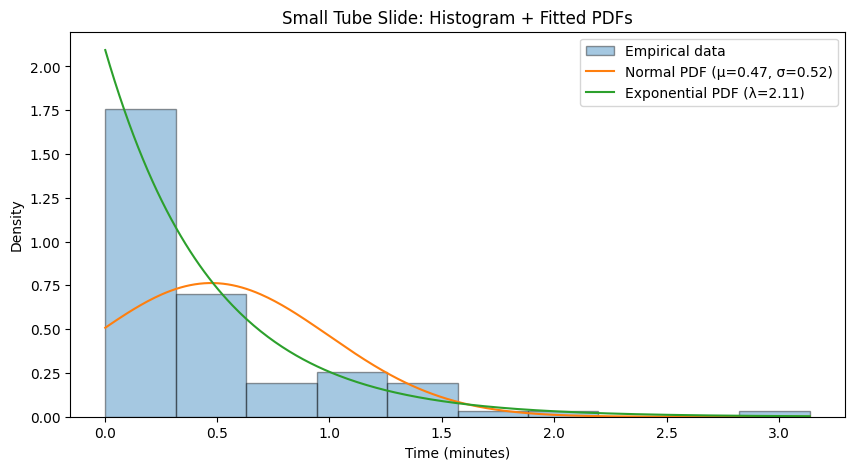

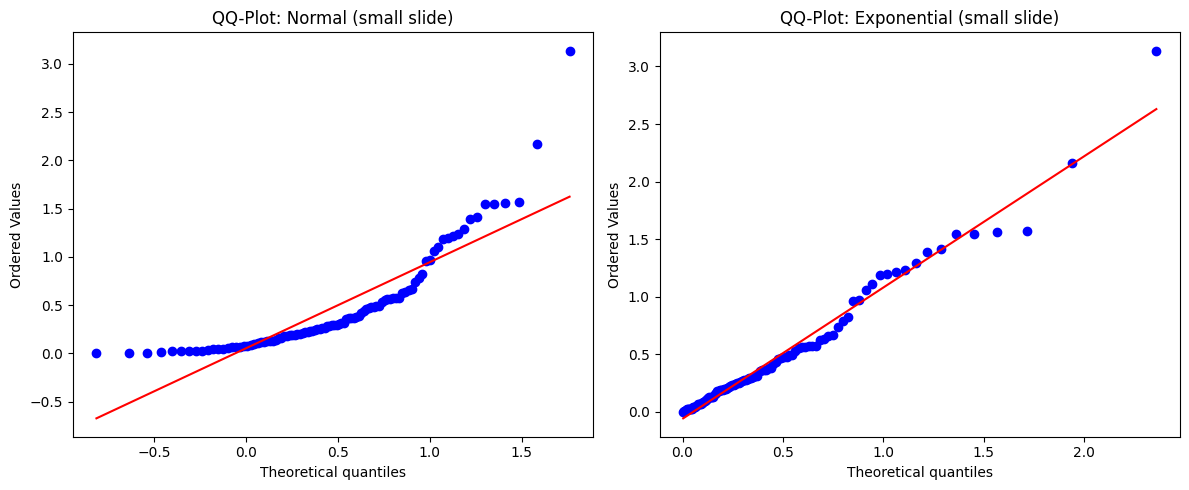

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot

# Assumes df_small already exists and contains a column named "time_minutes"
data_small = df_small["time_minutes"].dropna().to_numpy(dtype=float)

# Fit parameters
mu_small, sigma_small = norm.fit(data_small)     # Normal parameters
lambda_small = 1.0 / np.mean(data_small)         # Exponential rate (MLE), scale = 1/lambda

# ===== 1) Histogram + fitted PDFs =====
plt.figure(figsize=(10, 5))

plt.hist(
    data_small,
    bins=10,
    density=True,
    alpha=0.4,
    edgecolor="black",
    label="Empirical data"
)

x = np.linspace(data_small.min(), data_small.max(), 300)

# Normal PDF
pdf_norm = norm.pdf(x, loc=mu_small, scale=sigma_small)
plt.plot(x, pdf_norm, label=f"Normal PDF (μ={mu_small:.2f}, σ={sigma_small:.2f})")

# Exponential PDF (rate lambda)
pdf_exp = lambda_small * np.exp(-lambda_small * x)
plt.plot(x, pdf_exp, label=f"Exponential PDF (λ={lambda_small:.2f})")

plt.title("Small Tube Slide: Histogram + Fitted PDFs")
plt.xlabel("Time (minutes)")
plt.ylabel("Density")
plt.legend()
plt.show()

# ===== 2) QQ-plots (Normal vs Exponential) =====
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
probplot(data_small, dist="norm", sparams=(mu_small, sigma_small), plot=plt)
plt.title("QQ-Plot: Normal (small slide)")

plt.subplot(1, 2, 2)
probplot(data_small, dist="expon", sparams=(0, 1.0 / lambda_small), plot=plt)
plt.title("QQ-Plot: Exponential (small slide)")

plt.tight_layout()
plt.show()


<div dir="rtl" style="text-align: right;">
לאחר ביצוע ההדמיות והבדיקות הסטטיסטיות עבור משכי ההתגלשות במגלשת האבובים הקטנה מתקבלת תמונה עקבית: ההתפלגות הנורמלית אינה מתאימה לנתונים. הדבר ניכר גם מההשוואה הגרפית, גם מגרף ההשוואה לערכים תאורטיים (גרף נורמליות), וגם ממבחן חי בריבוע שבו הערך המחושב גדול בהרבה מהערך הקריטי.
לעומת זאת, ההתפלגות האקספוננציאלית מתאימה היטב לנתונים: העקומה התאורטית עוקבת אחר צורת ההיסטוגרמה, גרף ההתאמה מציג קו התנהגות כמעט ליניארי, ומבחן ההתאמה המבוסס על המרחק המקסימלי בין התפלגות מצטברת אמפירית לתאורטית (מבחן KS) אינו מצביע על דחיית ההשערה.
לכן אנו מסיקים כי משכי ההתגלשות במגלשה הקטנה מתפלגים בצורה הקרובה להתפלגות אקספוננציאלית.

<div dir="rtl" style="text-align:right; line-height:1.8;">

### אמידת פרמטרים להתפלגות מעריכית (MLE) - מגלשת האבובים הקטנה

נסמן את זמני ההחלקה במדגם שלנו (בדקות) כך:
</div>

$$
x_1, x_2, \ldots, x_n, \qquad n=100, \qquad x_i \ge 0.
$$

<div dir="rtl" style="text-align:right; line-height:1.8;">
נניח שזמן ההחלקה מתפלג מעריכית עם פרמטר קצב <span dir="ltr">\(\lambda>0\)</span>:
</div>

$$
X \sim \mathrm{Exp}(\lambda).
$$

<div dir="rtl" style="text-align:right; line-height:1.8;">
<hr>

### (1) פונקציית צפיפות (PDF)
</div>

$$
f(x;\lambda)=
\begin{cases}
\lambda e^{-\lambda x}, & x\ge 0,\\
0, & x<0.
\end{cases}
$$

<div dir="rtl" style="text-align:right; line-height:1.8;">
<hr>

### (2) פונקציית סבירות (Likelihood)
בהינתן מדגם בלתי תלוי:
</div>

$$
L(\lambda)
=\prod_{i=1}^{n} f(x_i;\lambda)
=\prod_{i=1}^{n}\lambda e^{-\lambda x_i}
=\lambda^{n}\exp\!\left(-\lambda\sum_{i=1}^{n}x_i\right).
$$

<div dir="rtl" style="text-align:right; line-height:1.8;">
<hr>

### (3) לוג־סבירות (Log-Likelihood)
</div>

$$
\ell(\lambda)=\ln L(\lambda)
= n\ln(\lambda)-\lambda\sum_{i=1}^{n}x_i.
$$

<div dir="rtl" style="text-align:right; line-height:1.8;">
<hr>

### (4) מציאת אומד בשיטת MLE
</div>

<div dir="rtl" style="text-align:right; line-height:1.8;">
נסמן את האומד כך:
</div>

$$
\hat{\lambda}
$$

<div dir="rtl" style="text-align:right; line-height:1.8;">
נגזור ונשווה לאפס:
</div>

$$
\frac{d\ell(\lambda)}{d\lambda}
=\frac{n}{\lambda}-\sum_{i=1}^{n}x_i
\overset{!}{=}0
\quad\Longrightarrow\quad
\hat{\lambda}
=\frac{n}{\sum_{i=1}^{n}x_i}
=\frac{1}{\bar{x}}.
$$

<div dir="rtl" style="text-align:right; line-height:1.8;">
כאשר <span dir="ltr">\(\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i\)</span> הוא ממוצע המדגם.
</div>

<div dir="rtl" style="text-align:right; line-height:1.8;">
<hr>

### (5) הצבה לפי הנתונים שלנו (מגלשת האבובים הקטנה)
במדגם שלנו התקבל:
</div>

$$
\bar{x}\approx 0.474595 \ \text{דקות}.
$$

<div dir="rtl" style="text-align:right; line-height:1.8;">
ולכן:
</div>

$$
\hat{\lambda}
=\frac{1}{\bar{x}}
\approx \frac{1}{0.474595}
\approx 2.107060 \ \text{דקות}^{-1}.
$$

<div dir="rtl" style="text-align:right; line-height:1.8;">
מכאן שמודל מעריכי לזמן ההחלקה הוא:
</div>

$$
T \sim \mathrm{Exp}(\hat{\lambda}),
\qquad \hat{\lambda}\approx 2.107060.
$$

<div dir="rtl" style="text-align:right; line-height:1.8;">
ובנוסף, תוחלת זמן ההחלקה היא:
</div>

$$
\mathbb{E}[T]=\frac{1}{\hat{\lambda}}\approx 0.474595 \ \text{דקות}.
$$


In [ ]:
import numpy as np
from scipy.stats import kstest

# --- Assumption: df_small already exists and contains a column named 'time_minutes' ---

# 1) Extract and validate the data
x = np.asarray(df_small["time_minutes"], dtype=float)
x = x[~np.isnan(x)]

print("=== Data sanity checks (df_small) ===")
print("n =", len(x))
print("min =", np.min(x), "| mean =", np.mean(x), "| median =", np.median(x), "| max =", np.max(x))
print("first 10 values:", x[:10])

# If you see negative values, exponential is invalid
if np.min(x) < 0:
    print("\nWARNING: Negative values detected -> exponential distribution is not valid for this dataset.")

# 2) Fit exponential parameter (MLE)
lambda_hat = 1.0 / np.mean(x)      # rate
scale_hat  = 1.0 / lambda_hat      # scale = mean

# 3) One-sample KS test against Exponential(loc=0, scale=scale_hat)
D, p_value = kstest(x, 'expon', args=(0, scale_hat))

# 4) Critical values for KS (approx): D_crit ≈ c(alpha)/sqrt(n)
c_alpha = {0.10: 1.22, 0.05: 1.36, 0.025: 1.48, 0.01: 1.63}

print("\n===== KS Goodness-of-Fit: Exponential (df_small) =====")
print(f"lambda_hat = {lambda_hat:.6f}  (mean ≈ {scale_hat:.6f})")
print(f"KS D = {D:.6f}")
print(f"p-value = {p_value:.6g}")

for a in [0.10, 0.05, 0.025, 0.01]:
    Dcrit = c_alpha[a] / np.sqrt(len(x))
    decision = "FAIL to reject H0 (exponential plausible)" if D < Dcrit else "REJECT H0 (not exponential)"
    print(f"\nalpha = {a}")
    print(f"D_critical ≈ {Dcrit:.6f}")
    print("Decision:", decision)


=== Data sanity checks (df_small) ===
n = 100
min = 0.003034003654 | mean = 0.47459488412489004 | median = 0.28927344779999997 | max = 3.136476429
first 10 values: [0.49457507 1.39004417 0.19514648 1.19489506 0.12604777 0.29599956
 0.07902051 0.63150728 1.10653972 0.06454359]

===== KS Goodness-of-Fit: Exponential (df_small) =====
lambda_hat = 2.107060  (mean ≈ 0.474595)
KS D = 0.068455
p-value = 0.710573

alpha = 0.1
D_critical ≈ 0.122000
Decision: FAIL to reject H0 (exponential plausible)

alpha = 0.05
D_critical ≈ 0.136000
Decision: FAIL to reject H0 (exponential plausible)

alpha = 0.025
D_critical ≈ 0.148000
Decision: FAIL to reject H0 (exponential plausible)

alpha = 0.01
D_critical ≈ 0.163000
Decision: FAIL to reject H0 (exponential plausible)


<div dir="rtl" style="text-align: right; color: blue;">

### התאמת התפלגות:  מגלשת האבובים הקטנה
<div dir="rtl" style="text-align: right;">
לאחר בדיקה חזותית של הנתונים, נבחנה התאמת זמני ההחלקה במגלשת האבובים הקטנה להתפלגות מעריכית.
נסמן את זמני ההחלקה במדגם:

$$
x_1, x_2, \ldots, x_n
$$

גודל המדגם הוא:

$$
n = 100
$$

נניח כי זמני ההחלקה מתפלגים מעריכית:

$$
X \sim \mathrm{Exp}(\lambda)
$$

אומדן הפרמטר בשיטת האמידה המרבית הוא:

$$
\hat{\lambda}
= \frac{n}{\sum_{i=1}^{n} x_i}
= \frac{1}{\bar{x}}
$$

מתוך הנתונים התקבל ממוצע מדגם:

$$
\bar{x} \approx 0.474595
$$

ולכן אומדן הפרמטר הוא:

$$
\hat{\lambda} \approx 2.107060
$$

לאחר אמידת הפרמטר בוצע מבחן KS להשוואה בין ההתפלגות האמפירית
לבין ההתפלגות התאורטית:

$$
\mathrm{Exp}(\hat{\lambda})
$$

סטטיסטי המבחן שהתקבל הוא:

$$
D = 0.068455
$$

וערך ההסתברות הוא:

$$
p\text{-value} \approx 0.710573
$$

נבדקו רמות המובהקות:

$$
\alpha \in \{0.10, 0.05, 0.025, 0.01\}
$$

ובכולן מתקיים:

$$
D < D_{\text{critical}}
$$

ולכן אין עדות סטטיסטית לדחיית השערת האפס.

בהתאם לכך, בסימולציה נגריל זמן החלקה לכל לקוח:

$$
T \sim \mathrm{Exp}(\hat{\lambda})
$$

תוחלת זמן ההחלקה היא:

$$
\mathbb{E}[T] = \frac{1}{\hat{\lambda}} \approx 0.474595
$$




<div dir="rtl" style="text-align: right;">
זמני ההחלקה במגלשת האבובים הקטנה
מתוארים ע"י התפלגות מעריכית עם פרמטר
$$
[
\hat{\lambda} \approx 2.107
]
$$

פרמטר זה ישמש להגרלת זמני החלקה לכל מבקר.

<div dir="rtl" style="text-align: right; color: blue;">

# אלגוריתמי דגימה
בחלק זה מוצגים אלגוריתמי הדגימה שבהם נעשה שימוש בסימולציה. הדגימות מבוססות על משתנה אחיד

U∼U(0,1), וממנו נגזרות דגימות מהתפלגויות אחידה, אקספוננציאלית, נורמלית ואחידה בדידה באמצעות טרנספורמציות מתאימות. בנוסף מוצגים חישובים מתמטיים לדגימת משתנים בזמן, כגון זמני הגעה בחלונות זמן, משכי שירות, משכי פעילות במתקנים וזמני אוכל, בהתאם להתפלגויות שהוגדרו במודל.

<div dir="rtl" style="text-align: right; color: blue;">

## חישוב אלגוריתמי דגימה

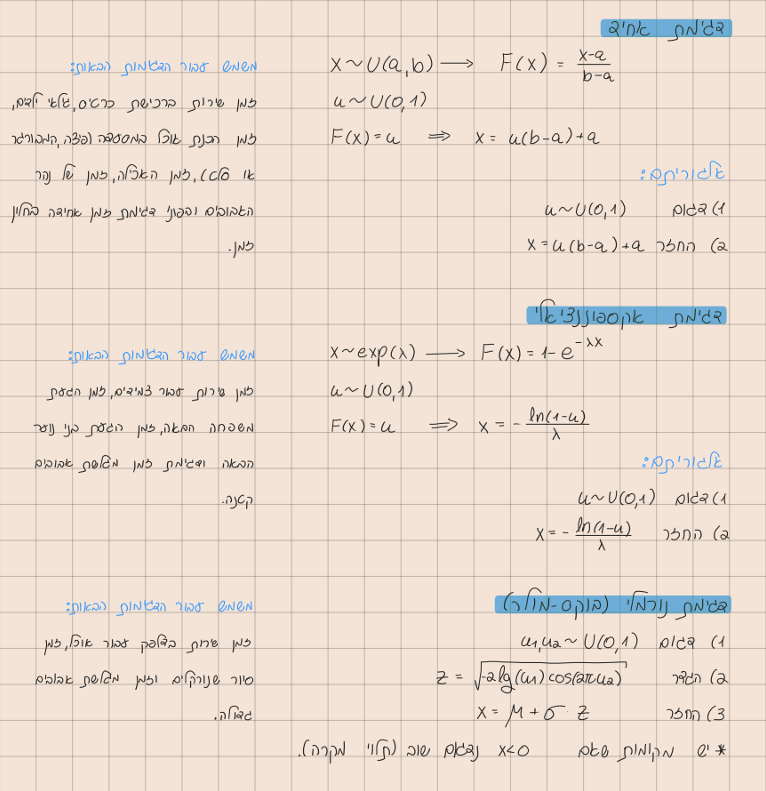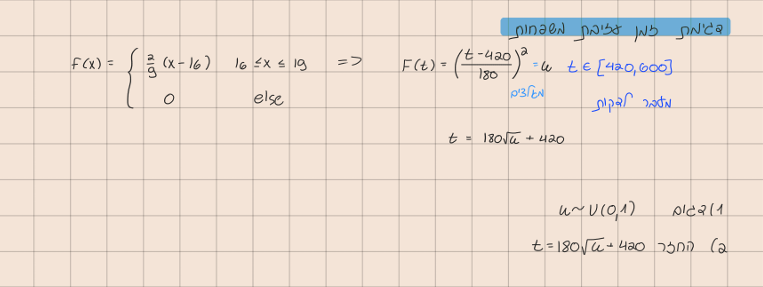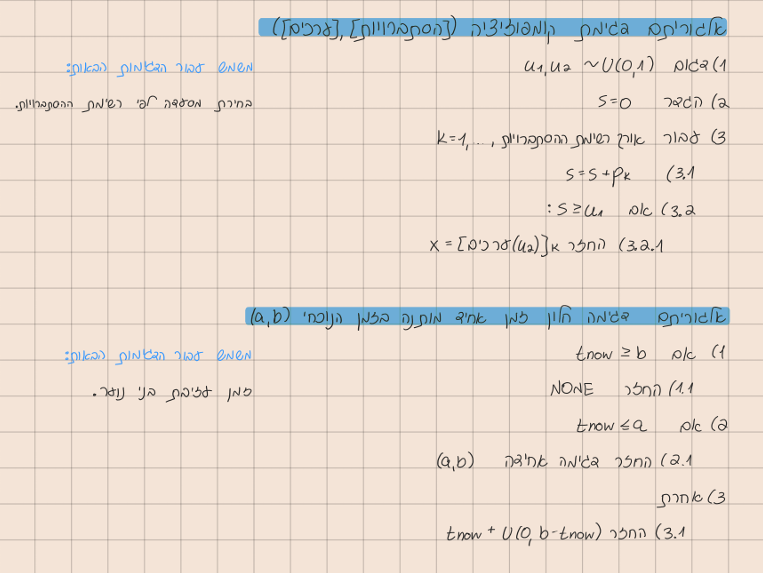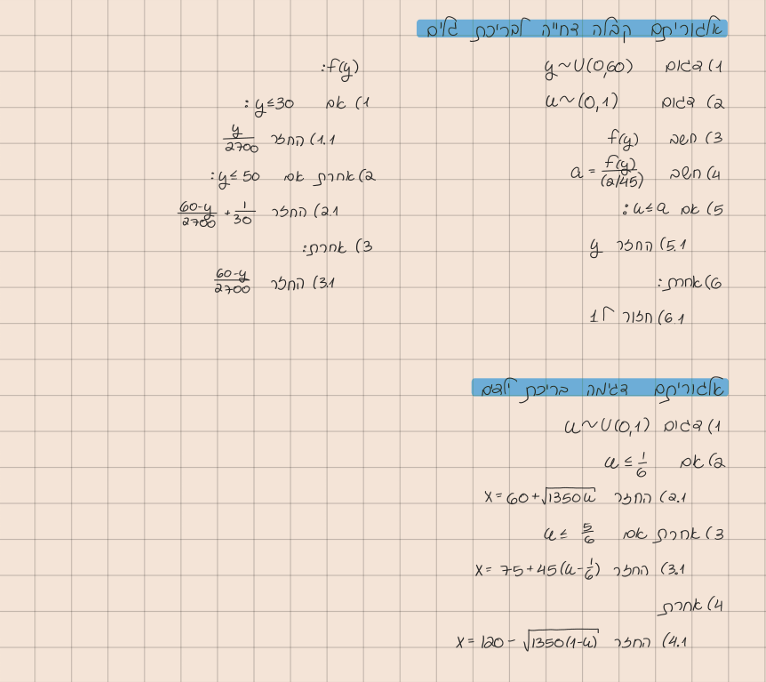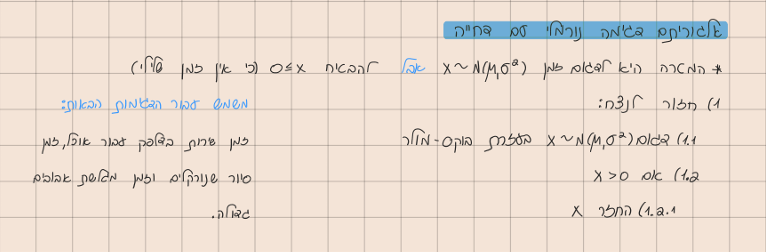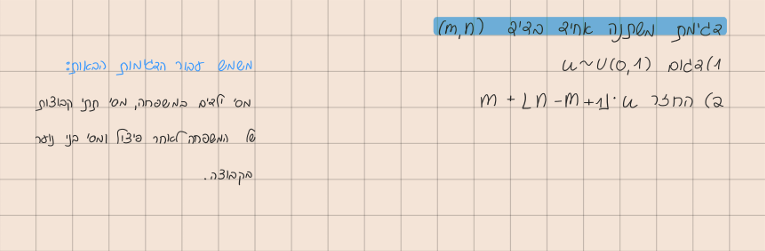

<div dir="rtl" style="text-align: right; color: blue;">

## קוד עבור קבועים וחבילות בסימולציה


In [ ]:
import math
import random
import heapq
import statistics
from typing import List, Optional, Sequence, TypeVar
from scipy.stats import t

T = TypeVar("T")

SEED = 102
_SIM_ALREADY_RAN = False

# Time constants (minutes since 09:00)
OPEN = 0
TEN_AM = 60
ELEVEN_AM = 120
NOON = 180
ONE_PM = 240
TWO_PM = 300
THREE_PM = 360
FOUR_PM = 420
FIVE_PM = 480
SIX_PM = 540
CLOSE = 600
PARK_MAX_RATING = 10.0

# Food-related constants
HAMBURGER = "HAMBURGER"
PIZZA = "PIZZA"
SALAD = "SALAD"

DEPARTURE_BUFFER = 30.0

# Teen abandonment actions
BUY_EXPRESS_AND_JOIN_EXPRESS_QUEUE = "BUY_EXPRESS_AND_JOIN_EXPRESS_QUEUE"
GO_TO_ANOTHER_ATTRACTION = "GO_TO_ANOTHER_ATTRACTION"

ALL_ATTRACTIONS: list[str] = [
    "LazyRiver",
    "SingleSlides",
    "LargeTubeSlide",
    "SmallTubeSlide",
    "WavePool",
    "ToddlerPool",
    "SnorkelTour",
]

# ----------------------------------------------------------- #
# -------------------- SCENARIO CONFIG ---------------------- #
# ----------------------------------------------------------- #

BUDGET = 250_000

# Global knobs (default = BASE)
SCN_LUNCH_PROB = 0.70             # baseline % who choose to eat (within 13:00-15:00 window)
SCN_UNSAT_PROB = 0.10             # baseline bad meal probability
SCN_SINGLE_ARRIVAL_RATE = 2 / 3   # baseline singles arrival rate (per minute)
SCN_WEBSITE_MODE = False          # baseline: ticket + wristband
SCN_LARGE_TUBE_CAPACITY = 8       # baseline capacity per run for LargeTubeSlide (capacity_per_server)

SCENARIOS = {
    "BASE": {
        "invest_cost": 0,
        "lunch_prob": 0.70,
        "unsat_prob": 0.10,
        "single_arrival_rate": 2 / 3,
        "website_mode": False,
        "large_tube_capacity": 8,
        "label": "BASE (No investments)",
    },
    "ALT1": {
        # Better kitchen: unsat_prob -> 0.03, lunch_prob -> 0.85
        # Marketing: singles rate -> 20 per 15 minutes => rate = 20/15 per minute
        # Website: reception service = wristband only
        "invest_cost": 250_000,
        "lunch_prob": 0.85,
        "unsat_prob": 0.03,
        "single_arrival_rate": 20 / 15,
        "website_mode": True,
        "large_tube_capacity": 8,
        "label": "ALT1 (Kitchen+Marketing+Website) [250k]",
    },
    "ALT2": {
        # Website + Large tube capacity 10
        "invest_cost": 250_000,
        "lunch_prob": 0.70,
        "unsat_prob": 0.10,
        "single_arrival_rate": 2 / 3,
        "website_mode": True,
        "large_tube_capacity": 10,
        "label": "ALT2 (Website+LargeTube=10) [250k]",
    },
}

def apply_scenario_to_globals(scn: dict) -> None:
    global SCN_LUNCH_PROB, SCN_UNSAT_PROB, SCN_SINGLE_ARRIVAL_RATE, SCN_WEBSITE_MODE, SCN_LARGE_TUBE_CAPACITY
    SCN_LUNCH_PROB = float(scn["lunch_prob"])
    SCN_UNSAT_PROB = float(scn["unsat_prob"])
    SCN_SINGLE_ARRIVAL_RATE = float(scn["single_arrival_rate"])
    SCN_WEBSITE_MODE = bool(scn["website_mode"])
    SCN_LARGE_TUBE_CAPACITY = int(scn["large_tube_capacity"])


def apply_scenario_to_park_resources(park, scn: dict) -> None:
    # LargeTubeSlide capacity change (ALT2)
    cap = int(scn["large_tube_capacity"])
    park.largeTubeSlide.capacity_per_server = cap
    park.largeTubeSlide.total_capacity = park.largeTubeSlide.servers * park.largeTubeSlide.capacity_per_server

<div dir="rtl" style="text-align: right; color: blue;">

## אאלגוריתמי דגימה כלליים בסימולציה

תת-קוד זה מציג שיטות דגימה שונות, בהתאם למידע המכיל חישובים שהוצגו לפני כן, להמרת מספרים אחידים להתפלגויות מותאמות. אלגוריתמי הדגימה שמומשו משמשים בכל הסימולציה ליצירת משתנים אקראיים כמו זמני שהייה, זמני שירות, וגודל קבוצות, בהתאם להתפלגויות שנקבעו במודל.

In [ ]:
class Sampler:
    # Central place for all random draws in the simulation.
    # Each method samples one specific random quantity (times, choices, sizes, etc.).

    # -------- Generic samplers -------- #

    @staticmethod
    # Draw a continuous value uniformly from [a, b].
    def sample_uniform(a: float, b: float) -> float:
        """Continuous Uniform(a, b)."""
        if b < a:
            raise ValueError("Upper bound must be >= lower bound in sample_uniform.")
        u = random.random()
        return a + (b - a) * u

    @staticmethod
    # Draw an exponential RV using the given rate (lambda).
    def sample_exponential(rate: float) -> float:
        """Exponential with the given rate parameter."""
        if rate <= 0:
            raise ValueError("Rate must be > 0 in sample_exponential.")
        u = random.random()
        return -math.log(1 - u) / rate

    @staticmethod
    # Draw a normal RV using Box-Muller (mean, std).
    def sample_normal(mean: float, std: float) -> float:
        """Normal via Box-Muller."""
        if std <= 0:
            raise ValueError("Standard deviation must be > 0 in sample_normal.")
        u1 = random.random()
        u2 = random.random()
        z = math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)
        return mean + std * z

    @staticmethod
    # Draw an integer uniformly from {m, m+1, ..., n}.
    def sample_discrete_uniform(m: int, n: int) -> int:
        """Discrete uniform on integers [m, n]."""
        if n < m:
            raise ValueError("Upper bound must be >= lower bound in sample_discrete_uniform.")
        u = random.random()
        return m + int((n - m + 1) * u)

    @staticmethod
    # Draw a value from a finite set using explicit probabilities.
    def sample_discrete_by_probs(values: Sequence[T], probs: Sequence[float]) -> T:
        """Sample from provided values with matching probabilities."""
        if len(values) != len(probs) or len(values) == 0:
            raise ValueError("Values and probs must be non-empty and of equal length.")
        if any(p < 0 for p in probs):
            raise ValueError("Probabilities must be non-negative.")
        total = sum(probs)
        if total == 0:
            raise ValueError("Sum of probabilities must be greater than zero.")
        if abs(total - 1.0) > 1e-9:
            raise ValueError("Probabilities must sum to 1.0.")
        u = random.random()
        s = 0.0
        for value, p in zip(values, probs):
            s += p
            if u <= s:
                return value
        return values[-1]

    @staticmethod
    # Uniform draw in [a, b] but conditioned on "now":
    # if we already passed a, sample from [t_now, b]; if past b, return None.
    def sample_time_uniform_window(a: float, b: float, t_now: float) -> Optional[float]:
        """Uniform in [a, b] conditioned on current time; returns None if t_now >= b."""
        if t_now >= b:
            return None
        if t_now <= a:
            return Sampler.sample_uniform(a, b)
        return t_now + Sampler.sample_uniform(0, b - t_now)

    @staticmethod
    # Piecewise PDF used for WavePool duration (support [0,60]).
    def f(x):
        if x <= 30:
            return (x / 2700)
        if x <= 50:
            return ((60 - x) / (2700) + (1 / 30))
        if x <= 60:
            return ((60 - x) / (2700))
        return 0

    @staticmethod
    # Acceptance-Rejection sampler for the WavePool duration distribution on [0,60].
    def sample_acceptance_rejection():
        while True:
            y = 60 * random.random()
            u2 = random.random()
            a = Sampler.f(y) / (2 / 45)
            if u2 <= a:
                return y

    # -------- Reception (Entrance) -------- #

    @staticmethod
    # Time to buy tickets at the entrance counter.
    def sample_ticket_purchase_service_time() -> float:
        """Ticket purchase time ~ Uniform(0.5, 2)."""
        return Sampler.sample_uniform(0.5, 2.0)

    @staticmethod
    # Time to issue wristband after ticket purchase.
    def sample_wristband_service_time() -> float:
        """Wristband issuing time ~ Exponential(rate=0.5)."""
        return Sampler.sample_exponential(0.5)

    @staticmethod
    # Whether a visitor buys express wristband at entry (fixed probability).
    def sample_buy_express_at_entrance() -> bool:
        """Buy express at entrance with probability 0.25."""
        return random.random() <= 0.25

    # -------- Families -------- #

    @staticmethod
    # Next family arrival time (arrivals only until noon).
    def next_family_arrival_time(t_now: float) -> Optional[float]:
        if t_now >= NOON:
            return None
        inter = Sampler.sample_exponential(0.6666666667)
        t_next = t_now + inter
        return t_next if t_next <= NOON else None

    @staticmethod
    # Number of children in a family (1..5).
    def sample_num_children_in_family():
        return Sampler.sample_discrete_uniform(1, 5)

    @staticmethod
    # Child age in years (continuous).
    def sample_child_age():
        return Sampler.sample_uniform(2, 18)

    @staticmethod
    # Whether a family splits into multiple groups inside the park.
    def sample_family_splits():
        u = random.random()
        return u <= 0.6

    @staticmethod
    # If split happens: number of resulting groups (2 or 3).
    def sample_num_groups_after_split():
        return Sampler.sample_discrete_uniform(2, 3)

    @staticmethod
    # Sample family departure time with given CDF on [16:00, 19:00], conditioned on t_now.
    def sample_family_departure_time(t_now: float) -> Optional[float]:
        """Family departure time on [420, 600] with CDF ((t-420)/180)^2, conditioned so t >= t_now."""
        if t_now >= CLOSE:
            return None
        if t_now <= FOUR_PM:
            u = random.random()
            return FOUR_PM + 180.0 * math.sqrt(u)
        s0 = (t_now - FOUR_PM) / 180.0
        u = random.random()
        s = math.sqrt(s0 * s0 + (1.0 - s0 * s0) * u)
        return FOUR_PM + 180.0 * s

    @staticmethod
    # Families abandon a regular queue after a fixed patience (minutes).
    def family_queue_abandon_time(t_join_queue: float) -> float:
        patience = 15
        return t_join_queue + patience

    # -------- Teenagers -------- #

    @staticmethod
    # Next teens arrival time (arrivals start at 10:00, stop at 16:00).
    def next_teens_arrival_time(t_now: float) -> Optional[float]:
        base_time = max(t_now, TEN_AM)
        if base_time >= FOUR_PM:
            return None
        inter = Sampler.sample_exponential(1.3888889)
        t_next = base_time + inter
        return t_next if t_next <= FOUR_PM else None

    @staticmethod
    # Teen group size distribution (2-3, 4-5, or 6).
    def sample_teen_group_size():
        u = random.random()
        if u <= 0.4:
            return Sampler.sample_discrete_uniform(2, 3)
        if u <= 0.9:
            return Sampler.sample_discrete_uniform(4, 5)
        return 6

    @staticmethod
    # Teens abandon a regular queue after a fixed patience (minutes).
    def teen_queue_abandon_time(t_join_queue: float) -> float:
        """Abandonment time for teens in regular queue."""
        patience = 20
        return t_join_queue + patience

    @staticmethod
    # Singles (or "individuals") abandon a regular queue after a fixed patience (minutes).
    def single_queue_abandon_time(t_join_queue: float) -> float:
        patience = 30
        return t_join_queue + patience

    @staticmethod
    # Teens leave at park closing (in this model).
    def sample_teen_departure_time(t_now: float) -> Optional[float]:
        return CLOSE

    # -------- singles -------- #

    @staticmethod
    # Next single arrival time; scenario-controlled arrival rate; stop 30 minutes before close.
    def next_single_arrival_time(t_now: float) -> Optional[float]:
        if t_now >= CLOSE - 30:
            return None
        inter = Sampler.sample_exponential(SCN_SINGLE_ARRIVAL_RATE)  # <-- scenario-controlled
        t_next = t_now + inter
        return t_next if t_next <= CLOSE - 30 else None

    @staticmethod
    # Singles leave at park closing (in this model).
    def sample_single_departure_time(t_now: float) -> Optional[float]:
        return CLOSE

    # -------- Food (Restaurants) -------- #

    @staticmethod
    # Decide whether a visitor goes to lunch (only between 13:00 and 15:00).
    def decide_go_to_lunch(t_now: float) -> bool:
        """Between 13:00-15:00 (240-360), go to lunch with probability; otherwise False."""
        if t_now < 240 or t_now > 360:
            return False
        return random.random() <= SCN_LUNCH_PROB  # <-- scenario-controlled

    @staticmethod
    # Choose which restaurant the visitor goes to (fixed mix probabilities).
    def sample_restaurant_choice():
        """Choose restaurant per given probabilities."""
        values = [HAMBURGER, PIZZA, SALAD]
        probs = [3 / 8, 1 / 4, 3 / 8]
        return Sampler.sample_discrete_by_probs(values, probs)

    @staticmethod
    # Food prep time depends on the chosen restaurant.
    def sample_food_prep_time_by_restaurant(restaurant: str) -> float:
        """Prep time depends on restaurant."""
        if restaurant == PIZZA:
            return Sampler.sample_uniform(4, 6)
        if restaurant == HAMBURGER:
            return Sampler.sample_uniform(3, 4)
        if restaurant == SALAD:
            return Sampler.sample_uniform(3, 7)
        raise ValueError("Unknown restaurant for prep time sampling.")

    @staticmethod
    # Service time at the counter (payment + handoff); normal, resample if negative.
    def sample_food_service_time_at_counter() -> float:
        """Counter service ~ Normal(5, 1.5) with rejection of negatives."""
        t = Sampler.sample_normal(5, 1.5)
        while t < 0:
            t = Sampler.sample_normal(5, 1.5)
        return t

    @staticmethod
    # How long the visitor spends eating (not including prep/counter).
    def sample_meal_duration() -> float:
        """Meal duration ~ Uniform(15, 35)."""
        return Sampler.sample_uniform(15, 35)

    @staticmethod
    # Expected prep time (mean) per restaurant (used for analytics / sanity checks).
    def expected_food_prep_time_by_restaurant(restaurant: str) -> float:
        if restaurant == PIZZA:
            return 5.0
        if restaurant == HAMBURGER:
            return 3.5
        if restaurant == SALAD:
            return 5.0
        raise ValueError("Unknown restaurant for expected prep time.")

    @staticmethod
    # Expected counter service time (mean) for Normal(5,1.5) truncated at 0.
    def expected_food_service_time_at_counter() -> float:
        # Mean of Normal(5,1.5) truncated to t >= 0.
        mu = 5.0
        sigma = 1.5
        alpha = -mu / sigma
        sqrt_2 = math.sqrt(2.0)
        phi = math.exp(-0.5 * alpha * alpha) / math.sqrt(2.0 * math.pi)
        Phi = 0.5 * (1.0 + math.erf(alpha / sqrt_2))
        tail = 1.0 - Phi
        return mu + sigma * (phi / tail)

    @staticmethod
    # Expected meal duration (mean of Uniform(15,35)).
    def expected_meal_duration() -> float:
        return 25.0

    @staticmethod
    # Satisfaction outcome after eating; probability is scenario-controlled.
    def sample_food_satisfaction() -> str:
        """Return SATISFIED/UNSATISFIED with scenario-controlled probability."""
        return "UNSATISFIED" if random.random() <= SCN_UNSAT_PROB else "SATISFIED"  # <-- scenario-controlled

    # -------- Attractions (Ride/Activity durations) -------- #

    @staticmethod
    # Time spent on Lazy River.
    def sample_lazy_river_duration() -> float:
        """Lazy River duration ~ Uniform(20, 30)."""
        return Sampler.sample_uniform(20, 30)

    @staticmethod
    # Single slides ride time (fixed).
    def sample_single_slide_duration() -> float:
        """Single Slide duration is constant 3."""
        return 3.0

    @staticmethod
    # Time spent at Wave Pool (sampled with acceptance-rejection).
    def sample_wave_pool_duration() -> float:
        """Wave pool stay duration via acceptance-rejection on [0, 60]."""
        return Sampler.sample_acceptance_rejection()

    @staticmethod
    # Time spent at Toddler/Kids pool based on given piecewise distribution.
    def sample_kids_pool_duration() -> float:
        """Kids pool stay duration (minutes) via piecewise inverse CDF on [60, 120]."""
        u = random.random()
        if u <= (1 / 6):
            return 60 + math.sqrt(1350 * u)
        if u <= (5 / 6):
            return 75 + 45 * (u - 1 / 6)
        return 120 - math.sqrt(1350 * (1 - u))

    @staticmethod
    # Snorkel tour duration; normal with rejection of negatives.
    def sample_snorkel_tour_duration() -> float:
        """Snorkel tour duration ~ Normal(30, 10) with rejection of negatives."""
        t = Sampler.sample_normal(30, 10)
        while t < 0:
            t = Sampler.sample_normal(30, 10)
        return t

    @staticmethod
    # Large tube slide duration; normal with rejection of negatives.
    def sample_big_tube_slide_duration() -> float:
        """Big tube slide duration ~ Normal(mean=4.8, std=1.83); rejects negatives."""
        t = Sampler.sample_normal(4.8, 1.83)
        while t < 0:
            t = Sampler.sample_normal(4.8, 1.83)
        return t

    @staticmethod
    # Small tube slide duration; exponential (rate given).
    def sample_small_tube_slide_duration() -> float:
        """Small tube slide duration ~ Exponential(rate=2.107)."""
        return Sampler.sample_exponential(2.107)

    @staticmethod
    # Single dispatcher for ride durations by attraction name.
    def sample_attraction_duration(attraction_name: str) -> float:
        """Dispatch to the appropriate attraction duration sampler by name."""
        duration_by_name = {
            "LazyRiver": Sampler.sample_lazy_river_duration,
            "SingleSlides": Sampler.sample_single_slide_duration,
            "LargeTubeSlide": Sampler.sample_big_tube_slide_duration,
            "SmallTubeSlide": Sampler.sample_small_tube_slide_duration,
            "WavePool": Sampler.sample_wave_pool_duration,
            "ToddlerPool": Sampler.sample_kids_pool_duration,
            "SnorkelTour": Sampler.sample_snorkel_tour_duration,
        }
        try:
            sampler = duration_by_name[attraction_name]
        except KeyError:
            raise ValueError(f"Unknown attraction: {attraction_name}")
        return sampler()

    # -------- Project policy samplers -------- #

    @staticmethod
    # Same as entrance express decision: 25% at entry.
    def sample_has_express_at_entry() -> bool:
        # 25% buy express at entrance
        return random.random() <= 0.25

    @staticmethod
    # Family size (project version): 2 parents + U{1..5} kids.
    def sample_family_size_project() -> int:
        # 2 parents + U{1..5} kids
        return 2 + Sampler.sample_discrete_uniform(1, 5)

    @staticmethod
    # Teens group size (project version): same distribution as above.
    def sample_teens_group_size_project() -> int:
        # 2–3 with p=0.4, 4–5 with p=0.5, 6 with p=0.1
        u = random.random()
        if u <= 0.4:
            return Sampler.sample_discrete_uniform(2, 3)
        if u <= 0.9:
            return Sampler.sample_discrete_uniform(4, 5)
        return 6

    @staticmethod
    # Arrival window for families (minutes since open).
    def sample_family_arrival_window() -> tuple[float, float]:
        return OPEN, NOON

    @staticmethod
    # Arrival window for teens (minutes since open).
    def sample_teens_arrival_window() -> tuple[float, float]:
        return TEN_AM, FOUR_PM

    @staticmethod
    # Arrival window for singles (minutes since open).
    def sample_single_arrival_window() -> tuple[float, float]:
        return OPEN, CLOSE - 30

    @staticmethod
    # Parent age sampling (continuous).
    def sample_parent_age() -> float:
        return Sampler.sample_uniform(25.0, 55.0)

    @staticmethod
    # Teen age sampling (continuous).
    def sample_teen_age() -> float:
        return Sampler.sample_uniform(14.0, 17.999)

    @staticmethod
    # Single visitor age sampling (continuous).
    def sample_single_age() -> float:
        return Sampler.sample_uniform(18.0, 60.0)




<div dir="rtl" style="text-align: right; color: blue;">

# מחלקות
זהו בלוק המחלקות של הפארק. כאן אנו מגדירים את היישויות המרכזיות שמרכיבות את הסימולציה (מבקרים, מתקנים, תורים, קבלה ואוכל). כל מחלקה מתארת "אובייקט בעולם" עם שדות (מצב/נתונים) ומתודות (התנהגות), וביחד הן יוצרות את הבסיס שעליו מנוע האירועים מפעיל את הפארק לאורך ציר הזמן.

In [ ]:
import heapq
import random
from typing import Optional

class PriorityQueue:
    """
    Wrapper around heapq to manage visitor queues.
    Ensures stability and priority handling (Express vs Regular).
    """
    def __init__(self) -> None:
        # Tuple structure: (Priority Enum, Join Time, Unique Counter, Visitor Object).
        # _counter ensures FIFO behavior for items with equal priority and time.
        self._heap: list[tuple[int, float, int, "Visitor"]] = []
        self._counter: int = 0

    def push(self, visitor: "Visitor", is_express: bool, join_time: float) -> None:
        # Priority 0 is Express (higher priority), 1 is Regular.
        priority = 0 if is_express else 1
        item = (priority, float(join_time), self._counter, visitor)
        heapq.heappush(self._heap, item)
        self._counter += 1

    def peek_item(self) -> Optional[tuple[int, float, int, "Visitor"]]:
        """Return the head item without removing it, or None if empty."""
        return self._heap[0] if self._heap else None

    def pop_item(self) -> tuple[int, float, int, "Visitor"]:
        """Remove and return the head item. Raises IndexError if empty."""
        return heapq.heappop(self._heap)

    # --- Optional backwards-compatible aliases (keep only if old code still calls them) ---

    def peek(self) -> Optional[tuple[int, float, int, "Visitor"]]:
        return self.peek_item()

    def pop(self) -> tuple[int, float, int, "Visitor"]:
        return self.pop_item()

    # --- Utility ---

    def __len__(self) -> int:
        return len(self._heap)

    def is_empty(self) -> bool:
        return not self._heap

    def items(self) -> list[tuple[int, float, int, "Visitor"]]:
        """Debug/inspection helper (unordered heap view)."""
        return list(self._heap)

    def reset(self) -> None:
        self._heap.clear()
        self._counter = 0

    def remove_visitor(self, target: "Visitor") -> bool:
        # Linear scan to remove a specific visitor (O(N)). Re-heapifies if removal occurs.
        n0 = len(self._heap)
        if n0 == 0:
            return False
        self._heap = [item for item in self._heap if item[3] is not target]
        removed = (len(self._heap) != n0)
        if removed:
            heapq.heapify(self._heap)
        return removed

class Attraction:
    """Queue-managed attraction with express priority and FIFO within each priority."""

    def __init__(
        self,
        name: str,
        servers: int,
        capacity_per_server: int,
        adrenaline: int,
        break_time: float = 0.0,
        min_age: float = 0.0,
        max_age: float = 100.0,
    ) -> None:
        self.name = name
        self.servers = servers
        self.capacity_per_server = capacity_per_server
        self.adrenaline = adrenaline
        self.closed: bool = False

        # Hardcoded configuration for specific attractions overriding defaults.
        if name == "SnorkelTour":
            self.break_time = 30.0
        elif name == "SingleSlides":
            self.break_time = 0.5
        else:
            self.break_time = break_time

        # Headway definitions: Minimum time interval between dispatches.
        headway_by_name = {
            "SingleSlides": 0.0,
            "SnorkelTour": 10.0,
            "SmallTubeSlide": 0.0,
            "LargeTubeSlide": 5.0,
            "WavePool": 10.0,
            "ToddlerPool": 7.0,
            "LazyRiver": 0.0,
        }
        self.headway_time: float = float(headway_by_name.get(name, 0.0))

        self.min_age = min_age
        self.max_age = max_age
        self.total_capacity = servers * capacity_per_server

        # State arrays to track each server's availability and load.
        self.next_free_time_array: list[float] = [0.0 for _ in range(servers)]
        self.is_running_array: list[bool] = [False for _ in range(servers)]
        self.in_service_list_per_server: list[list[tuple["Visitor", "Visitor"]]] = [[] for _ in range(servers)]
        self.pending_boarded_per_server: list[list[tuple["Visitor", "Visitor"]]] = [[] for _ in range(servers)]
        self.pending_headway_deadline_per_server: list[Optional[float]] = [None for _ in range(servers)]
        self.pending_duration_per_server: list[Optional[float]] = [None for _ in range(servers)]
        self.Q = PriorityQueue()

    def allows_age(self, age: float) -> bool:
        return self.min_age <= float(age) <= self.max_age

    def reset(self) -> None:
        # Full state reset for simulation restarts.
        self.next_free_time_array = [0.0 for _ in range(self.servers)]
        self.is_running_array = [False for _ in range(self.servers)]
        self.in_service_list_per_server = [[] for _ in range(self.servers)]
        self.pending_boarded_per_server = [[] for _ in range(self.servers)]
        self.pending_headway_deadline_per_server = [None for _ in range(self.servers)]
        self.pending_duration_per_server = [None for _ in range(self.servers)]
        self.Q.reset()
        self.closed = False

    def enqueue(self, visitor: "Visitor", t_now: float) -> None:
        if self.closed:
            visitor.status = "IN_PARK"
            return
        if not visitor.can_enter_attraction(self):
            visitor.status = "IN_PARK"
            return
        visitor.status = "IN_QUEUE"

        # Prepares the visitor group structure for the specific logic of this queue.
        visitor.reset_split_for_new_attraction_queue()
        self.Q.push(visitor, visitor.has_express, t_now)

    def available_server_to_fill(self, t_now: float) -> int:
        # Returns index of first server that is not running and past its free time.
        for idx in range(self.servers):
            if self.pending_boarded_per_server[idx]:
                continue
            if (not self.is_running_array[idx]) and (t_now >= self.next_free_time_array[idx]):
                return idx
        return -1

    def q_length(self) -> int:
        """Total number of people currently waiting in this attraction's queue."""
        return sum(item[3].group_in_queue for item in self.Q.items())

    def sample_duration_and_finish(self, t_now: float) -> tuple[float, float]:
        # External dependency: Sampler class (assumed to exist in context).
        duration = Sampler.sample_attraction_duration(self.name)
        return duration, t_now + duration

    def fill_one_server_from_queue(
        self,
        server_idx: int,
        t_now: float,
        target_list: Optional[list[tuple["Visitor", "Visitor"]]] = None,
    ) -> int:
        """
        Core Boarding Logic:
        Fills a specific server to capacity. Handles group splitting if necessary
        (if a group of 4 arrives but only 2 seats remain).
        """
        if server_idx < 0 or server_idx >= self.servers:
            raise IndexError("Invalid server index")

        if self.is_running_array[server_idx] or t_now < self.next_free_time_array[server_idx]:
            return 0

        if target_list is None:
            target_list = self.in_service_list_per_server[server_idx]

        seats_left = self.capacity_per_server
        allocated = 0

        while seats_left > 0:
            head_item = self.Q.peek_item()
            if head_item is None:
                break

            visitor = head_item[3]
            waiting = int(visitor.group_in_queue)

            if waiting <= 0:
                self.Q.pop_item()
                continue

            # Determine how many members from the current group can board.
            k = min(seats_left, waiting)

            # Move members from "queue" state to "boarding" state.
            allocated_members = visitor.take_k_members(k)
            for member in allocated_members:
                target_list.append((member, visitor))

            visitor.group_in_queue -= k
            visitor.group_in_attraction += k

            seats_left -= k
            allocated += k

            # Remove group from queue only if fully boarded.
            if visitor.group_in_queue == 0:
                self.Q.pop_item()
                continue

            continue

        return allocated

    def can_start(self, t_now: float) -> bool:
        if self.closed:
            return False
        return (self.available_server_to_fill(t_now) != -1) and (self.q_length() > 0)

    def _start_run_with_boarded(
        self,
        server_idx: int,
        t_now: float,
        duration: float,
        boarded: list[tuple["Visitor", "Visitor"]],
    ) -> float:
        finish_time = t_now + duration
        self.in_service_list_per_server[server_idx] = list(boarded)
        boarded.clear()
        self.is_running_array[server_idx] = True
        self.next_free_time_array[server_idx] = finish_time + self.break_time
        return finish_time

    def is_running(self) -> bool:
        return any(self.is_running_array)

    def start_servers_if_possible(self, t_now: float) -> tuple[list[tuple[int, float]], list[tuple[int, float]]]:
        """
        Main simulation step for this attraction.
        Checks for available servers, fills them, handles headway constraints,
        and triggers start events.
        """
        started: list[tuple[int, float]] = []
        headway_waiting: list[tuple[int, float]] = []

        if self.closed:
            return started, headway_waiting

        # 1. Process servers that were pending (already filled but waiting for start trigger/time).
        if self.q_length() > 0:
            for idx in range(self.servers):
                if self.is_running_array[idx] or t_now < self.next_free_time_array[idx]:
                    continue
                if not self.pending_boarded_per_server[idx]:
                    continue
                # Fill remaining spots if new people arrived while pending.
                self.fill_one_server_from_queue(
                    idx,
                    t_now,
                    target_list=self.pending_boarded_per_server[idx],
                )
                duration = self.pending_duration_per_server[idx]
                if duration is None:
                    duration, finish_time = self.sample_duration_and_finish(t_now)
                    if finish_time > CLOSE: # Global 'CLOSE' constant assumed
                        self.closed = True
                        return started, headway_waiting
                finish_time = self._start_run_with_boarded(
                    idx, t_now, duration, self.pending_boarded_per_server[idx]
                )
                self.pending_headway_deadline_per_server[idx] = None
                self.pending_duration_per_server[idx] = None
                started.append((idx, finish_time))

        # 2. Process idle servers that need filling.
        for idx in range(self.servers):
            if self.is_running_array[idx] or t_now < self.next_free_time_array[idx]:
                continue
            if self.pending_boarded_per_server[idx]:
                continue
            if self.q_length() == 0:
                continue

            duration, finish_time = self.sample_duration_and_finish(t_now)
            if finish_time > CLOSE:
                self.closed = True
                return started, headway_waiting

            # Logic for attractions requiring headway (minimum spacing).
            if self.headway_time > 0.0:
                allocated = self.fill_one_server_from_queue(
                    idx,
                    t_now,
                    target_list=self.pending_boarded_per_server[idx],
                )
                if allocated <= 0:
                    continue

                # If not full, wait for more people or headway deadline.
                if allocated < self.capacity_per_server and self.q_length() == 0:
                    latest_finish = t_now + self.headway_time + duration
                    if latest_finish <= CLOSE:
                        deadline = t_now + self.headway_time
                        self.pending_headway_deadline_per_server[idx] = deadline
                        self.pending_duration_per_server[idx] = duration
                        headway_waiting.append((idx, deadline))
                        continue

                finish_time = self._start_run_with_boarded(
                    idx, t_now, duration, self.pending_boarded_per_server[idx]
                )
                self.pending_headway_deadline_per_server[idx] = None
                self.pending_duration_per_server[idx] = None
                started.append((idx, finish_time))
            else:
                # Standard immediate launch logic.
                allocated = self.fill_one_server_from_queue(idx, t_now)
                if allocated <= 0:
                    continue
                self.is_running_array[idx] = True
                self.next_free_time_array[idx] = finish_time + self.break_time
                started.append((idx, finish_time))

        return started, headway_waiting

    def complete_server(self, server_idx: int) -> list[tuple["Visitor", "Visitor"]]:
        """Finalize the ride for a server, releasing visitors and resetting counters."""
        if server_idx < 0 or server_idx >= self.servers:
            raise IndexError("Invalid server index")

        serviced = list(self.in_service_list_per_server[server_idx])

        # Decrease group counts for the parent visitors.
        counts: dict["Visitor", int] = {}
        for _, parent in serviced:
            counts[parent] = counts.get(parent, 0) + 1
        for parent, cnt in counts.items():
            remaining = parent.group_in_attraction - cnt
            if remaining < 0:
                raise RuntimeError("group_in_attraction cannot be negative after completion")
            parent.group_in_attraction = remaining

        self.in_service_list_per_server[server_idx] = []
        self.is_running_array[server_idx] = False

        return serviced

    def remove_from_queue(self, visitor: "Visitor") -> bool:
        """Remove visitor from this attraction waiting queue."""
        return self.Q.remove_visitor(visitor)


# --- SERVICE FACILITIES (RECEPTION & FOOD) ---

class Reception:
    def __init__(self, servers: int) -> None:
        if servers <= 0:
            raise ValueError("Reception servers must be positive")
        self.servers = servers
        self.busy = 0
        self.Q = PriorityQueue()

    def reset(self) -> None:
        self.busy = 0
        self.Q.reset()

    def can_start_service(self) -> bool:
        return self.busy < self.servers

    def start_service(self) -> None:
        if not self.can_start_service():
            raise RuntimeError("Reception cannot start service now")
        self.busy += 1

    def finish_service(self) -> None:
        if self.busy <= 0:
            raise RuntimeError("finish_service called with no busy reception servers")
        self.busy -= 1

    def enqueue(self, visitor: "Visitor", t_now: float) -> None:
        self.Q.push(visitor, False, t_now)

    def is_queue_empty(self) -> bool:
        return len(self.Q) == 0

    def sample_reception_service_time(self) -> float:
        # Website scenario: "bracelet only"
        if SCN_WEBSITE_MODE: # Global flag assumed
            return Sampler.sample_wristband_service_time()
        return Sampler.sample_ticket_purchase_service_time() + Sampler.sample_wristband_service_time()


class Restaurant:
    def __init__(self, name: str, servers: int) -> None:
        if servers <= 0:
            raise ValueError(f"Restaurant servers must be positive: {name}")
        self.name = name
        self.servers = servers
        self.busy = 0
        self.Q = PriorityQueue()

    def has_free_server(self) -> bool:
        return self.busy < self.servers

    def start_service(self) -> None:
        if self.busy >= self.servers:
            raise RuntimeError(f"No free servers available in restaurant: {self.name}")
        self.busy += 1

    def finish_service(self) -> None:
        if self.busy <= 0:
            raise RuntimeError(f"finish_service called with no busy servers in restaurant: {self.name}")
        self.busy -= 1

    def reset(self) -> None:
        self.busy = 0
        self.Q.reset()

    def enqueue(self, visitor: "Visitor", t_now_value: float, is_express: bool = False) -> None:
        self.Q.push(visitor, is_express, t_now_value)


class FoodCourt:
    """Aggregator for multiple Restaurant instances (Hamburger, Pizza, Salad)."""
    def __init__(self, hamburger_servers: int, pizza_servers: int, salad_servers: int) -> None:
        if hamburger_servers <= 0 or pizza_servers <= 0 or salad_servers <= 0:
            raise ValueError("FoodCourt restaurant server counts must be positive")
        # Global constants (HAMBURGER, PIZZA, SALAD) assumed.
        self.restaurants: dict[str, dict[str, object]] = {
            HAMBURGER: {"restaurant": Restaurant(HAMBURGER, hamburger_servers), "price": 100.0},
            PIZZA: {
                "restaurant": Restaurant(PIZZA, pizza_servers),
                "family_price": 100.0,
                "personal_price": 40.0,
            },
            SALAD: {"restaurant": Restaurant(SALAD, salad_servers), "price": 65.0},
        }
        self.income: float = 0.0

    def add_income(self, amount: float) -> None:
        if amount < 0:
            raise ValueError("Income amount must be non-negative")
        self.income += amount

    def get_price(self, restaurant_name: str, visitor: "Visitor") -> int:
        if restaurant_name not in self.restaurants:
            raise ValueError(f"Unknown restaurant: {restaurant_name}")
        entry = self.restaurants[restaurant_name]
        # Pizza has dynamic pricing based on group size.
        if restaurant_name == PIZZA:
            return int(entry["personal_price"]) if visitor.group_size == 1 else int(entry["family_price"])
        return int(entry["price"])

    def reset(self) -> None:
        self.income = 0.0
        for entry in self.restaurants.values():
            entry["restaurant"].reset()


# --- VISITORS ---

class Visitor:
    """
    Base class representing a Visitor or a Group.
    Implements a Composite-like structure where 'members' list contains individual entities.
    """
    def __init__(self) -> None:
        self.name: str = "Visitor"
        self.group_size: int = 1
        self.has_express: bool = False
        self.max_wait_time: Optional[float] = None
        self.age: Optional[float] = 0.0
        self.departure_time: float = CLOSE
        self.has_eaten: bool = False
        self.going_to_lunch: bool = False
        self.arrival_window_start: float = OPEN
        self.arrival_window_end: float = CLOSE
        self.current_location: Optional[str] = None

        self.status: str = "IN_REC"
        self.rating: float = 10.0
        self.remaining_attractions: list["Attraction"] = []
        self.waiting_in_attraction: Optional["Attraction"] = None

        # Tracking members within the group during queue/ride splits.
        self.members: list["Visitor"] = [self]
        self.group_in_queue: int = 0
        self.group_in_attraction: int = 0
        self._member_cursor: int = 0
        self.parent_group: Optional["Visitor"] = None
        self.member_index: Optional[int] = None
        self.photos_processed: bool = False
        self.reception_paid: bool = False
        self.leave_counted: bool = False

    def reset_runtime_state(self) -> None:
        self.status = "IN_REC"
        self.group_in_attraction = 0
        self.group_in_queue = 0
        self._member_cursor = 0

    def can_abandon_queue(self) -> bool:
        return not self.has_express

    def choose_restaurant(self) -> str:
        return Sampler.sample_restaurant_choice()

    def should_go_to_lunch(self, t_now: float) -> bool:
        return Sampler.decide_go_to_lunch(t_now) and not self.has_eaten

    def can_enter_attraction(self, attraction: "Attraction") -> bool:
        return attraction.allows_age(float(self.age))

    def choose_next_attraction(self, t_now: float) -> Attraction:
        return random.choice(self.remaining_attractions)

    def post_abandon_action(self) -> Optional[str]:
        return None

    def has_remaining_attractions(self) -> bool:
        return len(self.remaining_attractions) > 0

    def mark_attraction_completed(self, attraction: "Attraction") -> None:
        if attraction in self.remaining_attractions:
            self.remaining_attractions.remove(attraction)

    def apply_post_attraction_rating(self, attraction: "Attraction") -> None:
        # Rating update logic based on random satisfaction chance and adrenaline.
        gs = float(self.group_size)
        adrenaline = float(attraction.adrenaline)
        if random.random() <= 0.5:
            score = ((gs - 1.0) / 5.0) * 0.3 + ((adrenaline - 1.0) / 4.0) * 0.7
            self.rating = min(PARK_MAX_RATING, float(self.rating) + score)
        else:
            self.rating = max(0.0, float(self.rating) - 0.1)

    def reset_split_for_new_attraction_queue(self) -> None:
        """Resets internal counters to prepare for entering a new waiting line."""
        self.group_in_queue = self.group_size
        self.group_in_attraction = 0
        self._member_cursor = 0

    def take_k_members(self, k: int) -> list["Visitor"]:
        """
        Slices the 'members' list to return a subset of the group.
        Used when an attraction can only fit part of the group.
        """
        if k < 0 or k > self.group_in_queue:
            raise RuntimeError("take_k_members called with k outside waiting group size.")
        if self._member_cursor + k > len(self.members):
            raise RuntimeError("take_k_members would exceed available members.")
        start = self._member_cursor
        end = start + k
        self._member_cursor = end
        return self.members[start:end]


class Family(Visitor):
    """
    Complex Visitor type that supports splitting into subgroups and reuniting.
    Manages a hierarchy of root family and subgroups.
    """
    _FAMILY_UID_COUNTER = 0

    def __init__(self, t_now: float) -> None:
        super().__init__()
        self.name = "Family"
        size = Sampler.sample_family_size_project()
        num_children = max(0, size - 2)
        # First 2 are parents, rest are children.
        self.ages: list[float] = [
            Sampler.sample_parent_age(),
            Sampler.sample_parent_age(),
        ] + [Sampler.sample_child_age() for _ in range(num_children)]
        if len(self.ages) != size:
            raise RuntimeError("Family ages list must match sampled size")

        self.has_express = False
        self.max_wait_time = 15.0
        self.arrival_window_start, self.arrival_window_end = Sampler.sample_family_arrival_window()
        t_dep = Sampler.sample_family_departure_time(t_now)
        self.departure_time = CLOSE if t_dep is None else float(t_dep)
        self._need_reunite: bool = self.departure_time < CLOSE
        self._departure_triggered: bool = False
        self._ready_to_leave: set[int] = set()
        self._subgroup_ids: set[int] = {0}
        self._exited: bool = False
        self._meeting_check_scheduled: bool = False

        self._assign_members_from_ages(self.ages)
        self.original_group_size: int = self.group_size
        self.age = self.members[0].age if self.members else 0.0

        Family._FAMILY_UID_COUNTER += 1
        self.family_uid: int = Family._FAMILY_UID_COUNTER

        # Hierarchy tracking
        self.parent_family_uid: int = self.family_uid
        self.subgroup_id: Optional[int] = None
        self._next_subgroup_id: int = 1
        self.root_family: "Family" = self
        self.family_units: list["Family"] = [self]

        self.has_split = False
        self.subgroups: list["Family"] = []
        self.did_all_ages_first: bool = False

    def _assign_members_from_ages(self, ages: list[float]) -> None:
        members: list[Visitor] = []
        for idx, age in enumerate(ages):
            person = Visitor()
            person.age = float(age)
            person.remaining_attractions = []
            person.group_size = 1
            person.members = [person]
            person.has_express = self.has_express
            person.max_wait_time = self.max_wait_time
            person.departure_time = self.departure_time
            person.parent_group = self
            person.member_index = idx
            members.append(person)
        self.members = members
        self.group_size = len(members)

    def can_enter_attraction(self, attraction: "Attraction") -> bool:
        return all(attraction.allows_age(float(m.age)) for m in self.members)

    def create_subgroup_from_indices(self, member_indices: list[int]) -> "Family":
        """Factory method to create a new Family instance representing a subgroup."""
        if self.root_family is not self:
            raise RuntimeError("Only the root family may create subgroups.")
        if not member_indices:
            raise ValueError("member_indices cannot be empty")

        if any((i < 0 or i >= len(self.ages)) for i in member_indices):
            raise ValueError("member_indices contains out-of-range index")

        unique_sorted = sorted(set(member_indices))
        subgroup_ages = [self.ages[i] for i in unique_sorted]

        subgroup = Family.__new__(Family)
        Visitor.__init__(subgroup)
        subgroup.name = "Family"
        # Copy config from parent
        subgroup.has_express = self.has_express
        subgroup.max_wait_time = self.max_wait_time
        subgroup.arrival_window_start = self.arrival_window_start
        subgroup.arrival_window_end = self.arrival_window_end
        subgroup.departure_time = self.departure_time
        subgroup.has_eaten = self.has_eaten
        subgroup.going_to_lunch = self.going_to_lunch
        subgroup.remaining_attractions = list(self.remaining_attractions)
        subgroup.status = "IN_PARK"
        subgroup.rating = 0.0
        subgroup.did_all_ages_first = self.did_all_ages_first

        subgroup.ages = list(subgroup_ages)
        if len(subgroup.ages) <= 0:
            raise RuntimeError("Subgroup group_size must be positive")
        subgroup._assign_members_from_ages(subgroup.ages)
        subgroup.original_group_size = subgroup.group_size
        subgroup.age = subgroup.members[0].age if subgroup.members else 0.0

        subgroup.family_uid = self.family_uid
        subgroup.parent_family_uid = self.parent_family_uid

        subgroup.subgroup_id = self._next_subgroup_id
        self._next_subgroup_id += 1

        subgroup._next_subgroup_id = 1
        subgroup.has_split = False
        subgroup.subgroups = []
        root = self.root_family
        subgroup.root_family = root
        subgroup.family_units = root.family_units
        root.family_units.append(subgroup)
        root.subgroup_ids.add(subgroup.subgroup_id)

        # Remove members from current object to move them to subgroup
        for i in reversed(unique_sorted):
            del self.ages[i]
        self._assign_members_from_ages(self.ages)
        self.age = self.members[0].age if self.members else 0.0

        self.has_split = True
        self.subgroups.append(subgroup)

        return subgroup

    def validate_conservation(self) -> None:
        """Ensures total number of family members remains constant across splits."""
        if self.subgroup_id is not None:
            return
        total = self.group_size + sum(sg.group_size for sg in self.subgroups)
        if total != self.original_group_size:
            raise RuntimeError(
                f"Family size conservation violated: expected {self.original_group_size}, got {total}"
            )

    def split_into_subgroups(self, num_subgroups: int) -> list["Family"]:
        """
        Divides the family into 2 or 3 distinct groups based on logic (parents splitting children).
        Updates state to reflect the split.
        """
        if num_subgroups not in (2, 3):
            raise ValueError("num_subgroups must be 2 or 3")
        if len(self.ages) < 2:
            raise RuntimeError("Family must have two parents at indices 0 and 1 to split")
        if self.has_split or self.subgroups:
            raise RuntimeError("Family has already been split")

        parent_indices = [0, 1]
        children_indices = list(range(2, len(self.ages)))

        index_sets: list[list[int]]
        if num_subgroups == 2:
            # Alternating assignment of children to parents.
            sg1_indices = [parent_indices[0]]
            sg2_indices = [parent_indices[1]]
            toggle = 0
            for child_idx in children_indices:
                if toggle == 0:
                    sg1_indices.append(child_idx)
                else:
                    sg2_indices.append(child_idx)
                toggle = 1 - toggle
            index_sets = [sg1_indices, sg2_indices]
        else:
            # Split into 3: Parent 1, Parent 2, Eldest child takes remaining kids.
            if not children_indices:
                raise ValueError("Cannot split into 3 subgroups without at least one child")
            eldest_child_idx = max(children_indices, key=lambda i: self.ages[i])
            remaining_children = [i for i in children_indices if i != eldest_child_idx]
            sg1_indices = [parent_indices[0]]
            sg2_indices = [parent_indices[1]]
            sg3_indices = [eldest_child_idx]
            dests = [sg1_indices, sg2_indices, sg3_indices]
            turn = 0
            for idx in remaining_children:
                dests[turn].append(idx)
                turn = (turn + 1) % 3
            index_sets = dests

        created: list["Family"] = []
        removed: set[int] = set()
        for orig_indices in index_sets:
            adjusted: list[int] = []
            # Index adjustment needed because removing items shifts subsequent indices.
            for idx in sorted(orig_indices):
                offset = sum(1 for r in removed if r < idx)
                adjusted.append(idx - offset)
            subgroup = self.create_subgroup_from_indices(adjusted)
            subgroup.original_group_size = subgroup.group_size
            created.append(subgroup)
            removed.update(orig_indices)

        self.subgroups = created
        self.has_split = True
        self.validate_conservation()
        return created

    def total_people_in_family_tree(self) -> int:
        return self.group_size + sum(sg.group_size for sg in self.subgroups)

    # Property proxies to access root family state from any subgroup.
    @property
    def need_reunite(self) -> bool:
        return self.root_family._need_reunite

    @property
    def departure_triggered(self) -> bool:
        return self.root_family._departure_triggered

    @departure_triggered.setter
    def departure_triggered(self, value: bool) -> None:
        self.root_family._departure_triggered = bool(value)

    @property
    def ready_to_leave(self) -> set[int]:
        return self.root_family._ready_to_leave

    @property
    def subgroup_ids(self) -> set[int]:
        return self.root_family._subgroup_ids

    @property
    def exited(self) -> bool:
        return self.root_family._exited

    @exited.setter
    def exited(self, value: bool) -> None:
        self.root_family._exited = bool(value)

    def effective_subgroup_id(self) -> int:
        return 0 if self.subgroup_id is None else int(self.subgroup_id)

    def can_abandon_queue(self) -> bool:
        return not self.has_express

    def choose_next_attraction(self, t_now: float) -> "Attraction":
        """
        Decision Logic:
        Prioritizes "All Ages" attractions first, then picks the shortest queue.
        """
        def queue_len(attr: "Attraction") -> int:
            if hasattr(attr, "q_length"):
                return attr.q_length()
            return sum(v.group_size for _, _, _, v in attr.Q.items())

        def pick_min_queue(cands: list[tuple[int, "Attraction"]]) -> "Attraction":
            m = min(q for q, _ in cands)
            tied = [attr for q, attr in cands if q == m]
            return random.choice(tied)

        if not self.remaining_attractions:
            raise RuntimeError("No remaining attractions to choose from")

        all_ages_names = {"LazyRiver", "LargeTubeSlide"}
        if not self.did_all_ages_first:
            candidates = [
                (queue_len(attr), attr)
                for attr in self.remaining_attractions
                if attr.name in all_ages_names and self.can_enter_attraction(attr)
            ]
            if candidates:
                return pick_min_queue(candidates)
            self.did_all_ages_first = True

        candidates = [
            (queue_len(attr), attr)
            for attr in self.remaining_attractions
            if self.can_enter_attraction(attr)
        ]
        if not candidates:
            raise RuntimeError("No feasible attractions to choose from")
        return pick_min_queue(candidates)

    def mark_attraction_completed(self, attraction: "Attraction") -> None:
        super().mark_attraction_completed(attraction)


class Teens(Visitor):
    """
    Teens behavior: Specific group size, tendency to seek adrenaline,
    and capability to 'detour' if a queue is too long.
    """
    def __init__(self, t_now: float) -> None:
        super().__init__()
        self.name = "Teens"
        size = Sampler.sample_teens_group_size_project()
        self.ages: list[float] = [Sampler.sample_teen_age() for _ in range(size)]
        self.has_express = False
        self.max_wait_time = 20.0
        self.arrival_window_start, self.arrival_window_end = Sampler.sample_teens_arrival_window()
        self.departure_time = CLOSE
        self._assign_members_from_ages(self.ages)
        self.age = self.members[0].age if self.members else Sampler.sample_teen_age()
        self.pending_return_attraction: Optional["Attraction"] = None
        self.detour_done: bool = False
        self.returning_to_pending: bool = False

    def _assign_members_from_ages(self, ages: list[float]) -> None:
        members: list[Visitor] = []
        for idx, age in enumerate(ages):
            person = Visitor()
            person.age = float(age)
            person.group_size = 1
            person.members = [person]
            person.has_express = self.has_express
            person.max_wait_time = self.max_wait_time
            person.departure_time = self.departure_time
            person.parent_group = self
            person.member_index = idx
            person.remaining_attractions = []
            members.append(person)
        self.members = members
        self.group_size = len(members)

    def can_abandon_queue(self) -> bool:
        return not self.has_express

    def can_enter_attraction(self, attraction: "Attraction") -> bool:
        return all(attraction.allows_age(float(m.age)) for m in self.members)

    def post_abandon_action(self) -> str:
        return BUY_EXPRESS_AND_JOIN_EXPRESS_QUEUE if random.random() <= 0.6 else GO_TO_ANOTHER_ATTRACTION

    def choose_next_attraction(self, t_now: float) -> "Attraction":
        """
        Logic:
        1. Handle detours (returning to a previously skipped attraction).
        2. Prefer high-adrenaline rides.
        3. Fallback to random choice.
        """
        if not self.remaining_attractions:
            raise RuntimeError("No remaining attractions to choose from")

        self.returning_to_pending = False

        if self.pending_return_attraction is not None:
            if not self.detour_done:
                non_pending = [
                    attr for attr in self.remaining_attractions
                    if attr is not self.pending_return_attraction and self.can_enter_attraction(attr)
                ]
                if non_pending:
                    chosen = random.choice(non_pending)
                    self.detour_done = True
                    return chosen

            if self.pending_return_attraction in self.remaining_attractions and self.can_enter_attraction(self.pending_return_attraction):
                self.returning_to_pending = True
                chosen = self.pending_return_attraction
                self.pending_return_attraction = None
                self.detour_done = False
                return chosen
            else:
                self.pending_return_attraction = None
                self.detour_done = False

        adrenaline_candidates = [
            attr for attr in self.remaining_attractions
            if attr.adrenaline >= 3 and self.can_enter_attraction(attr)
        ]
        if adrenaline_candidates:
            return random.choice(adrenaline_candidates)

        fallback = [attr for attr in self.remaining_attractions if self.can_enter_attraction(attr)]
        if not fallback:
            raise RuntimeError("No feasible attractions to choose from")
        return random.choice(fallback)


class Single(Visitor):
    """
    Single visitor behavior: Two-phase attraction strategy (Phase 1 first, then Phase 2).
    Always picks the shortest queue.
    """
    def __init__(self, t_now: float = 0.0) -> None:
        super().__init__()
        self.name = "Single"
        self.age: float = Sampler.sample_single_age()
        self.group_size = 1
        self.has_express = False
        self.max_wait_time = 30.0
        self.arrival_window_start, self.arrival_window_end = Sampler.sample_single_arrival_window()
        self.departure_time = CLOSE
        self.did_phase1: bool = False
        self.phase2_attractions: list["Attraction"] = []
        member = Visitor()
        member.age = self.age
        member.group_size = 1
        member.members = [member]
        member.has_express = self.has_express
        member.max_wait_time = self.max_wait_time
        member.departure_time = self.departure_time
        member.parent_group = self
        member.member_index = 0
        member.remaining_attractions = []
        self.members = [member]
        self.group_size = len(self.members)

    def choose_next_attraction(self, t_now: float) -> "Attraction":
        def queue_len(attr: "Attraction") -> int:
            if hasattr(attr, "q_length"):
                return attr.q_length()
            return sum(v.group_size for _, _, _, v in attr.Q.items())

        def pick_min_queue(cands: list[tuple[int, "Attraction"]]) -> "Attraction":
            m = min(q for q, _ in cands)
            tied = [attr for q, attr in cands if q == m]
            return random.choice(tied)

        if not self.remaining_attractions:
            raise RuntimeError("No remaining attractions to choose from")

        # Switch to phase 2 list if phase 1 is done.
        if not self.did_phase1 and not self.remaining_attractions:
            self.remaining_attractions = list(self.phase2_attractions)
            self.did_phase1 = True

        candidates = [
            (queue_len(attr), attr)
            for attr in self.remaining_attractions
            if self.can_enter_attraction(attr)
        ]
        if not candidates:
            raise RuntimeError("No feasible attractions to choose from")
        return pick_min_queue(candidates)

    def can_abandon_queue(self) -> bool:
        return not self.has_express

    def mark_attraction_completed(self, attraction: "Attraction") -> None:
        super().mark_attraction_completed(attraction)
        if not self.did_phase1 and not self.remaining_attractions:
            self.remaining_attractions = list(self.phase2_attractions)
            self.did_phase1 = True

<div dir="rtl" style="text-align: right; color: blue;">

##פונקציות תומכות מחלקות



In [ ]:
def snorkel_is_on_lunch(t_now: float) -> bool:
    """
    Checks if the Snorkel attraction is currently on its lunch break.
    """
    return ONE_PM <= t_now < TWO_PM


def register_family_unit(families: dict[int, "Family"], family_unit: "Family", close_time: float = CLOSE) -> None:
    """
    Registers a family subgroup (or root) into the main families dictionary.
    Ensures the root family knows about all its split units for tracking.
    """
    root: "Family" = getattr(family_unit, "root_family", family_unit)
    # Determine if this family needs to meet up before leaving (only if leaving before close).
    root._need_reunite = float(root.departure_time) < float(close_time)
    families[root.family_uid] = root

    subgroup_id = 0 if family_unit.subgroup_id is None else int(family_unit.subgroup_id)
    root.subgroup_ids.add(subgroup_id)

    if family_unit not in root.family_units:
        root.family_units.append(family_unit)


def trigger_family_departure(families: dict[int, "Family"], root_uid: int, t_now: float, park=None) -> None:
    """
    Sets the departure flag for an entire family tree.
    Marks all subgroups with status 'EXITING' so they stop queuing.
    """
    root = families.get(root_uid)
    if root is None:
        return
    if root.departure_triggered:
        return
    root.departure_triggered = True
    for unit in getattr(root, "family_units", [root]):
        unit.status = "EXITING"


def finalize_family_unit_exit(park, family_unit: "Family", t_now: float) -> None:
    """
    Helper to finalize the exit of a specific family unit.
    Delegates to the root logic to ensure consistency.
    """
    root = getattr(family_unit, "root_family", family_unit)
    finalize_reunited_family_exit(park, root, t_now)


def finalize_group_exit(park, visitor: "Visitor", t_now: float) -> None:
    """
    Handles the exit process for non-family groups (Singles/Teens).
    Updates park statistics (visitors leaving, ratings) and schedules photo purchase.
    """
    if visitor is None:
        return
    if getattr(visitor, "leave_counted", False):
        visitor.status = "EXITED"
        return
    if park is None:
        visitor.leave_counted = True
        visitor.status = "EXITED"
        return

    visitor.leave_counted = True
    visitor.status = "EXITED"

    gs = int(getattr(visitor, "group_size", 1))
    park.customers_leaving += gs
    # Accumulate weighted rating.
    park.total_rating += float(visitor.rating) * float(gs)

    park.schedule_event(PhotoPurchaseEvent(t_now, visitor))


def notify_family_unit_idle_and_ready_to_leave(families: dict[int, "Family"], family_unit: "Family", t_now: float) -> bool:
    """
    Signals that a specific family subgroup is idle and ready to leave.
    Returns True if *all* subgroups are now ready to leave (reunion complete).
    """
    root: "Family" = families.get(family_unit.family_uid, getattr(family_unit, "root_family", None))
    if root is None:
        return False

    if not (root.need_reunite and root.departure_triggered):
        return False

    subgroup_id = 0 if family_unit.subgroup_id is None else int(family_unit.subgroup_id)
    root.ready_to_leave.add(subgroup_id)

    return root.ready_to_leave == root.subgroup_ids


def _family_tree_finished_all_attractions(root: "Family") -> bool:
    """
    Internal helper to check if every unit in the family tree has finished their planned attractions.
    Returns False if anyone is currently eating lunch or has rides left.
    """
    for unit in getattr(root, "family_units", [root]):
        if getattr(unit, "going_to_lunch", False):
            return False
        if unit.has_remaining_attractions():
            return False
    return True


def should_exit_now(families: dict[int, "Family"], visitor: "Visitor", t_now: float, close_time: float = CLOSE, park=None) -> bool:
    """
    Determines if a visitor should attempt to exit the park.

    Logic:
    1. Standard visitors: Leave if done with rides or park is closing.
    2. Families: Leave if time matches departure_time OR finished rides.
    3. Handles triggering the departure flag if this is the first check that passes.
    """
    close_time = float(close_time)

    # --- Case 1: Non-Family Visitor ---
    if not isinstance(visitor, Family):
        if (not getattr(visitor, "going_to_lunch", False)) and (not visitor.has_remaining_attractions()):
            return True
        return t_now >= close_time

    # --- Case 2: Family Visitor ---
    root: "Family" = families.get(visitor.family_uid, getattr(visitor, "root_family", None))
    if root is None:
        # Fallback if linkage is broken
        if (not getattr(visitor, "going_to_lunch", False)) and (not visitor.has_remaining_attractions()):
            return True
        return t_now >= float(visitor.departure_time)

    dep_time = float(root.departure_time)
    all_done = _family_tree_finished_all_attractions(root)

    # Check if departure condition is met (time or task completion)
    if (t_now >= dep_time) or all_done:
        if not root.departure_triggered:
            trigger_family_departure(families, root.family_uid, t_now, park=park)

    if not root.need_reunite:
        return root.departure_triggered

    # If reuniting is required, only return True if ALL subgroups are ready.
    return root.departure_triggered and (root.ready_to_leave == root.subgroup_ids)


def finalize_close(families: dict[int, "Family"], t_now: float, close_time: float = CLOSE, park=None) -> None:
    """
    Forces park closure. Iterates over all visitors (Families, Teens, Singles)
    who haven't left yet and processes their exit stats.
    """
    close_time = float(close_time)

    # Flush all Families
    for root in list(families.values()):
        if getattr(root, "exited", False):
            continue
        if not getattr(root, "reception_paid", False):
            continue

        # Force reunite all subgroups for calculation
        if root.need_reunite:
            root.ready_to_leave.clear()
            root.ready_to_leave.update(root.subgroup_ids)

        for unit in getattr(root, "family_units", [root]):
            finalize_family_unit_exit(park, unit, t_now)

        root.exited = True

    if park is None:
        return

    # Flush Teens
    for visitor in list(getattr(park, "teens_groups", {}).values()):
        if getattr(visitor, "leave_counted", False):
            continue
        if not getattr(visitor, "reception_paid", False):
            continue
        finalize_group_exit(park, visitor, t_now)

    # Flush Singles
    for visitor in list(getattr(park, "singles", {}).values()):
        if getattr(visitor, "leave_counted", False):
            continue
        if not getattr(visitor, "reception_paid", False):
            continue
        finalize_group_exit(park, visitor, t_now)


def finalize_reunited_family_exit(park, root: "Family", t_now: float) -> None:
    """
    Calculates final stats for a Family tree upon exit.
    Aggregates group sizes and computes weighted average rating from all subgroups.
    """
    if root is None or getattr(root, "exited", False):
        return

    units = list(getattr(root, "family_units", [root]))
    total_size = 0
    weighted_sum = 0.0
    for unit in units:
        gs = int(getattr(unit, "group_size", 1))
        total_size += gs
        weighted_sum += float(getattr(unit, "rating", 0.0)) * float(gs)

    combined_rating = (weighted_sum / total_size) if total_size > 0 else 0.0
    root.rating = combined_rating

    park.customers_leaving += int(total_size)
    park.total_rating += float(total_size) * float(root.rating)
    park.schedule_event(PhotoPurchaseEvent(t_now, root))

    for unit in units:
        unit.status = "EXITED"
        unit.leave_counted = True

    root.exited = True


def schedule_meeting_check_if_needed(park, unit, t_now: float) -> None:
    """
    Schedules a 'MeetingCheckEvent' to poll for family reunification.
    Prevents duplicate scheduling if a check is already pending.
    """
    if not isinstance(unit, Family):
        return
    root = unit.root_family
    if getattr(root, "exited", False):
        return
    if getattr(root, "_meeting_check_scheduled", False):
        return
    root._meeting_check_scheduled = True
    park.schedule_event(MeetingCheckEvent(t_now + 1.0, unit))


def try_reunite_and_finalize_family_exit(park, family_unit: "Family", t_now: float) -> None:
    """
    Main logic for family exit.

    1. Checks if exit conditions (time/rides) are met.
    2. Triggers departure if needed.
    3. If reunification is required (need_reunite=True):
       - Checks if the unit is idle (not in queue/ride).
       - Marks unit as 'ready_to_leave'.
       - If waiting for others, sets status to 'WAITING_MEET' and schedules check.
       - If everyone is ready, calls finalize_reunited_family_exit.
    """
    if family_unit is None:
        return

    root: "Family" = getattr(family_unit, "root_family", family_unit)
    if root is None:
        return

    if getattr(root, "exited", False):
        return

    # Cannot leave if anyone is currently at lunch
    for unit in getattr(root, "family_units", [root]):
        if getattr(unit, "going_to_lunch", False):
            return

    # Check departure trigger
    if not root.departure_triggered:
        all_done = _family_tree_finished_all_attractions(root)
        if all_done or t_now >= float(root.departure_time):
            trigger_family_departure(park.families, root.family_uid, t_now, park=park)
        # If still not triggered, we are just waiting around, potentially schedule a check
        if not root.departure_triggered:
            family_unit.status = "WAITING_MEET"
            schedule_meeting_check_if_needed(park, family_unit, t_now)
            return

    # If simple exit (no reunion needed), just leave
    if not root.need_reunite:
        finalize_reunited_family_exit(park, root, t_now)
        return

    # Reunion Logic: Ensure unit is completely idle
    is_idle = (
        family_unit.status != "IN_QUEUE"
        and not getattr(family_unit, "going_to_lunch", False)
        and int(getattr(family_unit, "group_in_attraction", 0)) == 0
        and int(getattr(family_unit, "group_in_queue", 0)) == 0
    )
    if not is_idle:
        return

    subgroup_id = 0 if family_unit.subgroup_id is None else int(family_unit.subgroup_id)
    root.ready_to_leave.add(subgroup_id)

    # Check if other subgroups are ready
    if root.ready_to_leave != root.subgroup_ids:
        family_unit.status = "WAITING_MEET"
        schedule_meeting_check_if_needed(park, family_unit, t_now)
        return

    # Everyone is ready
    finalize_reunited_family_exit(park, root, t_now)

<div dir="rtl" style="text-align: right; color: blue;">

# אירועים
בלוק זה הוא מנוע הסימולציה. כאן מוגדרים כל סוגי האירועים שמקדמים את הזמן וגורמים לשינויים במצב הפארק. מחלקת הבסיס Event מגדירה זמן ומתודת handle, ושאר האירועים יורשים ממנה ומממשים התנהגות ייעודית. האירועים מחולקים לאירועי הגעה, סיום קניית כרטיס, מתקנים, ואוכל, וכל אירוע אחראי לבצע פעולה אחת ברורה ולתזמן את האירועים הבאים.

<div dir="rtl" style="text-align: right; color: blue;">

##תרשים אירועים



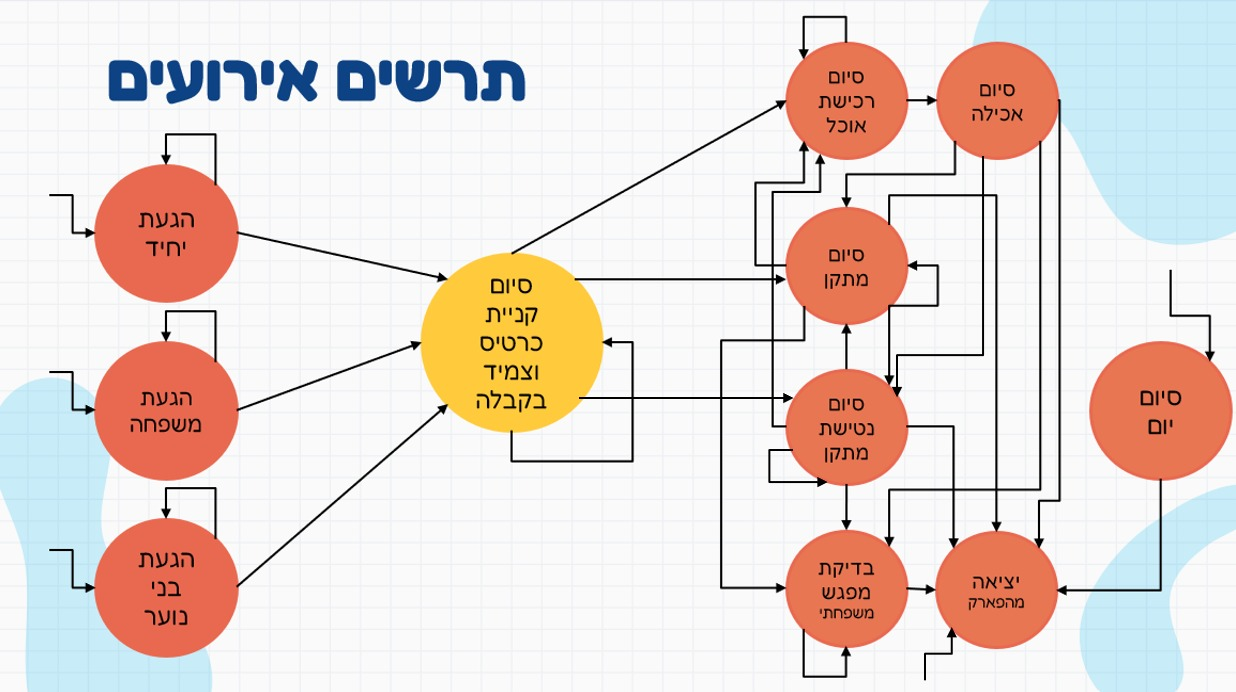

<div dir="rtl" style="text-align: right; color: blue;">

**לוגיקה כללית של הסימולציה**

המערכת פועלת כסימולציית אירועים בדידים (Discrete-Event Simulation). הזמן מתקדם רק מנקודת אירוע אחת לבאה אחריה, וכל אירוע עשוי לעדכן את מצב המערכת ולתזמן אירועים עתידיים. יומן האירועים מנוהל כערימת מינימום לפי זמן, כך שבכל רגע מטופל האירוע הקרוב ביותר בזמן.

**אירועי הגעה**

אירועי ההגעה מייצגים כניסה של קבוצות מבקרים מסוגים שונים לפארק, כאשר לכל סוג מבקר חלון הגעה וקצב הגעה משלו. בעת טיפול באירוע הגעה, נוצרת קבוצת מבקרים חדשה (כולל דגימת גודל קבוצה ומאפייני המבקר), ומתוזמן אירוע הגעה נוסף מאותו סוג, כל עוד הזמן נמצא בתוך חלון ההגעה המוגדר.
בנוסף, כל מבקר שמגיע נשלח מיידית למערכת הקבלה. אם יש שרת פנוי בקבלה, השירות מתחיל מיד ומתוזמן אירוע סיום קבלה. אחרת, המבקר נכנס לתור הקבלה.

**אירוע סיום קבלה**

אירוע זה מייצג סיום טיפול בקופה (רכישת כרטיס וצמיד, או צמיד בלבד בהתאם לתרחיש). בטיפול באירוע מתבצע עדכון של נתוני המבקר: חישוב הכנסות, דגימת רכישת אקספרס, ואתחול רשימת המתקנים אליהם הוא יכול לגשת.
לאחר מכן, המבקר נשלח למתקן הראשון שלו (ייתכן והמבקר ינטוש את המתקן הראשון).

במידה ומבקר מסיים בקבלה בין השעות 13:00 ל15:00 ויצא בהסתברות שהוא הולך לאכול,  המבקר נשלח לאירוע רכישת אוכל. במקביל, אם יש מבקרים ממתינים בתור הקבלה, המבקר הבא נכנס לשירות ומתוזמן עבורו אירוע סיום קבלה נוסף. אם אין תור, הקופה נשארת פנויה.

**אירוע סיום מתקן**

אירוע זה מייצג את סיום מחזור השירות של מתקן (סבב נסיעה/שהייה). בטיפול באירוע משתחררים כל המבקרים שהיו על המתקן, מתעדכנת רשימת המתקנים שנותרו להם, ומעודכן דירוג החוויה שלהם בהתאם למאפייני המתקן.

לאחר הירידה מהמתקן מתבצעת בדיקה עבור כל קבוצה:


*   האם עליה ללכת לאכול
*   האם סיימה את כל המתקנים האפשריים
* האם עליה להישלח למתקן הבא
* עבור משפחות, בדיקה האם על הקבוצה להתאחד ליציאה






במקביל, המערכת בודקת האם ניתן להתחיל סבב חדש במתקן (בהתאם לתור, לקיבולת ולזמני ההפסקה), ומתזמנת אירוע סיום מתקן נוסף במידת הצורך.

בתרשים האירועים בוצעה הכללה של אירועי תפעול פנימיים של המתקן (שחרור שרת, זמני הפסקה והמתנה לקיבולת מלאה), אשר ממומשים בקוד כאירועים נפרדים אך נתפסים כחלק אינטגרלי ממחזור השירות של המתקן.

**אירוע נטישה**

אירוע נטישה מתרחש כאשר מבקר ממתין בתור למתקן מעבר לזמן הסבלנות שלו. בעת הטיפול באירוע נבדק האם המבקר אכן עדיין ממתין לאותו מתקן, ולא הועלה אליו בינתיים.

אם הנטישה תקפה:
המבקר מוסר מהתור, דירוג החוויה שלו נפגע והוא מנותב להמשך מסלול בפארק.

במקרה של בני נוער, מתבצעת לוגיקה ייחודית: לאחר נטישה הם עשויים לרכוש אקספרס ולחזור לאותו מתקן, או לחלופין לבצע "סטייה" למתקן אחר ולחזור בהמשך.

**אירועי אוכל (סיום שירות אוכל וסיום אכילה)**

בעת כניסה למסעדה, אם יש שרת פנוי מתחיל שירות מיידי; אחרת המבקר נכנס לתור.

אירוע סיום שירות אוכל מייצג את סיום הכנת והגשת האוכל, ולאחריו מתוזמן אירוע סיום
אכילה בהתאם לזמן האכילה שנדגם.

באירוע סיום אכילה מתעדכן מצב המבקר כ"אכל", ונבדקת שביעות הרצון מהאוכל (שעשויה להשפיע על הדירוג). לאחר מכן המבקר ממשיך במסלול הרגיל: חזרה למתקנים, תהליך יציאה, או איחוד משפחתי בהתאם למצבו.

**בדיקת איחוד משפחה ויציאה**

במקרה של משפחות שהתפצלו לתת קבוצות, מופעל מנגנון איחוד. כאשר כל תת קבוצה של המשפחה סיימה את כל המתקנים או הגיעה לזמן היציאה המתוכנן, מופעל תהליך יציאה משפחתי.

כל תת קבוצה שמסיימת פעילות מסמנת את עצמה כ"מוכנה ליציאה". רק כאשר כל תתי הקבוצות מוכנות מתבצע איחוד מלא, חישוב דירוג משוקלל לכל המשפחה, ותזמון אירוע יציאה מהפארק.

אם לא כל תתי הקבוצות מוכנות, מתוזמן אירוע בדיקה חוזרת, עד להשלמת האיחוד. יציאת משפחות נקבעת לשעה שנקבעה בכניסה בהתאם להתפלגות.


**אירוע סיום יום**

אירוע "סיום יום" הוא אירוע חד פעמי המתרחש כאשר הזמן שווה ל600 (19:00). אירוע זה מסמן את סגירת הפארק, משנה את הסטטוס של כל המבקרים שנותרו ל - EXITING, ומפעיל באופן מיידי את לוגיקת היציאה והאיחוד הרלוונטית לכל סוג מבקר כפי שמיוצג על ידי החץ ממנו ל"יציאה מהפארק" בתרשים האירועים.



<div dir="rtl" style="text-align: right; color: blue;">

##תרשימים של 3 אירועים

<div dir="rtl" style="text-align: right; color: blue;">

###אירוע הגעת מבקר
בתרשים אירוע הגעת מבקר נדגם זמן בין־הגעות ומחושב זמן ההגעה הבא. אם זמן זה נמצא בתוך חלון ההגעה, מתוזמן אירוע הגעה נוסף אחרת, תהליך ההגעה נפסק. לאחר ההגעה נבדק מצב הקבלה: אם קיימת עמדת שירות פנויה מתחיל שירות מידי ומתוזמן אירוע סיום, ואם לא - המבקר מוכנס לתור ההמתנה.

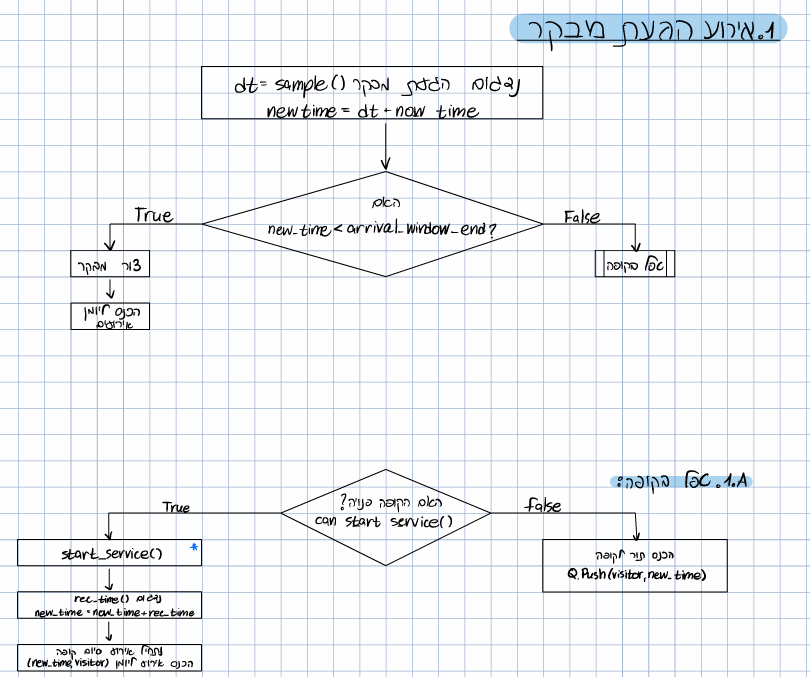

<div dir="rtl" style="text-align: right; color: blue;">


###אירוע סיום מתקן
אירוע סיום מתקן מתרחש כאשר סבב של מתקן מסתיים. בתחילה נבדק האם יש מבקרים שעדיין נמצאים בשירות במתקן אם לא - האירוע מסתיים. עבור כל מבקר שסיים את המתקן מתבצעת עדכון סטטוס: סימון סיום המתקן, בדיקה האם עליו לצאת לאוכל, לעבור למתקן נוסף או לעזוב את הפארק. לאחר הטיפול בכל המבקרים שסיימו, נבדק האם ניתן להפעיל מחדש את המתקן עבור מבקרים מהתור, ואם כן מתוזמן סבב חדש.

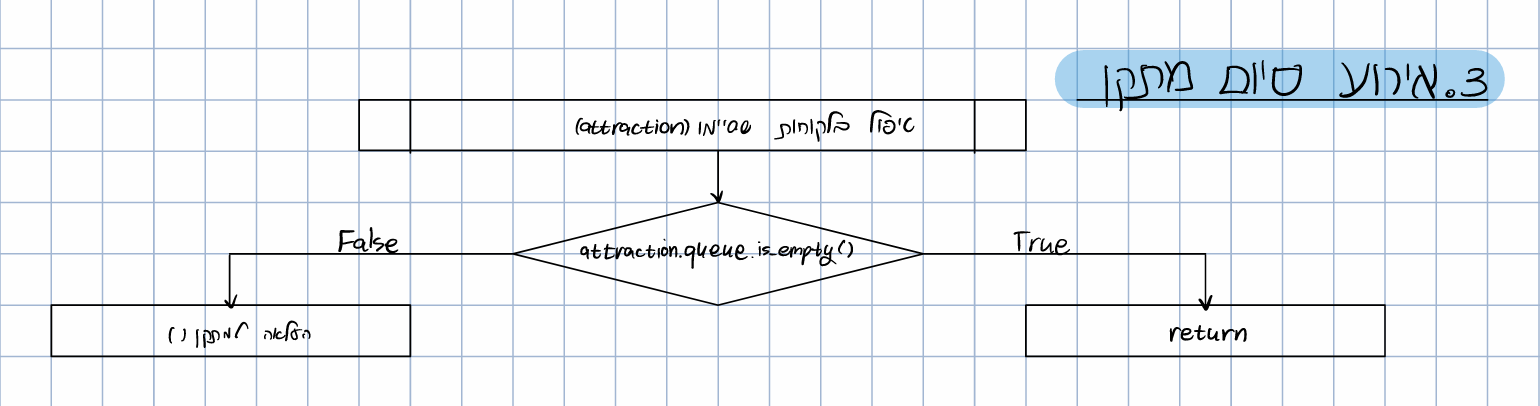

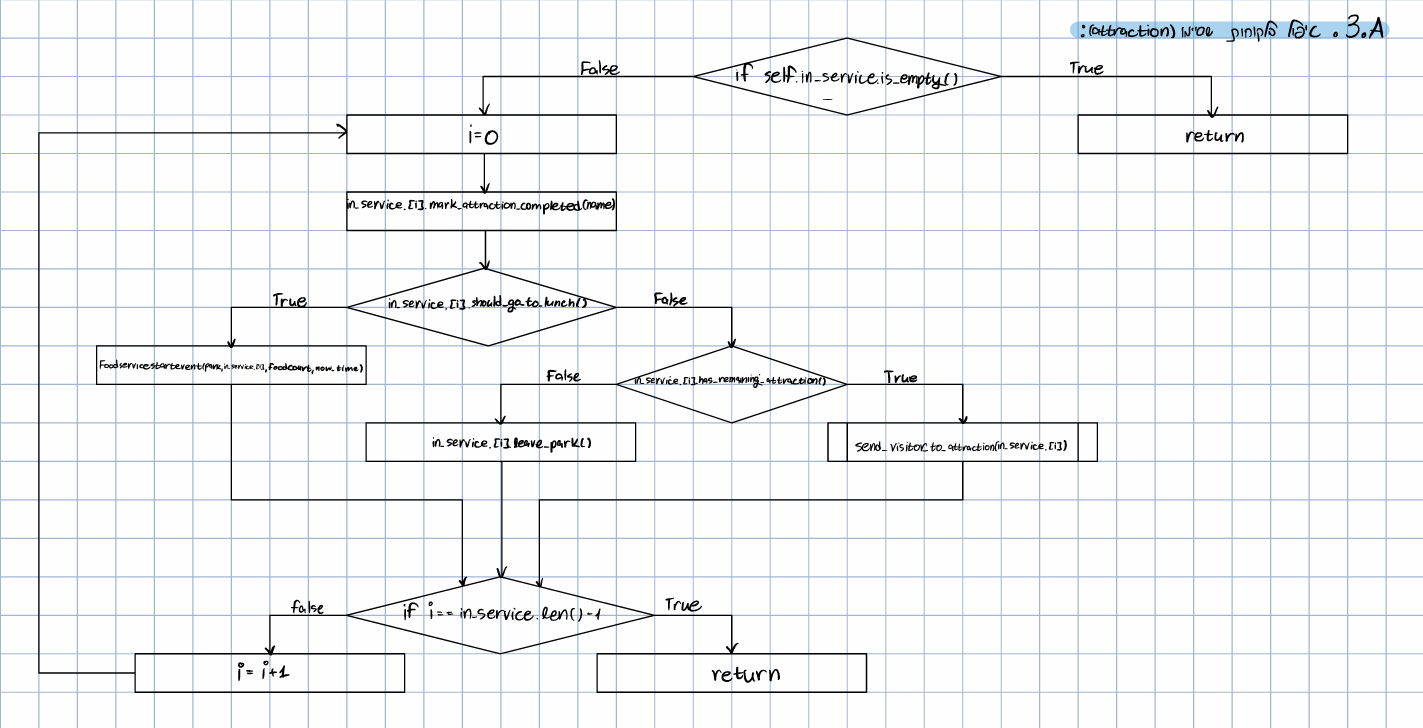

<div dir="rtl" style="text-align: right; color: blue;">

###אירוע סיום קופה
תרשים אירוע סיום קופה מתאר את התהליך שמתרחש כאשר מבקר מסיים שירות בקופת הכניסה. תחילה הקופה מתפנה ומספר המבקרים שנכנסו לפארק מתעדכן. לאחר מכן המבקר נשלח לבחירת מתקן ראשון בפארק. אם יש מבקרים נוספים שממתינים בתור לקופה, נשלף המבקר הבא מהתור, מתחיל עבורו שירות חדש ונקבע אירוע סיום קופה עתידי בהתאם לזמן השירות שנדגם. אם התור ריק, האירוע מסתיים ללא פעולות נוספות.
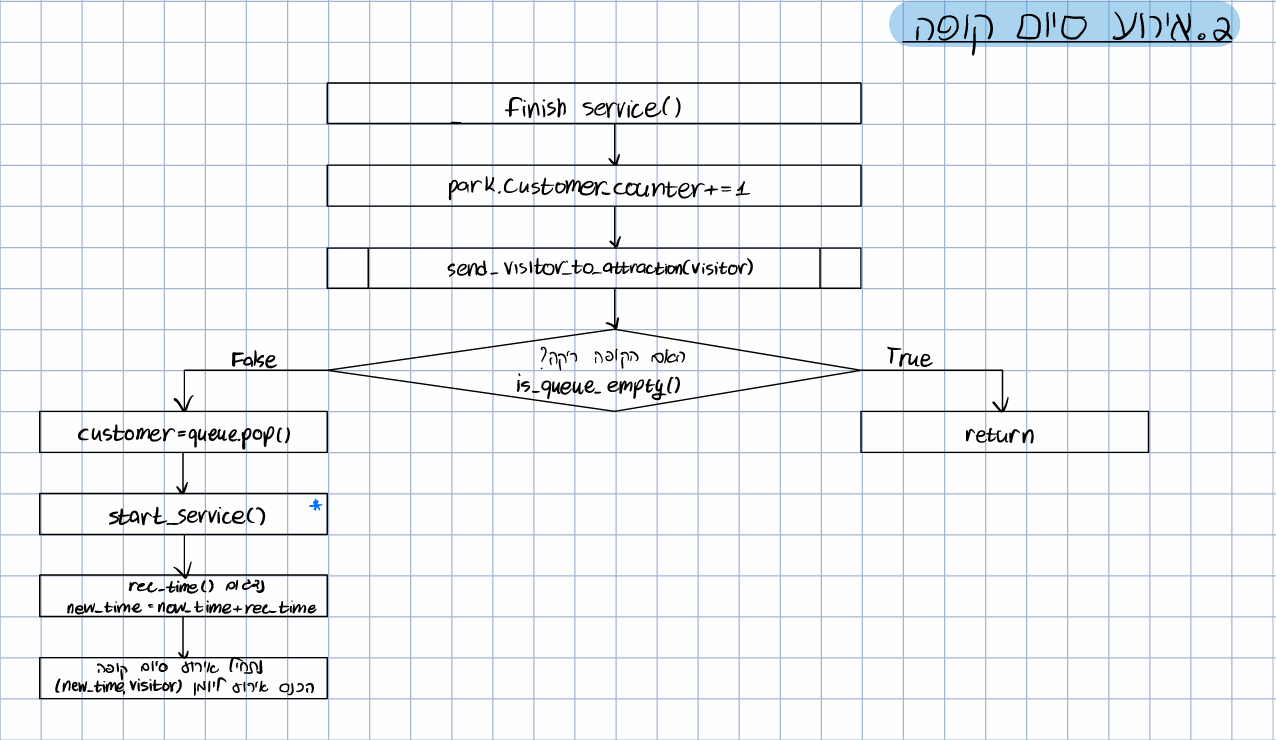

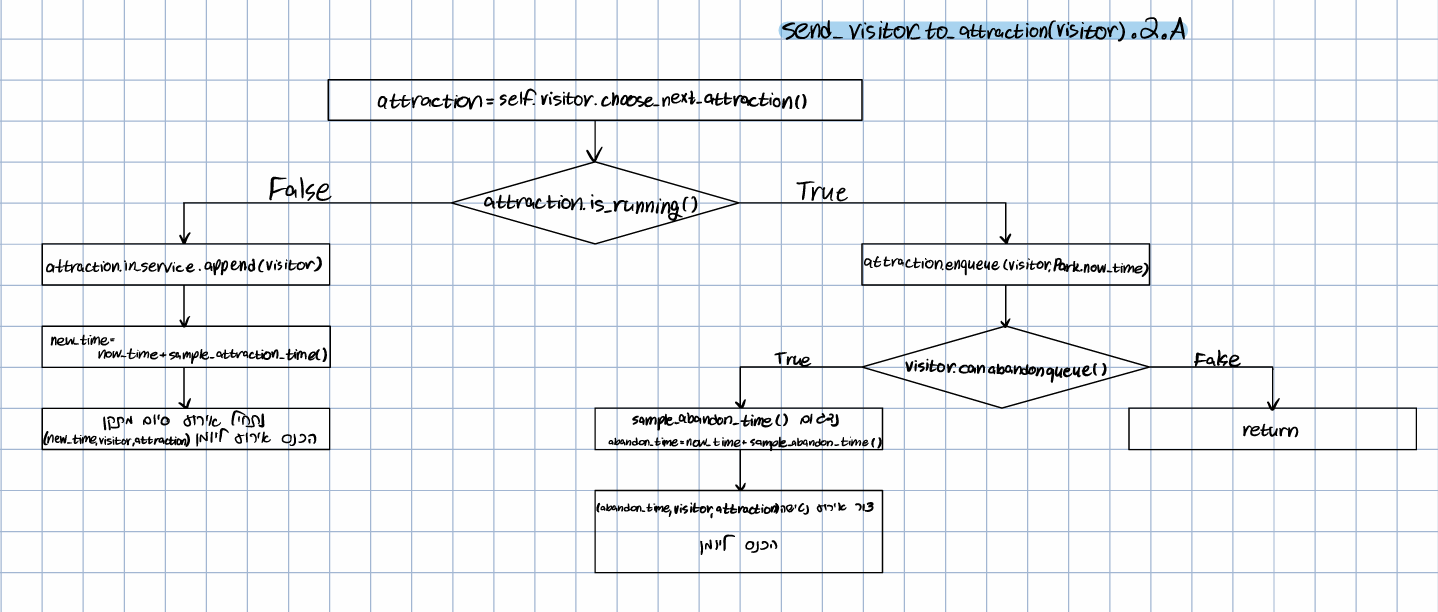

<div dir="rtl" style="text-align: right; color: blue;">

בתרשים בוצעו הפשטות לצורך בהירות: ספירת כניסות מוצגת כיחידה אחת לכל מבקר, אף שבמימוש היא מתבצעת לפי גודל הקבוצה, ומצב פעולת המתקן מיוצג כמשתנה בינארי (is_running), בעוד שבקוד מנוהלים מספר שרתים ומצבי תפעול. הפשטות אלו הן רק לצורך בהירות התרשים ולא מנוהלות שונה לוגית בקוד.

<div dir="rtl" style="text-align: right; color: blue;">

##קוד תומכות אירועים

In [ ]:
# ---------- Event helper functions (pre-Event class) ----------

def can_create_arrival(arrival, end_of_arrival):
    # Simple bounds check to stop generating arrivals after the configured cutoff.
    return arrival <= end_of_arrival


def manage_reception(park, visitor):
    # Core logic for the entrance: either serve immediately or queue up.
    reception = park.reception
    t_now = park.current_time

    if reception.busy < reception.servers:
        # Server available: Start immediately.
        reception.start_service()
        completion_time = t_now + reception.sample_reception_service_time()
        park.schedule_event(TicketPurchaseCompleteEvent(completion_time, visitor))
        return

    # No server available: Join the reception priority queue.
    reception.enqueue(visitor, t_now)


def schedule_family(park, arrival):
    # Factory function: Creates a Family object, registers it, and schedules the arrival event.
    new_family = Family(arrival)
    if hasattr(park, "families"):
        park.families[new_family.family_uid] = new_family
    park.schedule_event(FamilyArrivalEvent(arrival, new_family))


def schedule_single(park, arrival):
    new_single = Single(arrival)
    if hasattr(park, "singles"):
        park.singles[len(park.singles) + 1] = new_single
    park.schedule_event(SingleArrivalEvent(arrival, new_single))


def schedule_teens(park, arrival):
    new_teens = Teens(arrival)
    if hasattr(park, "teens_groups"):
        park.teens_groups[len(park.teens_groups) + 1] = new_teens
    park.schedule_event(TeensArrivalEvent(arrival, new_teens))


def new_ticket_and_band_event(park, visitor):
    # Schedules the completion of the ticket/wristband process.
    completion_time = park.current_time + park.reception.sample_reception_service_time()
    park.schedule_event(TicketPurchaseCompleteEvent(completion_time, visitor))


def initialize_remaining_attractions(park, visitor) -> None:
    # Populates the visitor's "to-do" list based on their persona constraints.
    name_map = {a.name: a for a in park.attractions}

    # Families: Can only go where the youngest child is allowed.
    if isinstance(visitor, Family):
        visitor.remaining_attractions = [
            a for a in park.attractions if visitor.can_enter_attraction(a)
        ]
        visitor.did_all_ages_first = False
        return

    # Teens: Prefer high adrenaline (>3).
    if isinstance(visitor, Teens):
        visitor.remaining_attractions = [
            a for a in park.attractions
            if a.adrenaline >= 3 and visitor.can_enter_attraction(a)
        ]
        return

    # Singles: Use a 2-phase strategy.
    # Phase 1: Slides/WavePool. Phase 2: Everything else (excluding ToddlerPool).
    if isinstance(visitor, Single):
        phase1_names = ["SingleSlides", "SmallTubeSlide", "WavePool"]
        phase1_set = set(phase1_names)
        phase1 = []
        for name in phase1_names:
            attr = name_map.get(name)
            if attr is not None and visitor.can_enter_attraction(attr):
                phase1.append(attr)
        visitor.remaining_attractions = phase1
        visitor.did_phase1 = False
        visitor.phase2_attractions = [
            a for a in park.attractions
            if a.name != "ToddlerPool"
            and a.name not in phase1_set
            and visitor.can_enter_attraction(a)
        ]


def schedule_attraction_completions_after_start(park, attraction, t_now: float) -> None:
    # Complex logic handling ride dispatch, server management, and 'headway' (spacing).
    #
    if getattr(attraction, "closed", False):
        return

    # Special handling for SnorkelTour (requires scheduled breaks and strict timing).
    if attraction.name == "SnorkelTour":
        # Lunch break check (1 PM - 2 PM).
        if ONE_PM <= t_now < TWO_PM:
            return

        # Morning shift logic (before 1 PM).
        if t_now < ONE_PM:
            # 1. Check for headway violations (minimum time between dispatches).
            if attraction.q_length() > 0 and attraction.headway_time > 0.0:
                for server_idx in range(attraction.servers):
                    if attraction.is_running_array[server_idx] or t_now < attraction.next_free_time_array[server_idx]:
                        continue
                    if not attraction.pending_boarded_per_server[server_idx]:
                        continue

                    # Fill server from pending queue.
                    attraction.fill_one_server_from_queue(
                        server_idx,
                        t_now,
                        target_list=attraction.pending_boarded_per_server[server_idx],
                    )
                    duration = attraction.pending_duration_per_server[server_idx]
                    if duration is None:
                        duration = Sampler.sample_attraction_duration("SnorkelTour")
                        # Prevent starting if it runs into the lunch break.
                        if t_now + duration > ONE_PM:
                            continue

                    # Dispatch the ride.
                    finish_time = attraction._start_run_with_boarded(
                        server_idx,
                        t_now,
                        duration,
                        attraction.pending_boarded_per_server[server_idx],
                    )
                    attraction.pending_headway_deadline_per_server[server_idx] = None
                    attraction.pending_duration_per_server[server_idx] = None
                    park.schedule_event(AttractionCompleteEvent(finish_time, server_idx, attraction))

                    # Schedule server release for next run.
                    t_release = attraction.next_free_time_array[server_idx]
                    if t_release > t_now:
                        park.schedule_event(AttractionKickEvent(t_release, attraction))

            # 2. General server filling for SnorkelTour.
            while attraction.can_start(t_now):
                server_idx = attraction.available_server_to_fill(t_now)
                if server_idx == -1:
                    break
                duration = Sampler.sample_attraction_duration("SnorkelTour")

                # Check Global Close time.
                if t_now + duration > CLOSE:
                    attraction.closed = True
                    return
                # Check Lunch break time.
                if t_now + duration > ONE_PM:
                    break

                # Apply Headway logic.
                if attraction.headway_time > 0.0:
                    allocated = attraction.fill_one_server_from_queue(
                        server_idx,
                        t_now,
                        target_list=attraction.pending_boarded_per_server[server_idx],
                    )
                    if allocated <= 0:
                        break

                    # If partially full, wait for headway to expire or more people.
                    if allocated < attraction.capacity_per_server and attraction.q_length() == 0:
                        latest_finish = t_now + attraction.headway_time + duration
                        if latest_finish <= ONE_PM:
                            deadline = t_now + attraction.headway_time
                            attraction.pending_headway_deadline_per_server[server_idx] = deadline
                            attraction.pending_duration_per_server[server_idx] = duration
                            park.schedule_event(
                                AttractionHeadwayExpireEvent(deadline, server_idx, attraction)
                            )
                            continue

                    finish_time = attraction._start_run_with_boarded(
                        server_idx,
                        t_now,
                        duration,
                        attraction.pending_boarded_per_server[server_idx],
                    )
                    attraction.pending_headway_deadline_per_server[server_idx] = None
                    attraction.pending_duration_per_server[server_idx] = None
                else:
                    # Immediate start if no headway required.
                    allocated = attraction.fill_one_server_from_queue(server_idx, t_now)
                    if allocated <= 0:
                        break
                    finish_time = t_now + duration
                    attraction.is_running_array[server_idx] = True
                    attraction.next_free_time_array[server_idx] = finish_time + attraction.break_time

                park.schedule_event(AttractionCompleteEvent(finish_time, server_idx, attraction))
                t_release = attraction.next_free_time_array[server_idx]
                if t_release > t_now:
                    park.schedule_event(AttractionKickEvent(t_release, attraction))
            return

    # Logic for standard attractions (non-Snorkel).
    started, headway_waiting = attraction.start_servers_if_possible(t_now)
    for (server_idx, finish_time) in started:
        park.schedule_event(AttractionCompleteEvent(finish_time, server_idx, attraction))
    for (server_idx, deadline) in headway_waiting:
        park.schedule_event(AttractionHeadwayExpireEvent(deadline, server_idx, attraction))


def visitor_finished_receiving_ticket(park, visitor):
    # Transition from Reception -> Inside Park.
    park.customers_arriving += visitor.group_size

    visitor.has_express = Sampler.sample_buy_express_at_entrance()

    # Propagate Express status to all group members.
    for m in getattr(visitor, "members", []):
        m.has_express = visitor.has_express

    if not getattr(visitor, "remaining_attractions", []):
        initialize_remaining_attractions(park, visitor)

    # Calculate revenue based on age groups and express status.
    if not getattr(visitor, "reception_paid", False):
        revenue = 0.0
        for m in getattr(visitor, "members", []):
            age = float(getattr(m, "age", 0.0))
            if age >= 14.0:
                revenue += 150.0
            elif age >= 2.0:
                revenue += 75.0
        if visitor.has_express:
            revenue += 50.0 * float(len(getattr(visitor, "members", [])))
        visitor.reception_paid = True
        park.reception_income += revenue
        park.total_income += revenue

    visitor.status = "IN_PARK"
    visitor.current_location = "PARK"


def send_visitor_to_attraction(park, visitor):
    # Main router for moving visitors to the next queue.
    #
    t_now = park.current_time

    # 1. Check if Family needs to exit or reunite.
    if isinstance(visitor, Family) and visitor.status in {"EXITING", "WAITING_MEET"}:
        try_reunite_and_finalize_family_exit(park, visitor, t_now)
        return

    # 2. Check if visitor is done with the park.
    if not visitor.has_remaining_attractions():
        if isinstance(visitor, Family) and getattr(visitor, "need_reunite", False):
            visitor.status = "WAITING_MEET"
            schedule_meeting_check_if_needed(park, visitor, t_now)
            try_reunite_and_finalize_family_exit(park, visitor, t_now)
        elif isinstance(visitor, Family):
            finalize_family_unit_exit(park, visitor, t_now)
        else:
            finalize_group_exit(park, visitor, t_now)
        return

    # 3. Choose and enqueue.
    attraction = visitor.choose_next_attraction(t_now)
    attraction.enqueue(visitor, t_now)

    if visitor.status != "IN_QUEUE":
        return

    # Trigger attraction logic (in case a seat is immediately available).
    schedule_attraction_completions_after_start(park, attraction, t_now)

    visitor.waiting_in_attraction = attraction

    # Penalties for Teens (simulating impatience/detours).
    if isinstance(visitor, Teens) and getattr(visitor, "returning_to_pending", False):
        visitor.returning_to_pending = False
        if not visitor.has_express:
            park.schedule_event(TeenWaitPenaltyEvent(t_now + 20, visitor, attraction))
        return

    # Schedule Abandonment check (Renege) if the queue takes too long.
    if visitor.can_abandon_queue() and visitor.max_wait_time is not None and visitor.max_wait_time > 0:
        park.schedule_event(AbandonmentEvent(t_now + float(visitor.max_wait_time), visitor, attraction))


def check_visitor_attraction_position(visitor, park):
    # High-level state check: Exit? Lunch? Attraction?
    t_now = park.current_time

    if isinstance(visitor, Family) and visitor.status in {"EXITING", "WAITING_MEET"}:
        try_reunite_and_finalize_family_exit(park, visitor, t_now)
        return

    if not visitor.has_remaining_attractions():
        if isinstance(visitor, Family) and getattr(visitor, "need_reunite", False):
            visitor.status = "WAITING_MEET"
            schedule_meeting_check_if_needed(park, visitor, t_now)
            try_reunite_and_finalize_family_exit(park, visitor, t_now)
            return

        if isinstance(visitor, Family):
            finalize_family_unit_exit(park, visitor, t_now)
        else:
            finalize_group_exit(park, visitor, t_now)
        return

    # Priority check: Hungry? Go to lunch. Otherwise, Attraction.
    if maybe_send_visitor_to_lunch(park, visitor):
        return

    send_visitor_to_attraction(park, visitor)


def maybe_send_visitor_to_lunch(park, visitor) -> bool:
    # Decides if the visitor should eat based on time and hunger status.
    t_now = park.current_time

    if visitor.should_go_to_lunch(t_now):
        restaurant_name = visitor.choose_restaurant()
        restaurant_entry = park.food_court.restaurants[restaurant_name]
        restaurant: Restaurant = restaurant_entry["restaurant"]

        # Satisfaction penalty if the lines are so long they would miss closing time.
        expected_done = expected_food_completion_time(park, restaurant, t_now)
        if expected_done > CLOSE:
            visitor.rating = max(0.0, float(visitor.rating) - 0.8)
            return False

        visitor.going_to_lunch = True
        visitor.status = "GOING_TO_LUNCH"

        start_food_process(park, visitor, restaurant_name)
        return True

    return False


def expected_food_completion_time(park, restaurant: Restaurant, t_now: float) -> float:
    # Heuristic calculation for estimated dining completion (Queue + Prep + Eat).
    avg_prep = Sampler.expected_food_prep_time_by_restaurant(restaurant.name)
    avg_counter = Sampler.expected_food_service_time_at_counter()
    avg_service = avg_prep + avg_counter
    avg_eat = Sampler.expected_meal_duration()

    queue_len = len(restaurant.Q)
    servers = max(1, restaurant.servers)
    busy = restaurant.busy
    if restaurant.has_free_server() and queue_len == 0:
        expected_wait = 0.0
    else:
        # Standard M/M/c queue wait time estimation.
        expected_wait = (queue_len + busy) * avg_service / servers

    return t_now + expected_wait + avg_service + avg_eat


def start_food_process(park, visitor, restaurant_name: str) -> None:
    # Handles payment and queuing for food.
    if restaurant_name not in park.food_court.restaurants:
        raise ValueError(f"Unknown restaurant: {restaurant_name}")

    entry = park.food_court.restaurants[restaurant_name]
    restaurant: Restaurant = entry["restaurant"]

    expected_done = expected_food_completion_time(park, restaurant, park.current_time)
    if expected_done > CLOSE:
        visitor.going_to_lunch = False
        visitor.status = "IN_PARK"
        check_visitor_attraction_position(visitor, park)
        return

    # Process Payment.
    price = park.food_court.get_price(restaurant_name, visitor)
    park.food_court.add_income(price)
    park.total_income += float(price)
    park.total_people_ate += int(getattr(visitor, "group_size", 1))

    # Queue or Serve logic.
    if restaurant.has_free_server():
        restaurant.start_service()
        prep_time = Sampler.sample_food_prep_time_by_restaurant(restaurant.name)
        counter_time = Sampler.sample_food_service_time_at_counter()
        completion_time = park.current_time + prep_time + counter_time
        park.schedule_event(FinishFoodServiceEvent(completion_time, visitor, restaurant))
    else:
        restaurant.enqueue(visitor, park.current_time, is_express=False)


def new_finished_eating_event(park, visitor, restaurant):
    # Schedules the end of the eating duration (table occupancy).
    eating_time = Sampler.sample_meal_duration()
    completion_time = park.current_time + eating_time
    park.schedule_event(FinishedEatingEvent(completion_time, visitor, restaurant))


def new_finish_service_event(park, restaurant):
    # Food service completed for one customer; pull next from queue if available.
    if len(restaurant.Q) == 0:
        return
    _, _, _, customer = restaurant.Q.pop()
    restaurant.start_service()
    prep_time = Sampler.sample_food_prep_time_by_restaurant(restaurant.name)
    counter_time = Sampler.sample_food_service_time_at_counter()
    duration = prep_time + counter_time
    completion_time = park.current_time + duration
    park.schedule_event(FinishFoodServiceEvent(completion_time, customer, restaurant))

<div dir="rtl" style="text-align: right; color: blue;">

##קוד אירועים
תא זה מכיל את מחלקות האירועים של הסימולציה, המייצגות את כל השינויים הדינמיים שמתרחשים בפארק לאורך ציר הזמן. כל אירוע מוגדר כאובייקט עם זמן ביצוע ומתודת handle, האחראית לעדכון מצב הפארק ולתזמון אירועים עתידיים. באמצעות מנגנון זה מתקדמת הסימולציה מאירוע לאירוע ולא בצעדים קבועים של זמן.

In [ ]:
class Event:
    """
    Base class for all simulation events.
    Events are comparable so the PriorityQueue knows how to sort them by time.
    """
    def __init__(self, time: float, visitor: Optional[Visitor]) -> None:
        self.time: float = float(time)
        self.visitor: Optional[Visitor] = visitor

    def __lt__(self, other: "Event") -> bool:
        # Crucial for the Min-Heap: events with earlier times are processed first.
        return self.time < other.time

    def handle(self, park) -> None:
        """
        Executes the logic associated with this specific event.
        """
        raise NotImplementedError


class FamilyArrivalEvent(Event):
    def handle(self, park) -> None:
        # 1. Schedule the NEXT family arrival immediately.
        # This creates the continuous stream of arrivals.
        t_now = park.current_time
        next_time = Sampler.next_family_arrival_time(t_now)
        if next_time is not None and can_create_arrival(next_time, NOON):
            schedule_family(park, next_time)

        # 2. Process the CURRENT visitor (the one inside this event).
        # Sends them to the reception logic (enter queue or start service).
        manage_reception(park, self.visitor)


class TeensArrivalEvent(Event):
    def handle(self, park) -> None:
        # Same logic as FamilyArrival: Schedule next teen group, then process current group.
        t_now = park.current_time
        next_time = Sampler.next_teens_arrival_time(t_now)
        if next_time is not None and can_create_arrival(next_time, FOUR_PM):
            schedule_teens(park, next_time)
        manage_reception(park, self.visitor)


class SingleArrivalEvent(Event):
    def handle(self, park) -> None:
        # Same logic as others: Schedule next single visitor, then process current.
        t_now = park.current_time
        next_time = Sampler.next_single_arrival_time(t_now)
        if next_time is not None and can_create_arrival(next_time, CLOSE - 30):
            schedule_single(park, next_time)
        manage_reception(park, self.visitor)


class TicketPurchaseCompleteEvent(Event):
    def handle(self, park) -> None:
        """
        Starts when a visitor finishes buying tickets/getting wristbands.
        """
        t_now = park.current_time
        visitor = self.visitor

        # 1. Free up the reception server (decrement busy counter).
        park.reception.finish_service()

        # 2. Logic to officially move the visitor "Inside" the park.
        visitor_finished_receiving_ticket(park, visitor)

        # 3. Router: Decide where the visitor goes first (Attraction? Lunch?).
        send_visitor_to_attraction(park, visitor)

        # 4. Chain Reaction: If there are people waiting in the reception queue,
        # start serving the next person immediately.
        if not park.reception.is_queue_empty():
            _, _, _, next_visitor = park.reception.Q.pop()
            park.reception.start_service()
            # Schedule when this NEXT person will finish.
            completion_time = t_now + park.reception.sample_reception_service_time()
            park.schedule_event(TicketPurchaseCompleteEvent(completion_time, next_visitor))
        else:
            # Server goes idle.
            return


class AttractionHeadwayExpireEvent(Event):
    """
    Specific to rides that require a minimum gap (headway) between dispatches.
    Starts when the 'safety timer' expires.
    """
    def __init__(self, time: float, server_idx: int, attraction: Attraction) -> None:
        super().__init__(time, None)
        self.server_idx: int = int(server_idx)
        self.attraction: Attraction = attraction

    def handle(self, park) -> None:
        t_now = park.current_time
        attraction = self.attraction
        server_idx = self.server_idx

        # If the ride started via another trigger while we were waiting, ignore this event.
        if attraction.is_running_array[server_idx]:
            return

        # Double check if the deadline is still valid.
        deadline = attraction.pending_headway_deadline_per_server[server_idx]
        if deadline is None or t_now < float(deadline):
            return

        # If no one is boarded (they abandoned queue?), reset and abort.
        boarded = attraction.pending_boarded_per_server[server_idx]
        if not boarded:
            attraction.pending_headway_deadline_per_server[server_idx] = None
            attraction.pending_duration_per_server[server_idx] = None
            return

        # 1. Retrieve the duration that was calculated when they boarded.
        duration = attraction.pending_duration_per_server[server_idx]
        if duration is None:
            # Fallback if state was lost: Resample duration.
            duration, finish_time = attraction.sample_duration_and_finish(t_now)
            if finish_time > CLOSE:
                attraction.closed = True
                attraction.pending_headway_deadline_per_server[server_idx] = None
                attraction.pending_duration_per_server[server_idx] = None
                boarded.clear()
                return

        # 2. Actually launch the ride now that headway is satisfied.
        finish_time = attraction._start_run_with_boarded(server_idx, t_now, duration, boarded)

        # Clear pending flags.
        attraction.pending_headway_deadline_per_server[server_idx] = None
        attraction.pending_duration_per_server[server_idx] = None

        # 3. Schedule the completion of the ride.
        park.schedule_event(AttractionCompleteEvent(finish_time, server_idx, attraction))

        # 4. Schedule a 'Kick' event to wake up the server when the ride is free again.
        t_release = attraction.next_free_time_array[server_idx]
        if t_release > t_now:
            park.schedule_event(AttractionKickEvent(t_release, attraction))


class AttractionCompleteEvent(Event):
    def __init__(self, time: float, server_idx: int, attraction: Attraction) -> None:
        super().__init__(time, None)
        self.server_idx: int = int(server_idx)
        self.attraction: Attraction = attraction

    def handle(self, park) -> None:
        """
        Fires when a ride finishes its cycle.
        """
        t_now = park.current_time
        attraction = self.attraction
        server_idx = self.server_idx

        # 1. Unload passengers and free the server (set is_running to False).
        serviced = attraction.complete_server(server_idx)

        # 2. Schedule a 'Kick' event for after the break/cleaning time,
        # to ensure the server becomes available for the next group.
        t_release = attraction.next_free_time_array[server_idx]
        if t_release > t_now:
            park.schedule_event(AttractionKickEvent(t_release, attraction))

        # 3. Update logic for the visitors who just finished.
        parents_done: set[Visitor] = set()
        for _, parent in serviced:
            # Only process the parent visitor once all split-subgroups are done.
            if parent.group_in_attraction == 0 and parent.group_in_queue == 0:
                parents_done.add(parent)

        for parent in parents_done:
            parent.apply_post_attraction_rating(attraction) # Update satisfaction.
            parent.mark_attraction_completed(attraction)    # Remove from todo list.
            check_visitor_attraction_position(parent, park) # Send to next location.

        # 4. Try to immediately fill this server again if there's a queue.
        schedule_attraction_completions_after_start(park, attraction, t_now)


class AttractionKickEvent(Event):
    def __init__(self, time: float, attraction: Attraction) -> None:
        super().__init__(time, None)
        self.attraction: Attraction = attraction

    def handle(self, park) -> None:
        # A 'Kick' simply triggers the attraction logic to check queue status.
        # Useful when a server finishes its 'break time' and needs to look for customers.
        schedule_attraction_completions_after_start(park, self.attraction, park.current_time)


class AbandonmentEvent(Event):
    """
    Represents a visitor getting tired of waiting (Reneging).
    """
    def __init__(self, time: float, visitor: "Visitor", attraction: "Attraction") -> None:
        super().__init__(time, visitor)
        self.attraction: Attraction = attraction

    def handle(self, park) -> None:
        visitor = self.visitor
        attraction = self.attraction
        t_now = park.current_time

        if visitor is None:
            return

        # Validation: Only abandon if still in queue and not already boarded.
        if getattr(visitor, "status", None) != "IN_QUEUE":
            return
        if getattr(visitor, "waiting_in_attraction", None) is not attraction:
            return
        # Express pass holders don't abandon.
        if getattr(visitor, "has_express", False):
            return
        if getattr(visitor, "group_in_attraction", 0) > 0:
            return
        if getattr(visitor, "group_in_queue", 0) <= 0:
            return

        # 1. Try to remove them from the PriorityQueue.
        removed = attraction.remove_from_queue(visitor)
        if not removed:
            return # They might have boarded just as this event fired.

        # 2. Reset visitor state and apply satisfaction penalty.
        visitor.group_in_queue = 0
        visitor._member_cursor = 0
        visitor.waiting_in_attraction = None
        visitor.rating = max(0.0, float(visitor.rating) - 0.8)

        # 3. Since the queue changed, trigger attraction logic (might unblock logic).
        schedule_attraction_completions_after_start(park, attraction, t_now)

        # 4. TEEN Logic: Teens might buy Express passes instead of leaving.
        if isinstance(visitor, Teens):
            action = visitor.post_abandon_action()
            if action == BUY_EXPRESS_AND_JOIN_EXPRESS_QUEUE:
                # Upgrade to express and re-enter the SAME queue immediately.
                visitor.has_express = True
                for m in getattr(visitor, "members", []):
                    m.has_express = True

                visitor.pending_return_attraction = None
                visitor.detour_done = False
                visitor.returning_to_pending = False

                visitor.status = "IN_PARK"
                attraction.enqueue(visitor, t_now)
                schedule_attraction_completions_after_start(park, attraction, t_now)
                return

            # Otherwise, detour to a different attraction.
            visitor.pending_return_attraction = attraction
            visitor.detour_done = False
            visitor.status = "IN_PARK"
            send_visitor_to_attraction(park, visitor)
            return

        # 5. Non-Teens look for a different attraction.
        visitor.status = "IN_PARK"
        send_visitor_to_attraction(park, visitor)


class TeenWaitPenaltyEvent(Event):
    def __init__(self, time: float, visitor: "Visitor", attraction: Attraction) -> None:
        super().__init__(time, visitor)
        self.attraction: Attraction = attraction

    def handle(self, park) -> None:
        # Periodic event: Every 20 minutes in queue, decrease rating.
        visitor = self.visitor
        attraction = self.attraction
        t_now = park.current_time

        if visitor is None:
            return
        # Stop penalizing if they are no longer in queue.
        if getattr(visitor, "status", None) != "IN_QUEUE":
            return
        if getattr(visitor, "has_express", False):
            return
        if getattr(visitor, "waiting_in_attraction", None) is not attraction:
            return
        if getattr(visitor, "group_in_attraction", 0) > 0:
            return
        if getattr(visitor, "group_in_queue", 0) <= 0:
            return

        # Decrease rating and schedule the NEXT penalty check in 20 mins.
        visitor.rating = max(0.0, float(visitor.rating) - 0.8)
        park.schedule_event(TeenWaitPenaltyEvent(t_now + 20, visitor, attraction))


class FinishFoodServiceEvent(Event):
    def __init__(self, time: float, visitor: Visitor, restaurant: Restaurant) -> None:
        super().__init__(time, visitor)
        self.restaurant: Restaurant = restaurant

    def handle(self, park) -> None:
        # 1. Free up the restaurant server counter.
        self.restaurant.finish_service()

        # 2. Pull the next hungry customer from the food queue (if any).
        new_finish_service_event(park, self.restaurant)

        # 3. Transition THIS visitor to the "Eating" state (occupying a table).
        new_finished_eating_event(park, self.visitor, self.restaurant)


class FinishedEatingEvent(Event):
    def __init__(self, time: float, visitor: Visitor, restaurant: Restaurant) -> None:
        super().__init__(time, visitor)
        self.restaurant: Restaurant = restaurant

    def handle(self, park) -> None:
        visitor = self.visitor
        t_now = park.current_time

        # 1. Determine if the food was good (random chance).
        result = Sampler.sample_food_satisfaction()
        if result == "UNSATISFIED":
            visitor.rating = max(0.0, float(visitor.rating) - 0.8)

        # 2. Update state: No longer hungry.
        visitor.has_eaten = True
        visitor.going_to_lunch = False

        # 3. Check for exit conditions (Families might need to reunite now).
        if isinstance(visitor, Family) and visitor.status in {"EXITING", "WAITING_MEET"}:
            try_reunite_and_finalize_family_exit(park, visitor, t_now)
            return

        # 4. Return to park logic (Find next attraction).
        visitor.status = "IN_PARK"
        check_visitor_attraction_position(visitor, park)


class MeetingCheckEvent(Event):
    """
    Polling event for Families. Checks if all split subgroups have finished
    their activities and are ready to leave.
    """
    def __init__(self, time: float, visitor: Visitor) -> None:
        super().__init__(time, visitor)

    def handle(self, park) -> None:
        unit = self.visitor
        if unit is None or not isinstance(unit, Family):
            return

        t_now = park.current_time
        root = unit.root_family
        try:
            # Short-circuit if family already left.
            if getattr(root, "exited", False):
                unit.status = "EXITED"
                unit.leave_counted = True
                return

            # Ensure tracking is up to date.
            register_family_unit(park.families, unit, close_time=CLOSE)

            # Global park close check.
            if t_now >= CLOSE:
                finalize_close(park.families, t_now, close_time=CLOSE, park=park)
                return

            # Only process if this unit is specifically waiting or trying to exit.
            if unit.status not in {"WAITING_MEET", "EXITING"}:
                return

            # Check if departure criteria (time or done-with-rides) are met.
            should_exit_now(park.families, unit, t_now, close_time=CLOSE, park=park)

            # Case 1: Departure triggered, but this specific unit is not ready?
            if not root.departure_triggered:
                unit.status = "WAITING_MEET"
                schedule_meeting_check_if_needed(park, unit, t_now)
                return

            # Case 2: Departure triggered, but no reunion needed (simple exit).
            if not root.need_reunite:
                finalize_reunited_family_exit(park, root, t_now)
                return

            # Case 3: Reunion needed. Check if this unit is IDLE (not in queue/ride).
            is_idle = (
                unit.status != "IN_QUEUE"
                and not getattr(unit, "going_to_lunch", False)
                and int(getattr(unit, "group_in_attraction", 0)) == 0
                and int(getattr(unit, "group_in_queue", 0)) == 0
            )
            if is_idle:
                # Mark this specific subgroup as ready at the meeting point.
                subgroup_id = 0 if unit.subgroup_id is None else int(unit.subgroup_id)
                root.ready_to_leave.add(subgroup_id)

            # Barrier Check: Are ALL subgroups ready?
            if root.ready_to_leave == root.subgroup_ids:
                finalize_reunited_family_exit(park, root, t_now)
            else:
                # Not everyone is here yet. Wait and check again later (reschedule).
                unit.status = "WAITING_MEET"
                schedule_meeting_check_if_needed(park, unit, t_now)
        finally:
            # Reset flag to allow scheduling next check.
            root._meeting_check_scheduled = False


class PhotoPurchaseEvent(Event):
    def __init__(self, time: float, visitor: Visitor) -> None:
        super().__init__(time, visitor)

    def handle(self, park) -> None:
        # Final revenue calculation step before removing visitor object.
        visitor = self.visitor
        if visitor is None or getattr(visitor, "photos_processed", False):
            return
        visitor.photos_processed = True

        # Calculate spending based on final satisfaction rating.
        rating = float(visitor.rating)
        if rating < 6.0:
            amount = 0.0
        elif rating < 7.5:
            amount = 20.0
        elif rating < 8.5:
            amount = 100.0
        else:
            amount = 120.0

        if amount > 0:
            park.photo_income += amount
            park.total_income += amount


class ParkCloseEvent(Event):
    def __init__(self, time: float) -> None:
        super().__init__(time, None)

    def handle(self, park) -> None:
        # Force all remaining logic to resolve exit stats.
        t_now = park.current_time
        finalize_close(park.families, t_now, close_time=CLOSE, park=park)

<div dir="rtl" style="text-align: right; color: blue;">

#המחלקה פארק,פונקציות תומכות והרצה




<div dir="rtl" style="text-align: right;">

## הנחות המודל

<div dir="rtl" style="text-align: right;">



במודל הסימולציה הונחו ההנחות הבאות לצורך פישוט המערכת וייצוג יעיל של פעילות הפארק:

- זמן המעבר בין מתקנים שונים נחשב זניח.
- זמן העלייה למתקן והפעלתו נחשבים זניחים ביחס למשך הפעילות עצמה.
- קיים חלון התארגנות של 30 דקות לפני שעת העזיבה המתוכננת על מנת שלא נוציא מבקרים מהפארק באמצע המתקן.
- קבוצות יפוצלו למילוי המושבים הפנויים בכל סיבוב, וימתינו לאיחוד הקבוצה לפני המעבר למתקן הבא.
- השרתים בדוכני האוכל נשארים תפוסים לכל אורך זמן ההכנה והמסירה.
-בשנורקלים, המערכת מונעת יציאה לסיור חדש אם הוא צפוי לגלוש לזמן הפסקת הצהריים ב13:00.
- מתקן נחשב פנוי רק כאשר הוא אינו פעיל ואין בו תור ממתין.
- אין זמן מעבר בין סיום הגשת האוכל לתחילת האכילה.
- לקוחות שצפוי שיסיימו לאכול לאחר שעת הסגירה (19:00) אינם נכנסים לתור המזון ונותנים קנס בדירוג.
- הלקוחות הראשונים מכל סוג (משפחות, בני נוער, ומבקרים בודדים) מגיעים מיד עם פתיחת חלון ההגעה שלהם.
- בכל יום הרצה לוגיקת הפעולה זהה, וכל המתקנים והמסעדות פעילים לאורך כל יום העבודה.
- ערכים שליליים שנדגמים מהתפלגות נורמלית נדחים עד לקבלת ערך חיובי.

---

## מידול הפארק

הקוד מגדיר מחלקה מרכזית בשם **Park**, המייצגת את מערכת פארק המים כולה. מחלקה זו מרכזת את כלל רכיבי הסימולציה: עמדת הכניסה (Reception), מתחם האוכל (FoodCourt), רשימת המתקנים (Attraction), וכן את קבוצות המבקרים - משפחות, בני נוער ומבקרים בודדים.

בעת יצירת אובייקט פארק מאותחלים יומן אירועים מבוסס תור עדיפויות, מתקנים עם קיבולות ופרמטרים ייעודיים, שלוש מסעדות שונות, ומנגנונים לאיסוף מדדים וסטטיסטיקות. בנוסף, קיימת מערכת לתזמון אירועים עתידיים כך שכל אירוע מתבצע בזמן שנקבע לו מראש, כל עוד הוא נמצא בטווח יום העבודה.

הרצת הסימולציה מתבצעת באמצעות לולאת אירועים: תחילה מתבצע איפוס מלא של מצב הפארק, לאחר מכן מתוזמנים אירועי ההגעה הראשונים, והמערכת שולפת ומבצעת אירועים לפי סדר כרונולוגי עד להגעה לשעת הסגירה או לסיום כל האירועים.

---

## בחירת המדדים

בסימולציה נבחרו שלושה מדדי הצלחה המשקפים הן את חוויית המבקר והן את ביצועי הפארק מבחינה תפעולית וכלכלית:

### רווח ממחלקת המזון בממוצע לאדם אוכל
מחלקת המזון מהווה מקור הכנסה משלים ומשמעותי לפארק, מעבר להכנסות הישירות מהכניסה. הרווח הממוצע לאדם אוכל משקף עד כמה הפארק מצליח להפיק ערך כלכלי מהמבקרים שבוחרים להשתמש בשירותי המזון.
מבחינה עסקית, זהו מדד המעיד על האיזון בין זמינות השירות, איכות החוויה והתמחור. תהליך אוכל איטי או לא יעיל עלול לפגוע הן בשביעות הרצון והן בהכנסות בפועל.
מדד זה נבחר כדי לבחון כיצד שינויים תפעוליים ותרחישים שונים משפיעים על ביצועי מחלקת המזון, ללא תלות במספר הכולל של המבקרים בפארק.
שיפור במדד זה מצביע על תפעול יעיל יותר של המסעדות ועל יכולת טובה יותר להמיר ביקור בפארק להכנסה נוספת, מבלי לפגוע בזרימת היום.

### כמות האנשים שנכנסו לפארק ביום
כמות הלקוחות הנכנסים לפארק במהלך יום פעילות משקפת את היקף הביקוש ואת יכולת המערכת לקלוט מבקרים לאורך זמן. זהו מדד בסיסי להבנת נפח הפעילות הכולל של הפארק.
מבחינה עסקית, מדד זה קשור ישירות לפוטנציאל ההכנסות הכולל, שכן גידול במספר המבקרים משפיע לא רק על הכנסות הכניסה אלא גם על צריכת שירותים נלווים כגון מזון, מתקנים ורכישות נוספות.
מדד זה נבחר כדי לבדוק כיצד שינויים תפעוליים ותרחישים שונים משפיעים על זרימת המבקרים והיכולת של הפארק להתמודד עם עומסים לאורך היום.
שיפור במדד זה מאפשר לפארק להגדיל את מחזור הפעילות היומי ולממש טוב יותר את הפוטנציאל הכלכלי שלו.

### דירוג מבקר ממוצע  
הדירוג הממוצע משקף את חוויית הביקור הכוללת של המבקר, תוך שילוב של זמני המתנה, איכות השירות, חוויית המתקנים ושביעות רצון כללית.
מבחינה עסקית, דירוג גבוה של חווית המבקר תורם לשימור לקוחות, להמלצות חיוביות ולחזרה עתידית של מבקרים, ומהווה מרכיב מרכזי במוניטין של הפארק לאורך זמן.
מדד זה נבחר כדי להעריך כיצד החלטות תפעוליות שונות משפיעות לא רק על היעילות הכלכלית, אלא גם על תפיסת השירות וחוויית הלקוח.
שיפור במדד זה מעיד על איזון מוצלח בין עומסים, שירות ורווחיות, ומהווה אינדיקציה ארוכת טווח להצלחת הפארק.


## סיכום בחירת המדדים
ההכנסות הכוללות של הפארק מורכבות משלושה מקורות מרכזיים: מכירת כרטיסי כניסה, רווחים ממחלקת המזון, והכנסות ממכירת תמונות ווידאו. כל אחד מהמדדים שנבחרו בסימולציה משקף באופן ישיר אחד ממקורות הכנסה אלו או את הגורמים המשפיעים עליו. כמות הלקוחות ביום משפיעה ישירות על הכנסות הכניסה, הרווח ממחלקת המזון בממוצע לאדם אוכל מייצג את פוטנציאל ההכנסה מהשירותים הנלווים, והדירוג הממוצע למבקר משפיע על רכישת תמונות ווידאו ביציאה. בחירה זו במדדים נועדה לאפשר ניתוח תפעולי שמחובר ישירות למטרה העסקית המרכזית של הפארק - מקסום רווחיות תוך שמירה על חוויית מבקר חיובית.
</div>


<div dir="rtl" style="text-align: right; color: blue;">

##קוד פונקציות תומכות פארק והמחלקה פארק


</div>

In [ ]:
# ------------------ Park Helpers -------------------- #

def reset_park_for_run(park) -> None:
    """
    Resets all park state variables, counters, and clears lists.
    Prepares the system for a fresh simulation run.
    """
    park.current_time = OPEN
    park.customers_arriving = 0
    park.customers_leaving = 0
    park.total_rating = 0.0
    park.total_income = 0.0
    park.photo_income = 0.0
    park.reception_income = 0.0
    park.total_people_ate = 0

    # Reset sub-components if they exist.
    if hasattr(park, "reception"):
        park.reception.reset()
    if hasattr(park, "food_court"):
        park.food_court.reset()
    if hasattr(park, "attractions"):
        for attraction in park.attractions:
            attraction.reset()

    # Clear visitor tracking dictionaries.
    if hasattr(park, "teens_groups"):
        park.teens_groups.clear()
    if hasattr(park, "singles"):
        park.singles.clear()
    if hasattr(park, "families"):
        park.families.clear()

    # Reset static counter for unique Family IDs.
    Family._FAMILY_UID_COUNTER = 0

    for attraction in park.attractions:
        attraction.reset()

    park.food_court.reset()


def initialize_and_schedule_first_visitors(park) -> None:
    """
    Scheduling the Park Close event and the very first arrival for each visitor type (Family, Teens, Single).
    This kicks off the chain reaction of arrivals.
    """
    t_now = OPEN
    park.current_time = t_now

    # Schedule the hard stop event.
    park.schedule_event(ParkCloseEvent(CLOSE))

    # Schedule first Family.
    family_time = Sampler.next_family_arrival_time(t_now)
    if family_time is not None and can_create_arrival(family_time, NOON):
        schedule_family(park, family_time)

    # Schedule first Teen group.
    teens_time = Sampler.next_teens_arrival_time(t_now)
    if teens_time is not None and can_create_arrival(teens_time, FOUR_PM):
        schedule_teens(park, teens_time)

    # Schedule first Single visitor.
    single_time = Sampler.next_single_arrival_time(t_now)
    if single_time is not None and can_create_arrival(single_time, CLOSE - 30):
        schedule_single(park, single_time)


class Park:
    """
    The main simulation container.
    Holds global state, the event log, and all entity references.
    """
    def __init__(self, reception: Reception, food_court: Optional[FoodCourt], attractions: Optional[List[Attraction]] = None) -> None:
        self.log = [] # The Priority Queue for events.
        self.time_line = [] # History log for debugging/reporting.
        self.reception = reception
        self.food_court = food_court if food_court is not None else FoodCourt(1, 1, 1)
        self.attractions: List[Attraction] = attractions if attractions is not None else []
        self.families: dict[int, Family] = {}
        self.teens_groups: dict[int, Teens] = {}
        self.singles: dict[int, Single] = {}

        # Simulation metrics.
        self.current_time = OPEN
        self.tmax = CLOSE
        self.customers_arriving = 0
        self.customers_leaving = 0
        self.total_rating: float = 0.0
        self.total_income: float = 0.0
        self.photo_income: float = 0.0
        self.reception_income: float = 0.0
        self.total_people_ate: int = 0

        self.reset()

        # Initialize concrete attractions with specific configurations.
        self.lazyRiver = Attraction("LazyRiver", 60, 2, 1)
        self.singleSlides = Attraction("SingleSlides", 2, 1, 5)
        self.largeTubeSlide = Attraction("LargeTubeSlide", 1, 8, 2)
        self.smallTubeSlide = Attraction("SmallTubeSlide", 1, 3, 4)
        self.wavePool = Attraction("WavePool", 1, 80, 3)
        self.toddlerPool = Attraction("ToddlerPool", 1, 30, 1)
        self.snorkelTour = Attraction("SnorkelTour", 2, 30, 3)

        self.attractions.extend([
            self.lazyRiver,
            self.singleSlides,
            self.largeTubeSlide,
            self.smallTubeSlide,
            self.wavePool,
            self.toddlerPool,
            self.snorkelTour,
        ])

    def reset(self) -> None:
        reset_park_for_run(self)
        if hasattr(self, "log"):
            self.log.clear()
        if hasattr(self, "time_line"):
            self.time_line.clear()

    def schedule_event(self, event):
        """
        Push an event into the priority queue (Min-Heap).
        Events beyond tmax (Park Close) are discarded to prevent infinite loops.
        """
        visitor_name = event.visitor.name if getattr(event, "visitor", None) is not None else None
        event_name = type(event).__name__

        if event.time <= self.tmax:
            heapq.heappush(self.log, event)
            self.time_line.append((float(event.time), "SCHEDULE", event_name, visitor_name))
        else:
            self.time_line.append((float(self.current_time), "DROP_TMAX", event_name, visitor_name))
            return

    def has_events(self):
        return len(self.log) > 0

    def run(self, seed: Optional[int] = None):
        """
        Main execution loop of the Event Simulation.
        Pops the earliest event, advances time, and processes the event logic.
        """
        if seed is not None:
            random.seed(seed)

        self.reset()
        initialize_and_schedule_first_visitors(self)

        while self.has_events() and self.current_time < self.tmax:
            event = heapq.heappop(self.log)
            self.current_time = event.time

            visitor_name = event.visitor.name if getattr(event, "visitor", None) is not None else None
            self.time_line.append((float(self.current_time), "EXECUTE", type(event).__name__, visitor_name))

            event.handle(self)

<div dir="rtl" style="text-align: right; color: blue;">

#בחינת חלופות

<div dir="rtl" style="text-align: right; color: blue;">

בהתאם למדדים שנבחרו ולמטרת הסימולציה, בחנו שתי חלופות השקעה מרכזיות, כאשר כל חלופה מייצגת שילוב של מספר שיפורים תפעוליים שנועדו להשפיע על היבטים שונים בפעילות הפארק.

## **חלופה 1: הקמת אתר אינטרנט, שיפור מטבח ושיווק**

עלות כוללת: ₪ 250,000

חלופה זו משלבת שלושה שיפורים משלימים, המטפלים הן בצד התפעולי והן בצד העסקי של הפארק. הקמת אתר אינטרנט מאפשרת רכישת כרטיסים מראש ומקצרת משמעותית את זמן השירות בקבלה, דבר שתורם להפחתת העומס בכניסה ולשיפור זרימת המבקרים.
שיפור צוות המטבח מעלה את איכות חוויית האכילה ומגדיל את אחוז המבקרים הבוחרים לאכול בפארק, ובכך תורם ישירות להגדלת ההכנסות ממחלקת המזון. במקביל, פעילות השיווק מגדילה את קצב הגעת המבקרים הבודדים, ומרחיבה את בסיס הלקוחות של הפארק לאורך היום.
שילוב זה יוצר חלופה רחבה שמטפלת הן בהכנסות הישירות והן בחוויית המבקר הכוללת, אך גם מגביר את העומסים הפנימיים במערכת כתוצאה מגידול במספר המבקרים.

## **חלופה 2: הקמת אתר אינטרנט והגדלת אבובים לעשרה**
עלות כוללת: ₪ 250,000

חלופה זו מתמקדת בשיפור תשתיות הליבה של הפארק, בדגש על הפחתת צווארי בקבוק קיימים. הקמת אתר אינטרנט מקצרת את זמן השירות בקבלה ומאפשרת כניסה יעילה ומהירה יותר לפארק, בדומה לחלופה הראשונה.

בנוסף, שמנו לב שהתוחלת של זמן הגלישה במגלשת האבובים הגדולה הוא 4.8 דקות - דבר שיכול ליצור צוואר בקבוק בכך שהתור ארוך עקב היכולת לקבל רק 8 מבקרים בכל גלישה. לכן, הגדלת מספר המקומות במגלשת האבובים הגדולה מאפשרת העלאת מספר גדול יותר של מבקרים בכל סיבוב, ובכך יכולה להקטין את זמני ההמתנה לאחד המתקנים העמוסים בפארק.
חלופה זו אינה מגדילה באופן ישיר את הביקוש או את ההכנסות ממחלקת המזון, אך היא משפרת את היכולת של הפארק להתמודד עם עומסים קיימים ולמצות טוב יותר את פוטנציאל המבקרים שכבר נכנסו למערכת.



<div dir="rtl" style="text-align: right; color: blue;">

#הרצה
תא זה הוא נקודת ההרצה של הפרויקט. כאן מוגדרת פונקציית דוגמה שמאתחלת את רכיבי הפארק ומריצה סימולציה אחת, ובסוף מודפסת תוצאות ההדפסה.

הסימולציה מורצת עשרים פעמים, כאשר בכל הרצה נבחנים שלושה תרחישים: המצב הקיים ללא שינויים, חלופה 1 וחלופה 2. בכל הרצה מופעל פארק זהה מבחינת תנאי ההתחלה וההתנהגות הסטוכסטית, כאשר ההבדל היחיד בין התרחישים הוא השינויים התפעוליים שמגדירים כל חלופה.
לצורך יצירת השוואה הוגנת בין התרחישים, בכל הרצה נקבע seed זהה לחילול המספרים האקראיים עבור שלושת התרחישים. באופן זה מובטח שכל הרצה משתמשת באותם מימושים אקראיים של זמני הגעה, שירות והתנהגות מבקרים, וההבדלים בתוצאות נובעים אך ורק מהחלופות הנבחנות.
במהלך כל הרצה מחושבים ערכי הממוצע של המדדים שנבחרו - רווח ממחלקת המזון בממוצע לאדם אוכל, כמות הלקוחות ביום והדירוג הממוצע למבקר - והם נשמרים ברשימות נפרדות עבור כל תרחיש.

לאחר השלמת כלל ההרצות, נבנות רשימות הפרשים בין המצב הקיים לבין כל אחת מהחלופות, כך שכל איבר מייצג את ההבדל בין תוצאות של אותה הרצה תחת שני תרחישים שונים.
מבנה זה יוצר זוגות תצפיות תואמות, ולכן מאפשר שימוש במבחן t-מזווג, אשר מספק ניתוח סטטיסטי מדויק יותר ומפחית את השונות הנובעת מהאקראיות, לצורך בחינת השיפור שמציעות החלופות ביחס למצב הקיים.
</div>

<div dir="rtl" style="text-align: right; color: blue;">

##תומכות הרצה ומבחנים סטטיסטיים


</div>

<div dir="rtl" style="text-align: right; color: blue;">


על מנת להשתמש במבחן T מזווג יצרנו את התנאים הבאים בקוד:

1. מספר ההרצות לכל חלופה זהה.
2. יש מתאם בין ריצות מקבילות בשתי הסדרות - הן משתמשות באותו SEED.
3. אין מתאם בין ריצות בכל חלופה בפני עצמה - ה SEED משתנה בין ריצות.

והנחנו את ההנחות הבאות:

1. קיים שיוויון שונויות בין הסדרות.
2. המדדים מתפלגים נורמאלית (מדדים המייצגים ממוצעים או סכומים ולכן אפשרי).

  הגדרתו:

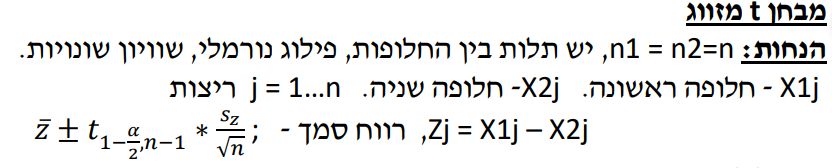

חישוב מספר ההרצות הנדרש מתבצע על פי נוסחאות סטטיסטיות, תוך שימוש באי דיוק יחסי של 10% ו־רמת ביטחון של 90% (α=10%), כאשר ערך
n נקבע ומעודכן במהלך ההרצה עצמה בהתאם לנתונים שנאספים.

לפי אי - שיוויון בנפורני, עבור כל הרצה בה אנו מייצרים שלושה רווחי סמך לשלושה וקטורי הפרש (עבור כל מדד), נחלק את אלפא (0.1) בשלוש כמספר המדדים.

In [ ]:
# ----------------------------------------------------------- #
# --------------- MULTI-RUN COMPARISON --------------------- #
# ----------------------------------------------------------- #

def get_metrics(park) -> dict:
    # Extracts KPIs from a finished simulation run.
    # Handles division by zero edge cases for averages.
    avg_rating = (park.total_rating / float(park.customers_leaving)) if park.customers_leaving > 0 else 0.0
    total_customers = park.customers_leaving
    total_income_food_court = float(park.food_court.income)
    ate = int(getattr(park, "total_people_ate", 0))
    avg_food_income = total_income_food_court / ate if ate > 0 else 0.0
    return {
        "avg_rating": avg_rating,
        "total_customers": total_customers,
        "avg_food_income": avg_food_income,
    }


def compute_basic_stats(xs: list[float]) -> dict:
    n = len(xs)
    mean = statistics.mean(xs)
    var = statistics.variance(xs)
    return {
        "n": n,
        "mean": mean,
        "var": var,
    }


def compute_half_confidence_interval(xs: list[float], alpha: float) -> float:
    # Standard T-Distribution Confidence Interval calculation.
    # Half-width = t_crit * standard_error.
    stats = compute_basic_stats(xs)
    n = stats["n"]
    var = stats["var"]
    t_crit = t.ppf(1 - alpha / 2.0, n - 1)
    return float(t_crit) * math.sqrt(var / n)


def required_n_relative_accuracy(n0: int, mean: float, half_ci: float, rel_acc: float = 0.1,) -> int:
    # Inverse calculation to find the required number of replications (N)
    # to achieve a specific relative accuracy (gamma).
    eps = 1e-9
    if not math.isfinite(mean) or not math.isfinite(half_ci) or abs(mean) < eps:
        return int(n0)
    n_req = n0 * ((half_ci / (mean * (rel_acc / (1.0 + rel_acc)))) ** 2)
    if not math.isfinite(n_req) or n_req <= 0:
        return int(n0)
    return math.ceil(n_req)


def analyze_metric_relative_accuracy(xs: list[float], alpha: float, n0: int,) -> dict:
    stats = compute_basic_stats(xs)
    half_ci = compute_half_confidence_interval(xs, alpha)
    return {
        "n": stats["n"],
        "mean": stats["mean"],
        "var": stats["var"],
        "half_ci": half_ci,
    }


def required_n_per_scenario(scenario_results: dict, n0: int, rel_acc: float, alpha: float,) -> dict:
    # Iterates over all metrics for a single scenario to find the sample size 'N'
    # that satisfies the accuracy requirement for *that specific metric*.
    metrics = ("avg_food_income", "avg_rating", "total_customers")
    output: dict[str, dict[str, float | int]] = {}
    for key in metrics:
        xs = scenario_results[key]
        stats = analyze_metric_relative_accuracy(xs, alpha, n0)
        req_n = required_n_relative_accuracy(n0, stats["mean"], stats["half_ci"], rel_acc=rel_acc)
        if req_n < int(n0):
            req_n = int(n0)
        output[key] = {
            "mean": float(stats["mean"]),
            "variance": float(stats["var"]),
            "half_ci": float(stats["half_ci"]),
            "required_n": int(req_n),
        }
    return output


def required_n_all_scenarios(all_results: dict, n0: int, rel_acc: float, alpha: float,) -> dict:
    # Aggregates requirements across ALL scenarios and ALL metrics.
    # Returns the maximum N required to satisfy the worst-case scenario.
    per_scenario: dict[str, dict] = {}
    required_values: list[int] = []
    for scn_key in ("BASE", "ALT1", "ALT2"):
        scn_stats = required_n_per_scenario(all_results[scn_key], n0, rel_acc, alpha)
        per_scenario[scn_key] = scn_stats
        for metric, metric_stats in scn_stats.items():
            req_n = int(metric_stats["required_n"])
            required_values.append(req_n)
            # Debug logging for unusually high replication requirements.
            if req_n > 100:
                xs = all_results[scn_key][metric]
                print(
                    f"DEBUG required_n>100: scn={scn_key}, metric={metric}, n0={n0}, "
                    f"mean={metric_stats['mean']}, var={metric_stats['variance']}, "
                    f"half_ci={metric_stats['half_ci']}, rel_acc={rel_acc}, req_n={req_n}"
                )
                print(
                    f"  xs_len={len(xs)}, min={min(xs)}, max={max(xs)}, head={xs[:10]}"
                )

    max_required = max(required_values) if required_values else int(n0)
    if max_required < int(n0):
        max_required = int(n0)

    return {
        "per_scenario": per_scenario,
        "global_required_n": int(math.ceil(max_required)),
    }


def extend_replications_if_needed(all_results: dict, global_required_n: int, n0: int, base_seed: int,) -> dict:
    # Two-Stage Procedure:
    # If the calculated required N is larger than what we've already run (n0),
    # run the missing difference (N - n0) and append results to the lists.
    if int(global_required_n) <= int(n0):
        return all_results

    extra_runs = int(global_required_n) - int(n0)
    for i in range(extra_runs):
        seed = int(base_seed) + int(n0) + i
        for scn_key in ("BASE", "ALT1", "ALT2"):
            r_i = run_single_scenario(scn_key, seed=seed)
            all_results[scn_key]["avg_food_income"].append(float(r_i["avg_food_income"]))
            all_results[scn_key]["avg_rating"].append(float(r_i["avg_rating"]))
            all_results[scn_key]["total_customers"].append(float(r_i["total_customers"]))

    lengths = {
        scn_key: (
            len(all_results[scn_key]["avg_food_income"]),
            len(all_results[scn_key]["avg_rating"]),
            len(all_results[scn_key]["total_customers"]),
        )
        for scn_key in ("BASE", "ALT1", "ALT2")
    }
    if len(set(lengths.values())) != 1:
        raise RuntimeError(f"Metric list lengths out of sync: {lengths}")

    return all_results


def run_relative_accuracy_extension(R0: int, base_seed: int, rel_acc: float, alpha: float,) -> dict:
    # 1. Run initial batch R0.
    # 2. Calculate required N.
    # 3. Extend simulations if needed.
    # 4. Return final consolidated results.
    all_results = run_all_three_scenarios_replications(R0, base_seed)
    required_summary = required_n_all_scenarios(all_results, R0, rel_acc, alpha)
    global_required_n = int(required_summary["global_required_n"])

    all_results = extend_replications_if_needed(
        all_results, global_required_n, R0, base_seed
    )

    required_summary = required_n_all_scenarios(all_results, global_required_n, rel_acc, alpha)

    return {
        "final_results": all_results,
        "initial_n": int(R0),
        "final_n": int(global_required_n),
        "required_n_summary": required_summary,
    }



def paired_confidence_band(xs: list[float], ys: list[float], alpha: float) -> tuple[float, float]:
    # Calculates Confidence Interval for the DIFFERENCE between two paired sets (x - y).
    # Assumes Common Random Numbers (CRN) were used (same seeds for corresponding runs).
    if len(xs) != len(ys):
        raise ValueError("Paired samples must have equal length")
    diffs = [float(x) - float(y) for x, y in zip(xs, ys)]
    stats = compute_basic_stats(diffs)
    half_ci = compute_half_confidence_interval(diffs, alpha)
    mean = float(stats["mean"])
    return mean - half_ci, mean + half_ci


def paired_ci_per_metric(all_results: dict, metric: str, alpha: float) -> dict:
    # Computes pairwise comparisons for all scenario combinations (Base-Alt1, Base-Alt2, Alt1-Alt2).
    base = all_results["BASE"][metric]
    alt1 = all_results["ALT1"][metric]
    alt2 = all_results["ALT2"][metric]

    base_alt1 = paired_confidence_band(base, alt1, alpha)
    base_alt2 = paired_confidence_band(base, alt2, alpha)
    alt1_alt2 = paired_confidence_band(alt1, alt2, alpha)

    return {
        "BASE_minus_ALT1": base_alt1,
        "BASE_minus_ALT2": base_alt2,
        "ALT1_minus_ALT2": alt1_alt2,
    }


def ci_relation(ci: tuple[float, float]) -> str:
    # Helper to check if a Confidence Interval includes zero.
    # If it crosses zero, the difference is not statistically significant.
    if ci[1] < 0:
        return "NEGATIVE" # Mean difference is strictly negative.
    if ci[0] > 0:
        return "POSITIVE" # Mean difference is strictly positive.
    return "CROSSES_ZERO" # Inconclusive / No significant difference.


def metric_winner_from_cis(metric: str, cis: dict) -> dict:
    # Analyzes the pairwise CIs to determine a strict ordering/winner.
    # "Winner" is determined by whichever scenario is statistically better than ALL others.
    base_alt1 = cis["BASE_minus_ALT1"]
    base_alt2 = cis["BASE_minus_ALT2"]
    alt1_alt2 = cis["ALT1_minus_ALT2"]

    if metric in ("avg_food_income", "avg_rating", "total_customers"):
        # For these metrics, Higher is Better.
        rel_base_alt1 = ci_relation(base_alt1)
        rel_base_alt2 = ci_relation(base_alt2)
        rel_alt1_alt2 = ci_relation(alt1_alt2)

        if rel_base_alt1 == "NEGATIVE":
            outcome_base_alt1 = "ALT1" # Alt1 > Base
        elif rel_base_alt1 == "POSITIVE":
            outcome_base_alt1 = "BASE" # Base > Alt1
        else:
            outcome_base_alt1 = "INCONCLUSIVE"

        if rel_base_alt2 == "NEGATIVE":
            outcome_base_alt2 = "ALT2"
        elif rel_base_alt2 == "POSITIVE":
            outcome_base_alt2 = "BASE"
        else:
            outcome_base_alt2 = "INCONCLUSIVE"

        if rel_alt1_alt2 == "NEGATIVE":
            outcome_alt1_alt2 = "ALT2"
        elif rel_alt1_alt2 == "POSITIVE":
            outcome_alt1_alt2 = "ALT1"
        else:
            outcome_alt1_alt2 = "INCONCLUSIVE"

    else:
        raise ValueError(f"Unknown metric: {metric}")

    # Aggregating pairwise wins to find global winner.
    if outcome_base_alt1 == "ALT1" and outcome_alt1_alt2 == "ALT1":
        winner = "ALT1"
    elif outcome_base_alt2 == "ALT2" and outcome_alt1_alt2 == "ALT2":
        winner = "ALT2"
    elif outcome_base_alt1 == "BASE" and outcome_base_alt2 == "BASE":
        winner = "BASE"
    else:
        winner = "INCONCLUSIVE"

    return {
        "winner": winner,
        "comparisons": {
            "BASE_vs_ALT1": outcome_base_alt1,
            "BASE_vs_ALT2": outcome_base_alt2,
            "ALT1_vs_ALT2": outcome_alt1_alt2,
        },
    }


def paired_t_confidence_bands_part_d(all_results: dict, rel_acc: float) -> dict:
    # Performs the full hypothesis testing suite using Bonferroni correction (alpha/3).
    alpha_pairwise = rel_acc / 3
    metrics = ("avg_food_income", "avg_rating", "total_customers")
    bands = {metric: paired_ci_per_metric(all_results, metric, alpha_pairwise) for metric in metrics}
    winners = {metric: metric_winner_from_cis(metric, bands[metric]) for metric in metrics}
    return {
        "alpha": alpha_pairwise,
        "bands": bands,
        "per_metric_winner": winners,
    }


def print_summary(part_d_result: dict) -> None:
    # Formatting output for the final report.
    global _SIM_ALREADY_RAN
    if _SIM_ALREADY_RAN:
        print("DEBUG: part d called again – skipping")
        return
    _SIM_ALREADY_RAN = True
    print(f"C) Paired confidence bands (alpha = {part_d_result['alpha']})")
    bands = part_d_result["bands"]
    winners = part_d_result["per_metric_winner"]
    for metric in ("avg_food_income", "avg_rating", "total_customers"):
        cis = bands[metric]
        win = winners[metric]
        print(f"  {metric}")
        print(f"    BASE_minus_ALT1: ({cis['BASE_minus_ALT1'][0]:.6f}, {cis['BASE_minus_ALT1'][1]:.6f})")
        print(f"    BASE_minus_ALT2: ({cis['BASE_minus_ALT2'][0]:.6f}, {cis['BASE_minus_ALT2'][1]:.6f})")
        print(f"    ALT1_minus_ALT2: ({cis['ALT1_minus_ALT2'][0]:.6f}, {cis['ALT1_minus_ALT2'][1]:.6f})")
        print(f"    BASE_vs_ALT1: {win['comparisons']['BASE_vs_ALT1']}")
        print(f"    BASE_vs_ALT2: {win['comparisons']['BASE_vs_ALT2']}")
        print(f"    ALT1_vs_ALT2: {win['comparisons']['ALT1_vs_ALT2']}")
        print(f"    Winner: {win['winner']}")


def run_single_scenario(scn_key: str, seed: Optional[int] = None) -> dict:
    # Runs exactly ONE simulation iteration for ONE scenario configuration.
    scn = SCENARIOS[scn_key]
    apply_scenario_to_globals(scn)

    reception = Reception(3)
    food_court = FoodCourt(1, 1, 1)
    park = Park(reception, food_court)

    apply_scenario_to_park_resources(park, scn)

    park.run(seed=seed)

    m = get_metrics(park)
    invest = float(scn["invest_cost"])
    feasible = invest <= float(BUDGET)


    return {
        "name": scn["label"],
        "key": scn_key,
        "feasible": feasible,
        "invest_cost": invest,
        "avg_rating": m["avg_rating"],
        "total_customers": m["total_customers"],
        "avg_food_income": m["avg_food_income"]
    }


def run_scenario_replications(scn_key: str, R: int, base_seed: int) -> dict:
    # Runs 'R' iterations of a specific scenario, incrementing seeds to ensure randomness.
    if int(R) <= 0:
        raise ValueError("R must be positive")

    first = run_single_scenario(scn_key, seed=base_seed)
    avg_food_income_list = [float(first["avg_food_income"])]
    total_customers_list = [float(first["total_customers"])]
    avg_rating_list = [float(first["avg_rating"])]

    for i in range(1, int(R)):
        r_i = run_single_scenario(scn_key, seed=base_seed + i)
        avg_food_income_list.append(float(r_i["avg_food_income"]))
        total_customers_list.append(float(r_i["total_customers"]))
        avg_rating_list.append(float(r_i["avg_rating"]))

    return {
        "name": first["name"],
        "key": scn_key,
        "feasible": first["feasible"],
        "invest_cost": first["invest_cost"],
        "avg_food_income": avg_food_income_list,
        "total_customers": total_customers_list,
        "avg_rating": avg_rating_list,
    }


def run_all_three_scenarios_replications(R: int, base_seed: int) -> dict:
    # Helper to execute the full experimental design (Base + 2 Alternatives).
    return {
        "BASE": run_scenario_replications("BASE", R, base_seed),
        "ALT1": run_scenario_replications("ALT1", R, base_seed),
        "ALT2": run_scenario_replications("ALT2", R, base_seed),
    }

<div dir="rtl" style="text-align: right; color: blue;">

##הרצה ראשית


</div>

In [ ]:
from IPython.display import display, HTML

def _fmt(x, nd=6):
    try:
        return f"{float(x):.{nd}f}"
    except Exception:
        return str(x)

def _ci(ci):
    # Formats a tuple (lower, upper) into a readable string string.
    return f"({_fmt(ci[0])}, {_fmt(ci[1])})"

def _badge(text, kind="info"):
    # Generates a styled  visual status indicators.
    colors = {
        "good": ("#065f46", "#d1fae5"),
        "bad":  ("#991b1b", "#fee2e2"),
        "warn": ("#92400e", "#ffedd5"),
        "info": ("#1e40af", "#dbeafe"),
        "neutral": ("#111827", "#e5e7eb"),
    }
    fg, bg = colors.get(kind, colors["info"])
    return f"""<span style="display:inline-block;padding:2px 8px;border-radius:999px;
                font-size:12px;font-weight:700;color:{fg};background:{bg};">{text}</span>"""

def display_simulation_summary(out, part_d_result):
    """
    Renders a rich HTML dashboard in the notebook to summarize the entire simulation experiment.
    Displays:
    1. Replication counts (Initial vs Final required).
    2. Detailed statistics per scenario (Mean, Var, CI).
    3. Hypothesis testing results (Paired Confidence Intervals and Winners).
    """
    final_results = out["final_results"]
    required_n_summary = out["required_n_summary"]
    initial_n = out["initial_n"]
    final_n = out["final_n"]

    # ---- Header: Sample Size Info ----
    html = f"""
    <div style="font-family:ui-sans-serif,system-ui,-apple-system,Segoe UI,Roboto; line-height:1.35;">
      <div style="padding:16px;border-radius:16px;background:#0f172a;color:#e2e8f0;">
        <div style="font-size:26px;font-weight:900;letter-spacing:0.3px;">FINAL SUMMARY</div>
        <div style="margin-top:10px;font-size:16px;">
          {_badge("A) Number of runs","info")}
          <span style="margin-left:10px;">Initial (R0): <b>{initial_n}</b></span>
          <span style="margin-left:14px;">Final used: <b>{final_n}</b></span>
        </div>
      </div>
    """

    # ---- Per-scenario stats table ----
    # Iterates through the calculated requirements to display Mean, Variance, and the Half-CI width.
    html += """
      <div style="margin-top:14px;padding:14px;border-radius:16px;background:#ffffff;border:1px solid #e5e7eb;">
        <div style="font-size:18px;font-weight:900;margin-bottom:10px;">B) Per scenario statistics</div>
        <div style="overflow:auto;">
        <table style="border-collapse:collapse;min-width:900px;width:100%;font-size:15px;">
          <thead>
            <tr style="background:#f8fafc;">
              <th style="text-align:left;padding:10px;border-bottom:1px solid #e5e7eb;">Scenario</th>
              <th style="text-align:left;padding:10px;border-bottom:1px solid #e5e7eb;">Metric</th>
              <th style="text-align:right;padding:10px;border-bottom:1px solid #e5e7eb;">Mean</th>
              <th style="text-align:right;padding:10px;border-bottom:1px solid #e5e7eb;">Variance</th>
              <th style="text-align:right;padding:10px;border-bottom:1px solid #e5e7eb;">Half CI</th>
              <th style="text-align:right;padding:10px;border-bottom:1px solid #e5e7eb;">Required n</th>
            </tr>
          </thead>
          <tbody>
    """

    for scn_key in ("BASE", "ALT1", "ALT2"):
        scn_stats = required_n_summary["per_scenario"][scn_key]
        for metric in ("avg_food_income", "avg_rating", "total_customers"):
            m = scn_stats[metric]
            html += f"""
            <tr>
              <td style="padding:10px;border-bottom:1px solid #f1f5f9;"><b>{scn_key}</b></td>
              <td style="padding:10px;border-bottom:1px solid #f1f5f9;">{metric}</td>
              <td style="padding:10px;border-bottom:1px solid #f1f5f9;text-align:right;font-family:ui-monospace,Menlo,Consolas;">{_fmt(m['mean'])}</td>
              <td style="padding:10px;border-bottom:1px solid #f1f5f9;text-align:right;font-family:ui-monospace,Menlo,Consolas;">{_fmt(m['variance'])}</td>
              <td style="padding:10px;border-bottom:1px solid #f1f5f9;text-align:right;font-family:ui-monospace,Menlo,Consolas;">{_fmt(m['half_ci'])}</td>
              <td style="padding:10px;border-bottom:1px solid #f1f5f9;text-align:right;"><b>{int(m['required_n'])}</b></td>
            </tr>
            """

    html += """
          </tbody>
        </table>
        </div>
      </div>
    """

    # ---- Paired confidence bands ----
    alpha = part_d_result.get("alpha", None)
    alpha_txt = _fmt(alpha) if alpha is not None else "?"
    html += f"""
      <div style="margin-top:14px;padding:14px;border-radius:16px;background:#ffffff;border:1px solid #e5e7eb;">
        <div style="font-size:18px;font-weight:900;margin-bottom:6px;">
          C) Paired confidence bands <span style="font-weight:700;color:#475569;">(alpha = {alpha_txt})</span>
        </div>
    """

    bands = part_d_result["bands"]
    winners = part_d_result["per_metric_winner"]

    # Loop through metrics to display pairwise comparison tables.
    for metric in ("avg_food_income", "avg_rating", "total_customers"):
        win = winners[metric]["winner"]
        # Highlight green if there is a clear winner, orange if inconclusive.
        kind = "good" if win in ("ALT1","ALT2","BASE") else "warn"

        html += f"""
        <div style="margin-top:12px;padding:12px;border-radius:14px;background:#f8fafc;border:1px solid #e2e8f0;">
          <div style="display:flex;gap:10px;align-items:center;flex-wrap:wrap;">
            <div style="font-size:16px;font-weight:900;">{metric}</div>
            <div>{_badge("Winner: " + str(win), kind)}</div>
          </div>
          <div style="margin-top:8px;overflow:auto;">
            <table style="border-collapse:collapse;min-width:700px;width:100%;font-size:14px;">
              <thead>
                <tr style="background:#ffffff;">
                  <th style="text-align:left;padding:8px;border-bottom:1px solid #e5e7eb;">Comparison</th>
                  <th style="text-align:left;padding:8px;border-bottom:1px solid #e5e7eb;">CI</th>
                  <th style="text-align:left;padding:8px;border-bottom:1px solid #e5e7eb;">Outcome</th>
                </tr>
              </thead>
              <tbody>
        """

        cis = bands[metric]
        comps = winners[metric]["comparisons"]

        rows = [
            ("BASE_minus_ALT1", cis["BASE_minus_ALT1"], comps["BASE_vs_ALT1"]),
            ("BASE_minus_ALT2", cis["BASE_minus_ALT2"], comps["BASE_vs_ALT2"]),
            ("ALT1_minus_ALT2", cis["ALT1_minus_ALT2"], comps["ALT1_vs_ALT2"]),
        ]

        # Generate rows for each pairwise comparison (like Base vs Alt1).
        for name, ci, outcome in rows:
            if outcome in ("ALT1", "ALT2", "BASE"):
                ok = "good"
            elif outcome == "INCONCLUSIVE":
                ok = "warn"
            else:
                ok = "neutral"
            html += f"""
                <tr>
                  <td style="padding:8px;border-bottom:1px solid #edf2f7;font-family:ui-monospace,Menlo,Consolas;">{name}</td>
                  <td style="padding:8px;border-bottom:1px solid #edf2f7;font-family:ui-monospace,Menlo,Consolas;">{_ci(ci)}</td>
                  <td style="padding:8px;border-bottom:1px solid #edf2f7;">{_badge(str(outcome), ok)}</td>
                </tr>
            """

        html += """
              </tbody>
            </table>
          </div>
        </div>
        """

    html += "</div></div>"
    display(HTML(html))

In [ ]:
# ----------------------------------------------------------- #
# ------------------ MAIN RUNNER (UNIFORM COLORS) ----------- #
# ----------------------------------------------------------- #

# ANSI colors (Colab)
RESET = "\033[0m"
BOLD  = "\033[1m"
DIM   = "\033[2m"

RED    = "\033[31m"
GREEN  = "\033[32m"
YELLOW = "\033[33m"
BLUE   = "\033[34m"
MAGENTA= "\033[35m"
CYAN   = "\033[36m"
GRAY   = "\033[90m"

# Uniform color mapping
SCN_COLOR = {
    "BASE": BLUE,
    "ALT1": GREEN,
    "ALT2": MAGENTA,
    "INCONCLUSIVE": YELLOW,
}

def color_tag(tag: str) -> str:
    c = SCN_COLOR.get(tag, CYAN)
    return f"{c}{BOLD}{tag}{RESET}"

def run_simulation_example(iterations, alpha, relative_accuracy, force=True) -> None:
    global _SIM_ALREADY_RAN

    if _SIM_ALREADY_RAN and not force:
        print(f"{YELLOW}DEBUG: run_simulation_example called again – skipping{RESET}")
        return
    _SIM_ALREADY_RAN = True

    out = run_relative_accuracy_extension(
        R0=iterations,
        base_seed=SEED,
        rel_acc=relative_accuracy,
        alpha=alpha,
    )

    final_results = out["final_results"]
    initial_n = out["initial_n"]
    final_n = out["final_n"]
    required_n_summary = out["required_n_summary"]

    # Make sure signature matches your version: (all_results, rel_acc)
    part_d = paired_t_confidence_bands_part_d(final_results, relative_accuracy)

    line = GRAY + "=" * 70 + RESET
    print("\n" + line)
    print(f"{BOLD}{CYAN}FINAL SUMMARY{RESET}")
    print(line)

    print(f"\n{BOLD}{CYAN}A) Number of runs{RESET}")
    print(f"  {DIM}Initial runs (R0):{RESET} {initial_n}")
    print(f"  {DIM}Final runs used:{RESET}  {final_n}")

    print(f"\n{BOLD}{CYAN}B) Per scenario statistics{RESET}")
    for scn_key in ("BASE", "ALT1", "ALT2"):
        scn_name = final_results[scn_key].get("name", scn_key)
        print(f"\n  {color_tag(scn_key)} {DIM}- {scn_name}{RESET}")

        scn_stats = required_n_summary["per_scenario"][scn_key]
        for metric in ("avg_food_income", "avg_rating", "total_customers"):
            m = scn_stats[metric]
            print(
                f"    {metric}: "
                f"{DIM}mean={RESET}{m['mean']:.6f}, "
                f"{DIM}variance={RESET}{m['variance']:.6f}, "
                f"{DIM}half_ci={RESET}{m['half_ci']:.6f}, "
                f"{DIM}required_n={RESET}{m['required_n']}"
            )

    print(f"\n{BOLD}{CYAN}C) Paired confidence bands{RESET} {DIM}(alpha = {part_d['alpha']}){RESET}")
    bands = part_d["bands"]
    winners = part_d["per_metric_winner"]

    for metric in ("avg_food_income", "avg_rating", "total_customers"):
        cis = bands[metric]
        win = winners[metric]

        print(f"\n  {BOLD}{CYAN}{metric}{RESET}")

        # Confidence intervals (no need to color numbers)
        print(f"    {DIM}BASE_minus_ALT1:{RESET} ({cis['BASE_minus_ALT1'][0]:.6f}, {cis['BASE_minus_ALT1'][1]:.6f})")
        print(f"    {DIM}BASE_minus_ALT2:{RESET} ({cis['BASE_minus_ALT2'][0]:.6f}, {cis['BASE_minus_ALT2'][1]:.6f})")
        print(f"    {DIM}ALT1_minus_ALT2:{RESET} ({cis['ALT1_minus_ALT2'][0]:.6f}, {cis['ALT1_minus_ALT2'][1]:.6f})")

        # Comparisons (uniform colors by outcome tag)
        c1 = win["comparisons"]["BASE_vs_ALT1"]
        c2 = win["comparisons"]["BASE_vs_ALT2"]
        c3 = win["comparisons"]["ALT1_vs_ALT2"]

        print(f"    {DIM}BASE_vs_ALT1:{RESET} {color_tag(c1)}")
        print(f"    {DIM}BASE_vs_ALT2:{RESET} {color_tag(c2)}")
        print(f"    {DIM}ALT1_vs_ALT2:{RESET} {color_tag(c3)}")

        w = win["winner"]
        print(f"    {BOLD}Winner:{RESET} {color_tag(w)}")

    print("\n" + line + "\n")


# Always run in Colab (no __name__ issues)
_SIM_ALREADY_RAN = False

num_of_runs = 20
alpha = 0.1 / 9
relative_accuracy = 0.1

run_simulation_example(num_of_runs, alpha, relative_accuracy, force=True)



FINAL SUMMARY

A) Number of runs
  Initial runs (R0): 20
  Final runs used:  20

B) Per scenario statistics

  BASE - BASE (No investments)
    avg_food_income: mean=23.615592, variance=2.537571, half_ci=1.001894, required_n=20
    avg_rating: mean=6.831611, variance=0.030736, half_ci=0.110264, required_n=20
    total_customers: mean=1824.050000, variance=4498.365789, half_ci=42.183253, required_n=20

  ALT1 - ALT1 (Kitchen+Marketing+Website) [250k]
    avg_food_income: mean=28.061830, variance=6.274887, half_ci=1.575490, required_n=20
    avg_rating: mean=6.765988, variance=0.021483, half_ci=0.092185, required_n=20
    total_customers: mean=2372.400000, variance=4970.778947, half_ci=44.342983, required_n=20

  ALT2 - ALT2 (Website+LargeTube=10) [250k]
    avg_food_income: mean=24.163637, variance=2.429024, half_ci=0.980231, required_n=20
    avg_rating: mean=7.142918, variance=0.033602, half_ci=0.115290, required_n=20
    total_customers: mean=2730.400000, variance=7351.936842, half_

<div dir="rtl" style="text-align: right; color: blue;">

#ניתוח הפלט
להלן ניתוח התוצאות והשוואה סטטיסטית בין החלופות עבור המדדים הנבחרים, בהתבסס על רווחי הסמך להפרשי הממוצעים.


<div dir="rtl" style="text-align: right; color: blue;">

###הכנסות ממוצעות לסועד מדוכני המזון
נשים לב כי בהשוואה בין המצב הקיים לחלופה 1 , רווח הסמך נמצא כולו בטווח השלילי, כלומר הערך של חלופה 1 גבוה באופן מובהק. לעומת זאת, בהשוואה בין המצב הקיים לחלופה 2, הערך 0 מוכל בתוך רווח הסמך, ולכן לא ניתן לקבוע שיש הבדל מובהק ביניהן. בהשוואה הישירה בין שתי החלופות (חלופה 1 פחות חלופה 2), הרווח חיובי כולו, מה שמוביל למסקנה שחלופה 1 היא העדיפה ביותר באופן מובהק עבור מדד הכנסות המזון.

###דירוג מבקר ממוצע
עבור מדד זה, בהשוואה בין המצב הקיים לחלופה 1, רווח הסמך חיובי כולו, מה שמעיד  שהמצב הקיים עדיף על חלופה 1. אולם, כאשר בוחנים את חלופה 2 מול המצב הקיים ומול חלופה 1 (חלופה 1 פחות חלופה 2 או המצב הקיים פחות חלופה 2), רווחי הסמך שליליים במלואם. משמעות הדבר היא שחלופה 2 מובילה לשיפור המובהק והגבוה ביותר בשביעות רצון המבקרים.

###כמות המבקרים ביום
במדד זה התוצאות חד משמעיות לטובת השינויים. הן בהשוואה של חלופה 1 והן בהשוואה של חלופה 2 מול המצב הקיים (המצב הקיים פחות חלופה 1 או פחות חלופה 2), רווחי הסמך שליליים לחלוטין מה שמעיד על גידול מובהק בכמות המבקרים בכל השקעה. בהשוואה הפנימית בין החלופות (חלופה 1 פחות חלופה 2), רווח הסמך שלילי גם כן, מה שקובע כי חלופה 2 היא האפקטיבית ביותר באופן מובהק להגדלת תנועת המבקרים בפארק.

<div dir="rtl" style="text-align: right; color: blue;">

#מסקנות

<div dir="rtl" style="text-align: right; color: blue;">

בבחינת המדדים דירוג ממוצע למבקר וכמות מבקרים יומית, נמצאה עדיפות מובהקת לאופציה 2. מסקנה זו נתמכת על ידי רווחי הסמך, אשר נמצאו שליליים במלואם (הגבול העליון קטן מ-0), מה שמעיד על יתרון סטטיסטי לאופציה זו.

מבחינה עסקית, למדדים אלו חשיבות מכרעת: דירוג המבקרים משקף את חוויית הלקוח הכוללת, וככל שזו חיובית יותר, כך גדל הפוטנציאל לביקורים חוזרים, להמלצות מפה לאוזן ולשיפור המוניטין של הפארק. כמו כן, הגידול בכמות המבקרים מבטיח את אפיק ההכנסה הוודאי והמשמעותי ביותר (מכירת כרטיסים), בשונה מהכנסות נלוות התלויות בהסתברות הרכישה של כל מבקר.

מנגד, במדד ההכנסות מדוכני המזון, אופציה 1 הציגה ביצועים עדיפים (רווח הסמך בה היא חיסרנו אותה מאופציית הבסיס היה כולו מתחת ל-0 ורווח הסמך בו חיסרנו את אופציה 2 ממנה היה כולו מעל ה-0), ממצא התואם את הקצאת המשאבים לשיפור המטבח בתרחיש זה.

לסיכום, כל עוד אין צורך אסטרטגי דחוף בפתרון בעיות במחלקת המזון, ההמלצה שלנו היא להשקיע ביישום אופציה 2 (אתר אינטרנט והרחבת הקיבולת באבובים), הממקסמת את הרווחיות והמוניטין של הפארק.

ראוי להדגיש כי המלצתנו תקפה למסגרת הניסוי הנוכחית בלבד. הניתוח התמקד בסט מוגדר של חלופות ומדדים, ואינו מכסה את מלוא מרחב הפתרונות האפשריים. שינוי בבחירת המדדים העסקיים או בחינת תרחישים נוספים שלא נכללו במודל זה, עשויים לשנות את התמונה העסקית ולהצריך הערכה מחודשת של כדאיות ההשקעה.